# DMS Processing
Mega-scale experimental analysis of protein folding stability in biology and design by Tsuboyama et al.

ddG_ML is the main column we use for modeling. It's the change in stability due to each mutation, and is estimated using the stability curves and an ML model that the Rocklin authors made (basically linking this high-throughput assay to the more exact ddG low-throughput literature measurements).

3 methods for mapping these short sequences to UniProt IDs (which is mainly used for ProteinGym DMS_id naming, but also useful if we want to pass a full WT sequence containing each domain instead of just the little domain on its own)
- SIFTS using the PDB name that they had annotated (even though it was sometimes wrong/missing)
- MMseqs2 with UniProt (preferring Swissprot annotated proteins as IDs)
- there's a third one lol

## Caveats:
- Padding: All proteins (and indel mutants) are padded to a common length (e.g. 44 or 72 depending on the set), using some subsequence of "SAGGSAGGSAGG"
  - We've removed these as artifacts (i.e. scored only the non-padded sequence), but could keep them in
  - i.e. Models score the "aa_seq" sequences, but not the "aa_full_seq" padded sequences that were actually tested
- Only kept natural proteins (alignment-based methods might not work on de novo/designed folds) -> we could revisit this
- "Non-redundant domains" -> Could keep these and average similar proteins
- Missed SIFTS mappings: 1QKH, 6M3N, 2MKY, 2M8E -> likely natural proteins, we should find their UniProt IDs and include these


In [1]:
import os
import sys
sys.path.append("../scripts/")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
tqdm.pandas()

from dms_preprocessing_utils import process_mavedb_missense, get_blast_uniprot_ids

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 15)
pd.set_option("styler.format.thousands", ',')

In [2]:
# Files: All available at https://doi.org/10.5281/zenodo.7844779
RAW_DATA_ROOT = "../raw_data/Rocklin_2023/"
raw_dataset2_dataset3 = RAW_DATA_ROOT +"/Processed_K50_dG_datasets/Tsuboyama2023_Dataset2_Dataset3_20230416.csv"
raw_wts = RAW_DATA_ROOT + "/Processed_K50_dG_datasets/Single_DMS_list.csv"
raw_fig5_file = RAW_DATA_ROOT + "Data_tables_for_figs/dG_non_redundant_natural_Fig5.csv"

# !wget ftp://ftp.ebi.ac.uk/pub/databases/msd/sifts/flatfiles/tsv/pdb_chain_uniprot.tsv.gz
sifts_pdb_uniprot_file = RAW_DATA_ROOT+"/uniprot_mapping/sifts_pdb_chain_uniprot.tsv"

# Intermediate files
# MMseqs arguments
tmpdir_mmseqs = RAW_DATA_ROOT + "/uniprot_mapping/tmp/"
pdb_result_file = f"{RAW_DATA_ROOT}/uniprot_mapping/mmseqs_pdb_result_wt_natural.m8"
uniprot_mmseqs_result_file = RAW_DATA_ROOT + "/uniprot_mapping/mmseqs_result_wt_natural.m8"

# Outputs:
nonredundant_file_out = RAW_DATA_ROOT + "/WT_filtered_nonredundant_uniprot_pdb.csv"
subs_mapping_file = RAW_DATA_ROOT + "/DMS_mapping_Rocklin_2023_substitutions.csv"
indels_mapping_file = RAW_DATA_ROOT + "/DMS_mapping_Rocklin_2023_indels.csv"

per_dms_output_folder = RAW_DATA_ROOT + "/DMS_per_wt/"
per_dms_output_folder_indels = RAW_DATA_ROOT + "/DMS_per_wt_indels/"

PLOT_DIR = RAW_DATA_ROOT + "/DMS_plots/"
PLOT_DIR_INDELS = RAW_DATA_ROOT + "/DMS_plots_indels/"


## Exploring the Dataset2_3 file

It seems like this is from K50_dG_Dataset1_Dataset2, which means it's the dataset we'd like to use.

In [3]:
df_23 = pd.read_csv(raw_dataset2_dataset3)
print(len(df_23))
display(df_23.head())
df_23.columns

/tmp/ipykernel_18330/3357802576.py:1: DtypeWarning: Columns (30,31,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_23 = pd.read_csv(raw_dataset2_dataset3)


776298


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name
0,EA|run2_0325_0005.pdb,TCTGCTGGCGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.227105,1.255092,1.197643,0.057449,0.063626,-0.997071,2.998711,3.038485,2.956981,0.081505,1.213568,1.233374,1.185022,0.048351,0.085196,-1.213423,3.342631,3.374493,3.297191,0.077301,3.332126,3.386173,3.272414,0.113759,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2271050771597385,1.2135682995736825,3.3321258839433834,0.01719762915616707,False,NaN
1,EA|run2_0325_0005.pdb_wtm,TCCGCGGGTGGTTCCGCTGGCGGTTCTGCGGGCGGTGACGAAGTTA...,1.297559,1.381800,1.243835,0.137965,0.092264,-0.997071,3.099109,3.220506,3.022470,0.198035,1.220181,1.249626,1.190686,0.058940,0.109459,-1.213423,3.353237,3.400859,3.306163,0.094696,3.399832,3.466193,3.336566,0.129626,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2975591020191513,1.2201805304541726,3.3998316632160224,0.08490340842880606,False,NaN
2,EA|run2_0325_0005.pdb_wte,TCCGCTGGTGGCTCTGCGGGCGGTTCTGCTGGTGGCGACGAAGTTA...,1.262708,1.314787,1.239876,0.074911,0.092305,-0.997071,3.049332,3.123805,3.016844,0.106962,1.169472,1.212553,1.144460,0.068093,0.129405,-1.213423,3.272663,3.341005,3.233516,0.107489,3.315782,3.384876,3.248385,0.136491,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2627076164958364,1.169472475788951,3.315782210420261,0.0008539556330444675,False,NaN
3,EA|run2_0325_0005.pdb_wty,TCCGCTGGTGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.244782,1.314467,1.195005,0.119462,0.074537,-0.997071,3.023818,3.123346,2.953250,0.170096,1.154317,1.207086,1.117204,0.089882,0.084201,-1.213423,3.248899,3.332264,3.191261,0.141004,3.272933,3.345357,3.194881,0.150476,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2447822859698547,1.1543165166325822,3.272933265369934,-0.04199498941728219,False,NaN
4,EA|run2_0325_0005.pdb_wth,TCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCG...,0.998142,1.134508,0.723845,0.410663,0.315576,-1.010140,2.694897,2.885558,2.314727,0.570831,0.657357,0.713460,0.598176,0.115284,0.210897,-1.198612,2.497476,2.577213,2.413736,0.163477,2.570242,2.730598,2.228088,0.502510,SAGGSAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELAR...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,0.9981417661631856,0.6573573370630326,2.570241917260095,-0.7446863375271211,False,NaN


Index(['name', 'dna_seq', 'log10_K50_t', 'log10_K50_t_95CI_high',
       'log10_K50_t_95CI_low', 'log10_K50_t_95CI', 'fitting_error_t',
       'log10_K50unfolded_t', 'deltaG_t', 'deltaG_t_95CI_high',
       'deltaG_t_95CI_low', 'deltaG_t_95CI', 'log10_K50_c',
       'log10_K50_c_95CI_high', 'log10_K50_c_95CI_low', 'log10_K50_c_95CI',
       'fitting_error_c', 'log10_K50unfolded_c', 'deltaG_c',
       'deltaG_c_95CI_high', 'deltaG_c_95CI_low', 'deltaG_c_95CI', 'deltaG',
       'deltaG_95CI_high', 'deltaG_95CI_low', 'deltaG_95CI', 'aa_seq_full',
       'aa_seq', 'mut_type', 'WT_name', 'WT_cluster', 'log10_K50_trypsin_ML',
       'log10_K50_chymotrypsin_ML', 'dG_ML', 'ddG_ML', 'Stabilizing_mut',
       'pair_name'],
      dtype='object')

In [4]:
df_23["ddG_ML_float"] = df_23["ddG_ML"].replace("-", "NaN").astype("float64")
df_23["dG_ML_float"] = df_23["dG_ML"].replace({"-": "NaN", "<-1": "NaN", ">5": "NaN"}).astype("float64")
# sns.scatterplot(x="ddG_ML_float", y="log10_K50_t", data=df_23, alpha=0.5)

In [5]:

print(len(df_23["WT_cluster"].value_counts()), "clusters")
df_23["WT_cluster"].value_counts()

164 clusters


15       80135
EEHH     39361
23       38632
4        34617
EEHEE    27752
         ...  
155        396
30         362
119        342
97         237
148         71
Name: WT_cluster, Length: 164, dtype: int64

In [6]:
df_23["WT_cluster"].unique()

array(['EEHH', 'hall', 'EEHEE', 'EHEE', 'HEEH', 'HHH', '71', '145', '102',
       '174', '163', '129', '186', 186, 53, 107, 146, 50, 128, 142, 16,
       147, 223, 13, 34, 20, 205, 150, 232, 230, 105, 89, 210, 92, 7, 192,
       173, 139, 15, 27, 62, 87, 96, 201, 194, 202, 132, 181, 191, 36, 65,
       156, 81, 76, 100, 38, 88, 148, 30, 69, 104, 4, 171, 49, 215, 56,
       24, 109, 227, 157, 73, 45, 40, 47, 155, 196, 58, 71, 224, 135, 170,
       59, 168, 75, 208, 184, 209, 113, 193, 99, 123, 179, 95, 231, 23,
       198, 3, 225, 93, 44, 117, 29, 51, 152, 226, 57, 199, 55, 112, 190,
       5, 72, 213, 145, 164, 127, 67, 185, 9, 166, 218, '218', '164', '9',
       '184', '38', '94', '143', 143, 17, 32, '169', '97', '119', '170',
       '28', '131', '84', '4', '106', '219', '105', 125, 216, 229, '44',
       '15', '155', '7', '100', '148', 129, 174, 97, 102, 131, 169, 119,
       163, '30', '192', '87', '223', '23'], dtype=object)

In [7]:
df_23["pair_name"].value_counts()

2K52.pdb_hnet0            406
6NMW.pdb_hnet0            404
3L1X.pdb_hnet1            404
2L7M.pdb_hnet1            404
1A0N.pdb_hnet0            404
                         ... 
2M9F.pdb_dmutv5_9R:19F     56
2M9F.pdb_dmutv5_9R:17Y     54
2YSF.pdb_dmutv5_9R:17Y     23
2M9E.pdb_dmutv5_9R:17Y     12
2M9E.pdb_dmutv5_9R:19F      8
Name: pair_name, Length: 559, dtype: int64

In [8]:
# Random
df_23[df_23["WT_cluster"] == 186]

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float
114688,2AMI.pdb_S22V,GGTCTGACTGAAGAACAGAAACAGGAAATCCGTGAAGCGTTCGACC...,-0.218471,-0.197833,-0.235842,0.038009,0.076040,-1.082537,1.069777,1.101643,1.042773,0.058870,-0.515680,-0.469120,-0.537132,0.068012,0.084438,-1.716932,1.568356,1.634682,1.537646,0.097036,1.387595,1.451869,1.330179,0.121690,GLTEEQKQEIREAFDLFDTDGVGTIDAKELKVAMRALGFEPKKEEI...,GLTEEQKQEIREAFDLFDTDGVGTIDAKELKVAMRALGFEPKKEEI...,S22V,2AMI.pdb,186,-0.2184714699402011,-0.515679538682475,1.3875954099341108,-0.9119646536273942,False,NaN,-0.911965,1.387595
114689,2AMI.pdb_S22I,GGTCTGACTGAAGAACAGAAACAGGAAATCCGTGAAGCGTTCGACC...,-0.499636,-0.465357,-0.568491,0.103134,0.063067,-1.083279,0.604744,0.665901,0.476431,0.189470,-0.608939,-0.557591,-0.663716,0.106125,0.140587,-1.716614,1.433600,1.507804,1.353638,0.154166,0.981726,1.081258,0.803755,0.277503,GLTEEQKQEIREAFDLFDTDGIGTIDAKELKVAMRALGFEPKKEEI...,GLTEEQKQEIREAFDLFDTDGIGTIDAKELKVAMRALGFEPKKEEI...,S22I,2AMI.pdb,186,-0.4996361731234289,-0.6089393606207654,0.9817256457322608,-1.317834417829244,False,NaN,-1.317834,0.981726
114690,2AMI.pdb_S22W,GGTCTGACTGAAGAACAGAAACAGGAAATTCGTGAAGCGTTCGACC...,-0.366254,-0.327675,-0.395888,0.068213,0.081094,-1.091969,0.849154,0.912057,0.799962,0.112095,-0.589100,-0.568661,-0.628635,0.059975,0.064900,-1.749399,1.509522,1.538868,1.452473,0.086396,1.236065,1.318452,1.178395,0.140057,GLTEEQKQEIREAFDLFDTDGWGTIDAKELKVAMRALGFEPKKEEI...,GLTEEQKQEIREAFDLFDTDGWGTIDAKELKVAMRALGFEPKKEEI...,S22W,2AMI.pdb,186,-0.3662541039701881,-0.5891002784168909,1.2360646403517668,-1.0634954232097382,False,NaN,-1.063495,1.236065
114691,2AMI.pdb_S22Y,GGTCTGACTGAAGAACAGAAACAGGAAATCCGTGAAGCGTTCGACC...,-0.433878,-0.415287,-0.462409,0.047122,0.083967,-1.086727,0.726655,0.758423,0.677133,0.081290,-0.766027,-0.719831,-0.793864,0.074033,0.123070,-1.738678,1.234657,1.303398,1.192824,0.110574,1.071082,1.164438,0.918425,0.246013,GLTEEQKQEIREAFDLFDTDGYGTIDAKELKVAMRALGFEPKKEEI...,GLTEEQKQEIREAFDLFDTDGYGTIDAKELKVAMRALGFEPKKEEI...,S22Y,2AMI.pdb,186,-0.4338776063396469,-0.7660266677948145,1.0710823881140177,-1.2284776754474873,False,NaN,-1.228478,1.071082
114692,2AMI.pdb_S22F,GGCCTGACTGAAGAACAAAAACAGGAAATCCGTGAGGCGTTCGATC...,-0.334159,-0.303692,-0.382932,0.079240,0.130384,-1.088753,0.896362,0.945443,0.816226,0.129217,-0.456568,-0.412675,-0.491036,0.078361,0.166720,-1.731907,1.673632,1.735582,1.624754,0.110828,1.266202,1.347352,1.070511,0.276840,GLTEEQKQEIREAFDLFDTDGFGTIDAKELKVAMRALGFEPKKEEI...,GLTEEQKQEIREAFDLFDTDGFGTIDAKELKVAMRALGFEPKKEEI...,S22F,2AMI.pdb,186,-0.3341590190684597,-0.4565676535687738,1.2662021036528066,-1.0333579599086984,False,NaN,-1.033358,1.266202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
694658,2RRT.pdb_dmutv5_9F:61F_F9P:F61I,TCTGCTGGTGGTTCTGCGTCTGAGGAAGAAATCCGCGAAGCGCCAC...,-0.764276,-0.739449,-0.816818,0.077369,0.052822,-0.786251,-1.715561,-1.260262,-25.000000,23.739738,-1.329035,-1.280833,-1.365361,0.084528,0.051663,-1.774246,0.337139,0.434667,0.259581,0.175086,0.094500,0.208812,-0.013067,0.221879,SAGGSASEEEIREAPRVFDKDGNGYISAADLRHVMTNLGEKLTDEE...,SEEEIREAPRVFDKDGNGYISAADLRHVMTNLGEKLTDEEVDEMIR...,F9P:F61I,2RRT.pdb,186,-0.7642757442893049,-1.3290348217528474,0.0945002492996725,-3.3487597522968042,False,2RRT.pdb_dmutv5_9F:61F,-3.348760,0.094500
694659,2RRT.pdb_dmutv5_9F:61F_F9P:F61W,TCTGCGGGTGGTTCTGCGTCTGAAGAAGAAATCCGTGAAGCGCCAC...,-0.594626,-0.556238,

In [9]:
# Random: Other designed sequences
display(df_23[df_23["WT_cluster"] == "hall"].head())

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float
33147,r10_437_TrROS_Hall.pdb,TCCGCGGGTGGCTCTGCGGGCGGTTCTGCTGGTGGCGAGCCAGAAC...,0.766967,0.812268,0.731642,0.080626,0.082766,-1.089158,2.481544,2.544057,2.432820,0.111237,0.562663,0.595454,0.547662,0.047792,0.068596,-1.405457,2.643731,2.689709,2.622730,0.066979,2.643030,2.691243,2.594294,0.096949,SAGGSAGGSAGGEPELVFKVRVRTKDGRELEIEVSAEDLEKLLEAL...,EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP,wt,r10_437_TrROS_Hall.pdb,hall,0.7669672257744624,0.5626628035989161,2.64302988925852,0.016723472608110246,False,NaN,0.016723,2.643030
33148,r10_437_TrROS_Hall.pdb_wty,TCCGCGGGTGGTTCTGCTGGCGGCTCCGCTGGTGGTGAACCAGAAC...,0.831812,0.881935,0.749569,0.132366,0.084347,-1.089158,2.571042,2.640307,2.457545,0.182762,0.653567,0.672146,0.630724,0.041422,0.125576,-1.405457,2.771467,2.797690,2.739284,0.058406,2.716430,2.798957,2.657213,0.141745,SAGGSAGGSAGGEPELVFKVRVRTKDGRELEIEVSAEDLEKLLEAL...,EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP,wt,r10_437_TrROS_Hall.pdb,hall,0.8318121471931432,0.6535669447815958,2.716429983111593,0.09012356646118302,False,NaN,0.090124,2.716430
33149,r10_437_TrROS_Hall.pdb_wte,TCTGCTGGTGGCTCCGCTGGCGGCTCTGCGGGTGGTGAACCAGAAC...,0.728922,0.837215,0.586805,0.250410,0.129242,-1.089158,2.429068,2.578504,2.233012,0.345492,0.629830,0.653985,0.557281,0.096703,0.111951,-1.405457,2.738026,2.772056,2.636195,0.135861,2.626306,2.726031,2.493858,0.232173,SAGGSAGGSAGGEPELVFKVRVRTKDGRELEIEVSAEDLEKLLEAL...,EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP,wt,r10_437_TrROS_Hall.pdb,hall,0.7289216090172297,0.629829529182512,2.6263064166504098,0.0,False,NaN,0.000000,2.626306
33150,r10_437_TrROS_Hall.pdb_wtm,TCCGCTGGTGGTTCTGCTGGCGGCTCCGCGGGTGGTGAACCAGAAC...,0.767761,0.839500,0.721808,0.117692,0.096107,-1.089158,2.482639,2.581660,2.419258,0.162402,0.606641,0.639581,0.591560,0.048021,0.073476,-1.405457,2.705420,2.751756,2.684245,0.067511,2.620736,2.712314,2.512042,0.200272,SAGGSAGGSAGGEPELVFKVRVRTKDGRELEIEVSAEDLEKLLEAL...,EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP,wt,r10_437_TrROS_Hall.pdb,hall,0.7677606951856889,0.6066409287809753,2.62073637522409,-0.005570041426319783,False,NaN,-0.005570,2.620736
33151,r10_437_TrROS_Hall.pdb_wth,TCTGCTGGCGGCTCCGCGGGTGGTTCTGCTGGCGGTGAACCGGAGC...,0.738720,0.781238,0.698753,0.082485,0.074417,-1.089158,2.442582,2.501233,2.387463,0.113770,0.492360,0.534048,0.479998,0.054050,0.055573,-1.405457,2.545455,2.603686,2.528209,0.075477,2.579406,2.636327,2.508063,0.128264,SAGGSAGGSAGGEPELVFKVRVRTKDGRELEIEVSAEDLEKLLEAL...,EPELVFKVRVRTKDGRELEIEVSAEDLEKLLEALPDIEEVEIEEVEP,wt,r10_437_TrROS_Hall.pdb,hall,0.7387203721207853,0.4923599532520113,2.5794063541978627,-0.046900062452547076,False,NaN,-0.046900,2.579406


### Hall = trRosetta Hallucinated designs

In [10]:
# TrROS == hall
display(df_23[df_23["name"].str.contains("TrROS")]["WT_cluster"].value_counts())
assert ((df_23["name"].str.contains("TrROS")) == (df_23["WT_cluster"] == "hall")).all()

hall    22799
Name: WT_cluster, dtype: int64

In [11]:
# DSSP secondary structure convention: H refers to alpha helix, E refers to beta sheet (specifically a longer one)
display(df_23[df_23["WT_cluster"] == 'EEHEE'].head(2))  # BBaBB
display(df_23[df_23["WT_cluster"] == 'EHEE'].head(2))  # BaBB
display(df_23[df_23["WT_cluster"] == 'HEEH'].head(2))  # aBBa
display(df_23[df_23["WT_cluster"] == 'HHH'].head(2))  # aaa

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float
47608,EEHEE_rd3_0019.pdb,GGTGGTCAGGTTCACGTTGGTGACACCACCTACCACTTCCCGAACC...,0.824315,0.837139,0.817068,0.020072,0.034605,-0.592172,1.881420,1.899593,1.871145,0.028449,-0.711265,-0.675998,-0.732391,0.056392,0.026920,-2.190561,1.957165,2.005909,1.927905,0.078004,1.894511,1.930222,1.858716,0.071506,GGQVHVGDTTYHFPNPEEARKFAEKAAKENNLQVTQHGNTFKVE,GQVHVGDTTYHFPNPEEARKFAEKAAKENNLQVTQHGNTFKVE,wt,EEHEE_rd3_0019.pdb,EEHEE,0.8243149261514177,-0.7112653027480631,1.8945110493413384,-0.22013863929546518,False,NaN,-0.220139,1.894511
47609,EEHEE_rd3_0019.pdb_wty,TCCGCGGGTGGCTCTGCTGGTGGTTCTGCGGGCGGCTCCGCTGGTC...,0.933380,0.961035,0.871083,0.089952,0.191719,-0.553590,1.982583,2.021784,1.894207,0.127577,-0.501067,-0.467718,-0.576422,0.108704,0.090406,-2.189390,2.244576,2.290156,2.141343,0.148813,2.194105,2.275388,2.097099,0.178289,SAGGSAGGSAGGSAGQVHVGDTTYHFPNPEEARKFAEKAAKENNLQ...,GQVHVGDTTYHFPNPEEARKFAEKAAKENNLQVTQHGNTFKVE,wt,EEHEE_rd3_0019.pdb,EEHEE,0.9333802691955256,-0.5010665339869722,2.1941049346588377,0.07945524602203413,False,NaN,0.079455,2.194105


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float
64624,EHEE_rd1_0101.pdb,GGTGGTACCGAAACCCGTGAATTCGACAACGAAGAAGAAGCGCGTA...,0.152637,0.169815,0.126672,0.043142,0.039640,-1.417192,2.083287,2.106956,2.047470,0.059486,-0.450995,-0.425309,-0.504101,0.078792,0.055131,-2.432804,2.642681,2.677461,2.570726,0.106735,2.360647,2.408716,2.301878,0.106838,GGTETREFDNEEEARKEAERLRRKGQDVQIRKKGNRWELRRTGG,TETREFDNEEEARKEAERLRRKGQDVQIRKKGNRWELRRT,wt,EHEE_rd1_0101.pdb,EHEE,0.1526374242511037,-0.4509953462387557,2.3606473046517715,-0.10516645208878295,False,NaN,-0.105166,2.360647
64625,EHEE_rd1_0101.pdb_wth,TCCGCTGGTGGTTCTGCTGGTGGTTCTGCTGGCGGCTCTGCGGGCG...,0.005841,0.101450,-0.068765,0.170214,0.169869,-1.435086,1.904816,2.037253,1.800784,0.236468,-0.485060,-0.369083,-0.548121,0.179038,0.083619,-2.433600,2.597608,2.754624,2.512100,0.242525,2.512778,2.623229,2.412281,0.210948,SAGGSAGGSAGGSAGGTETREFDNEEEARKEAERLRRKGQDVQIRK...,TETREFDNEEEARKEAERLRRKGQDVQIRKKGNRWELRRT,wt,EHEE_rd1_0101.pdb,EHEE,0.0058414995047147,-0.4850599328359507,2.5127776849853376,0.046963928244783126,False,NaN,0.046964,2.512778


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float
83674,HEEH_KT_rd6_0007.pdb,GGTTCCATCGAAGAAGAGATCAAAAAAGCGGAAGAAGCGAAAGAGA...,-0.302129,-0.281032,-0.335337,0.054305,0.039364,-1.138512,1.026534,1.059429,0.974201,0.085228,-0.660991,-0.638251,-0.705325,0.067074,0.041366,-1.991758,1.750772,1.782657,1.688380,0.094277,1.399562,1.449059,1.359130,0.089928,GSIEEEIKKAEEAKEKGKTFIHGDFVATTEELLDELLKRLRKKL,SIEEEIKKAEEAKEKGKTFIHGDFVATTEELLDELLKRLRKKL,wt,HEEH_KT_rd6_0007.pdb,HEEH,-0.3021290830056706,-0.6609914570225257,1.399562146716932,-0.017284278744975845,False,NaN,-0.017284,1.399562
83675,HEEH_KT_rd6_0007.pdb_wty,TCTGCTGGCGGTTCCGCTGGTGGCTCCGCGGGCGGCTCTGCTTCTA...,-0.370840,-0.318018,-0.401148,0.083130,0.048483,-1.163741,0.957814,1.041077,0.909178,0.131899,-0.857843,-0.807726,-0.899863,0.092136,0.066799,-2.080795,1.598264,1.669303,1.538309,0.130994,1.416846,1.472868,1.337655,0.135213,SAGGSAGGSAGGSASIEEEIKKAEEAKEKGKTFIHGDFVATTEELL...,SIEEEIKKAEEAKEKGKTFIHGDFVATTEELLDELLKRLRKKL,wt,HEEH_KT_rd6_0007.pdb,HEEH,-0.3708397387364618,-0.857842875132855,1.4168464254619078,0.0,False,NaN,0.000000,1.416846


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float
92159,HHH_rd1_0244.pdb,GGCCAGGAGGAAGAGAAAGAAATCAAACGTCTGGCGAAAAAGTTCA...,0.876105,0.964957,0.810792,0.154165,0.071871,-1.164823,2.73431,2.857172,2.644251,0.212921,-0.009708,0.023565,-0.036386,0.059950,0.065122,-2.276646,3.030048,3.075173,2.993879,0.081293,2.847826,2.912905,2.788537,0.124368,GQEEEKEIKRLAKKFNASEEEARRAWKKAGGDPETAEKILKKKG,QEEEKEIKRLAKKFNASEEEARRAWKKAGGDPETAEKILKKKG,wt,HHH_rd1_0244.pdb,HHH,0.8761045397438332,-0.0097081465786278,2.8478259374557475,-0.15461669927243982,False,NaN,-0.154617,2.847826
92160,HHH_rd1_0244.pdb_wth,TCTGCTGGTGGCTCTGCGGGTGGCTCCGCGGGTGGTTCTGCGCAAG...,0.551208,0.607107,0.487623,0.119484,0.121087,-1.161820,2.28297,2.359912,2.195345,0.164567,0.041031,0.071943,0.026969,0.044974,0.112939,-2.274046,3.095380,3.137332,3.076302,0.061031,2.945235,3.101942,2.845655,0.256287,SAGGSAGGSAGGSAQEEEKEIKRLAKKFNASEEEARRAWKKAGGDP...,QEEEKEIKRLAKKFNASEEEARRAWKKAGGDPETAEKILKKKG,wt,HHH_rd1_0244.pdb,HHH,0.5512080826420056,0.0410314705043968,2.945234817585586,-0.05720781914260131,False,NaN,-0.057208,2.945235


In [12]:
# Also random, what does EA mean?
df_23[df_23["name"].str.startswith("EA|run2_0325_0005.pdb")]

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float
0,EA|run2_0325_0005.pdb,TCTGCTGGCGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.227105,1.255092,1.197643,0.057449,0.063626,-0.997071,2.998711,3.038485,2.956981,0.081505,1.213568,1.233374,1.185022,0.048351,0.085196,-1.213423,3.342631,3.374493,3.297191,0.077301,3.332126,3.386173,3.272414,0.113759,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2271050771597385,1.2135682995736825,3.3321258839433834,0.01719762915616707,False,NaN,0.017198,3.332126
1,EA|run2_0325_0005.pdb_wtm,TCCGCGGGTGGTTCCGCTGGCGGTTCTGCGGGCGGTGACGAAGTTA...,1.297559,1.381800,1.243835,0.137965,0.092264,-0.997071,3.099109,3.220506,3.022470,0.198035,1.220181,1.249626,1.190686,0.058940,0.109459,-1.213423,3.353237,3.400859,3.306163,0.094696,3.399832,3.466193,3.336566,0.129626,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2975591020191513,1.2201805304541726,3.3998316632160224,0.08490340842880606,False,NaN,0.084903,3.399832
2,EA|run2_0325_0005.pdb_wte,TCCGCTGGTGGCTCTGCGGGCGGTTCTGCTGGTGGCGACGAAGTTA...,1.262708,1.314787,1.239876,0.074911,0.092305,-0.997071,3.049332,3.123805,3.016844,0.106962,1.169472,1.212553,1.144460,0.068093,0.129405,-1.213423,3.272663,3.341005,3.233516,0.107489,3.315782,3.384876,3.248385,0.136491,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2627076164958364,1.169472475788951,3.315782210420261,0.0008539556330444675,False,NaN,0.000854,3.315782
3,EA|run2_0325_0005.pdb_wty,TCCGCTGGTGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.244782,1.314467,1.195005,0.119462,0.074537,-0.997071,3.023818,3.123346,2.953250,0.170096,1.154317,1.207086,1.117204,0.089882,0.084201,-1.213423,3.248899,3.332264,3.191261,0.141004,3.272933,3.345357,3.194881,0.150476,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2447822859698547,1.1543165166325822,3.272933265369934,-0.04199498941728219,False,NaN,-0.041995,3.272933
4,EA|run2_0325_0005.pdb_wth,TCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCG...,0.998142,1.134508,0.723845,0.410663,0.315576,-1.010140,2.694897,2.885558,2.314727,0.570831,0.657357,0.713460,0.598176,0.115284,0.210897,-1.198612,2.497476,2.577213,2.413736,0.163477,2.570242,2.730598,2.228088,0.502510,SAGGSAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELAR...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,0.9981417661631856,0.6573573370630326,2.570241917260095,-0.7446863375271211,False,NaN,-0.744686,2.570242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1033,EA|run2_0325_0005.pdb_R47P,TCCGCGGGTGGTTCTGCGGGCGGTTCCGCTGGTGGTGACGAAGTTA...,1.172989,1.213469,1.140584,0.072885,0.060344,-0.794552,2.649346,2.706776,2.603522,0.103254,1.205932,1.219669,1.191299,0.028370,0.074829,-0.751280,2.709005,2.731132,2.685576,0.045557,2.808189,2.898884,2.732008,0.166876,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWEP,R47P,EA|run2_0325_0005.pdb,EEHH,1.1729888615801225,1.2059316222398926,2.8081885696891504,-0.5067396850980659,False,NaN,-0.506740,2.808189
1034,EA|run2_0325_0005.pdb_R47C,TCTGCGGGTGGTTCCGCTGGTGGCTCTGCTGGCGGTTCTGCGGGCG...,1.372028,1.527752,1.

In [13]:
# Try find other designed sequence names
# From the Blueprints_for_EEHH.zip
designed = df_23["WT_name"].str.startswith("EA|") | df_23["WT_name"].str.startswith("GG|") | df_23["WT_name"].str.startswith("XX|")
display(df_23[designed]["WT_cluster"].unique())
# Two remaining mystery pdbs with |
df_23.loc[~designed & df_23["WT_name"].str.contains("\|")]["WT_name"].unique()


array(['EEHH'], dtype=object)

array(['v2R14S|R16S_2L3X.pdb', 'v2R31S|R32S_2N5D.pdb'], dtype=object)

## Track designed vs natural WT
Use the WT_cluster column

In [14]:
# Are there are names that are assigned to more than one WT_cluster?
diffs = df_23.groupby("name")["WT_cluster"].nunique()
display(diffs)
names = diffs[diffs != 1]
display(names) # These names have multiple clusters

df_23[df_23["name"].isin(names.index)]

print(df_23[df_23["name"] == "1CSQ.pdb_F9S"]["WT_cluster"].unique())

# Let's cast all to str to avoid e.g. "105" being different from 105
df_23["WT_cluster"] = df_23["WT_cluster"].astype(str)
assert (df_23.groupby("name")["WT_cluster"].nunique() == 1).all()
# Okay good, each "name" is only assigned to 1 cluster (=> library), just checking

name
1A0N.pdb_L7S         1
1A0N.pdb_L7S_A12C    1
1A0N.pdb_L7S_A12D    1
1A0N.pdb_L7S_A12E    1
1A0N.pdb_L7S_A12F    1
                    ..
v2_6IVS.pdb_insG9    1
v2_6IVS.pdb_wte      1
v2_6IVS.pdb_wth      1
v2_6IVS.pdb_wtm      1
v2_6IVS.pdb_wty      1
Name: WT_cluster, Length: 776023, dtype: int64

name
1CSQ.pdb_F9S     2
2KRS.pdb_W42A    2
2KRS.pdb_Y53S    2
2KT8.pdb_G54S    2
2KT8.pdb_V15A    2
2KYB.pdb_G2S     2
2KYB.pdb_K55A    2
Name: WT_cluster, dtype: int64

[105 '105']


5/9: Authors provided the pdb file names but gave no guarantees that it would match the pdb sequence; later in this notebook, Lood found the uniprot sequences corresponding to the pdb files

In [15]:
# Can do using the Raw_NGS_counts files
df_23["library"] = "natural"
df_23.loc[df_23["WT_cluster"].isin(['EEHH', 'EEHEE', 'EHEE', 'HEEH', 'HHH']), "library"] = "designed"
df_23.loc[df_23["WT_cluster"].isin(['hall']), "library"] = "hallucinated"

# The PROSS redesigns aren't de novo designs but still shouldn't be lumped together with natural
df_23.loc[df_23["WT_name"].str.contains("pross"), "library"] = "pross"

## Format mutant column
Mutant column is already in the correct format (with : separating multiples too) and there's no overlap between del and ins

In [16]:
# 50k insertions
_ins = df_23["mut_type"].str.contains("ins")
print(f"Insertions: {_ins.sum():,}")
# Deletions
_del = df_23["mut_type"].str.contains("del")
print(f"Deletions: {_del.sum():,}")
# WT
_wt = (df_23["mut_type"] == "wt")
print(f"WTs: {_wt.sum():,}")
# Single
_single = df_23["mut_type"].str.contains(r"^[A-Z]\d+[A-Z]$")
print(f"Singles: {_single.sum():,}")
# Multiples
_mul = df_23["mut_type"].str.contains("^[A-Z]\d+[A-Z]:[A-Z]\d+[A-Z]$")  # There are only doubles here
print(f"multiples: {_mul.sum():,}")

# All mutants are covered
assert (_ins | _del | _wt | _mul | _single).all()
# Check no overlap:
assert (_ins ^ _del ^ _wt ^ _mul ^ _single).all()

df_23.loc[_wt, "mut_class"] = "wt"
df_23.loc[_single, "mut_class"] = "single"
df_23.loc[_mul, "mut_class"] = "multiple"
df_23.loc[_ins, "mut_class"] = "insertion"
df_23.loc[_del, "mut_class"] = "deletion"

assert not df_23["mut_class"].isna().any()

Insertions: 50,643
Deletions: 25,275
WTs: 2,348
Singles: 487,914
multiples: 210,118


In [17]:
df_23["mut_type"].str.contains("*", regex=False).sum()  # No stop codons..?

0

## Exploring the Single list CSV file (the file with all filtering information for the different groups)

Now we'll filter the sequences according to the same procedure as in the paper

In [18]:
df_wts = pd.read_csv(raw_wts)
display(df_wts.head())
print(len(df_wts), "rows")
df_wts.columns

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group
0,EA|run2_0325_0005.pdb,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,0.040423,0.882750,0.935385,0.952791,0.517992,2.053731,1.940963,0.302077,0.199090,3.314928,3.034777,3.282766,3.314928,1.252483,1.175881,0.562823,0.140719,0.000000,0.0,0.0,EEHH,0,G0
1,EA|run3_0321_0005.pdb,HDVTIHAGDKTIHVHGASEEFLRIIEQAKRDGIHEEELLRLIEELVK,0.029836,0.748121,0.889368,0.972406,0.374393,1.701232,1.478200,0.082878,0.040397,3.322303,2.996571,3.137622,3.322303,1.397474,1.563919,0.114670,0.120557,0.000000,0.0,0.0,EEHH,0,G0
2,EA|run3_0525_0006.pdb,SHFELRVGTITLHFDNISEELAEELEKLAKNGVHADEIRRWWEEWLK,0.044273,0.921225,0.937029,1.244125,-0.022625,1.682309,1.925590,0.119879,0.080188,4.018981,3.267917,4.018981,3.939241,1.465792,1.175846,0.232397,0.119378,0.021277,0.0,0.0,EEHH,0,G0
3,EA|run3_1140_0005.pdb,FHVTIHVGDITFHIHGVSEEEVKKLEELVRRGADWREIKKTIEEIEK,0.036574,0.904704,0.887349,1.058797,0.717820,1.747861,1.808650,0.098991,0.061621,4.047617,3.239021,4.047617,3.953244,1.539962,1.355212,0.169777,0.085652,0.000000,0.0,0.0,EEHH,0,G0
4,EA|run5_0050_0004.pdb,TEVDLHLGDITIKLKDVSEEIVKRAKELFKNGWSAEFVKKWIEEAVK,0.039461,0.964265,0.966722,1.078365,0.079215,2.248261,2.414449,0.099852,0.056057,4.188462,3.818340,4.060154,4.188462,1.762778,1.338286,0.149830,0.094978,0.021277,0.0,0.0,EEHH,0,G0


983 rows


Index(['name', 'aa_seq', 'frac_NA', 'raw_corr', 'dg_corr', 'slope',
       'y_intercept', 'width_KT', 'width_KC', 'wt_dg_std_max',
       'wt_k50_std_max', 'wt_dg_max', 'wt_dgt_med', 'wt_dgc_med', 'wt_dg_med',
       'wt_kt', 'wt_kc', 'wt_k50_diff_max', 'wt_d_from_line',
       'frac_pos_with_hydrophobic_stabilzing_muts', 'cut_potential_k50_max',
       'cut_potential_dg_max', 'WT_cluster', 'num_Cys', 'DMS_group'],
      dtype='object')

In [19]:
# Add the library column again
df_wts["library"] = "natural"
df_wts.loc[df_wts["WT_cluster"].isin(['EEHH', 'EEHEE', 'EHEE', 'HEEH', 'HHH']), "library"] = "designed"
df_wts.loc[df_wts["WT_cluster"].isin(['hall']), "library"] = "hallucinated"

# The PROSS redesigns aren't de novo designs but still shouldn't be lumped together with natural
df_wts.loc[df_wts["name"].str.contains("pross"), "library"] = "pross"

# This is different from the values in the paper: 
display(df_wts["library"].value_counts())
df_wts.drop_duplicates(subset=["aa_seq"])  # 981 wt sequences

natural         533
designed        322
hallucinated     97
pross            31
Name: library, dtype: int64

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library
0,EA|run2_0325_0005.pdb,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,0.040423,0.882750,0.935385,0.952791,0.517992,2.053731,1.940963,0.302077,0.199090,3.314928,3.034777,3.282766,3.314928,1.252483,1.175881,0.562823,0.140719,0.000000,0.000000,0.000000,EEHH,0,G0,designed
1,EA|run3_0321_0005.pdb,HDVTIHAGDKTIHVHGASEEFLRIIEQAKRDGIHEEELLRLIEELVK,0.029836,0.748121,0.889368,0.972406,0.374393,1.701232,1.478200,0.082878,0.040397,3.322303,2.996571,3.137622,3.322303,1.397474,1.563919,0.114670,0.120557,0.000000,0.000000,0.000000,EEHH,0,G0,designed
2,EA|run3_0525_0006.pdb,SHFELRVGTITLHFDNISEELAEELEKLAKNGVHADEIRRWWEEWLK,0.044273,0.921225,0.937029,1.244125,-0.022625,1.682309,1.925590,0.119879,0.080188,4.018981,3.267917,4.018981,3.939241,1.465792,1.175846,0.232397,0.119378,0.021277,0.000000,0.000000,EEHH,0,G0,designed
3,EA|run3_1140_0005.pdb,FHVTIHVGDITFHIHGVSEEEVKKLEELVRRGADWREIKKTIEEIEK,0.036574,0.904704,0.887349,1.058797,0.717820,1.747861,1.808650,0.098991,0.061621,4.047617,3.239021,4.047617,3.953244,1.539962,1.355212,0.169777,0.085652,0.000000,0.000000,0.000000,EEHH,0,G0,designed
4,EA|run5_0050_0004.pdb,TEVDLHLGDITIKLKDVSEEIVKRAKELFKNGWSAEFVKKWIEEAVK,0.039461,0.964265,0.966722,1.078365,0.079215,2.248261,2.414449,0.099852,0.056057,4.188462,3.818340,4.060154,4.188462,1.762778,1.338286,0.149830,0.094978,0.021277,0.000000,0.000000,EEHH,0,G0,designed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,2J6K.pdb_pross9,VDYIVEYDYDAQHDDELTIRKGDIIKNVKKLEEEGWLEGELNGKRG...,0.001940,0.811083,0.856570,0.923100,0.602968,2.202907,1.738693,0.000000,0.000000,2.928401,2.716334,2.928401,2.889170,1.091811,1.581180,0.000000,0.133743,0.070175,1.916736,2.247892,74,0,G11,pross
979,r14_568_TrROS_Hall.pdb,MTLTLTVPPGAKVRVRITNENGETTEIEVEPGETVTITLPAGSTVR...,0.045301,0.863977,0.899356,1.202308,-0.716783,1.670006,2.163462,0.140161,0.103557,3.278248,3.278248,3.062776,3.268471,1.068166,-0.102552,0.307800,0.091446,0.089552,1.860268,1.955047,hall,0,G11,hallucinated
980,2MFI.pdb,SIVRGVVVAIDKDVVLVDAGLKSESAIPAEQFKNAQGELEIQVGDE...,0.043516,0.653008,0.871242,0.843268,0.418390,1.332651,1.645558,0.057752,0.037761,1.135025,0.924557,1.135025,1.070225,0.040325,0.154431,0.101648,0.068990,0.173077,1.499289,1.309840,220,0,G11,natural
981,2KZI.pdb_pross8,NKFNKEMQNAYYEILHLPNLNEEQKNAFIQSLYDDPSQSANLLAEA...,0.003071,0.819099,0.836184,0.847138,-0.031946,2.039985,1.909280,0.000000,0.000000,4.088836,2.662532,4.088836,3.252015,1.339580,1.454494,0.000000,1.423216,0.000000,1.509847,1.684587,71,0,G11,pross


In [20]:
df_wts["DMS_group"].value_counts() # These groups are defined in the paper (G0 is best quality I think)

G0     414
G6     150
G5     134
G4      96
G1      68
G3      51
G2      32
G11     17
G10     10
G7       7
G8       2
G9       2
Name: DMS_group, dtype: int64

## Filter low-confidence data
Groups seem to be in the Single_DMS_list.csv file

In [21]:
# Yields 659,849 seqs instead of 586,938 in Table S1 (607,839 when dropping '-' from ddG_ML)
group0_categories = df_wts[df_wts["DMS_group"] == "G0"]["name"]
df_23_clean = df_23[df_23["WT_name"].isin(group0_categories)].copy()
print("Length before dropping:", len(df_23_clean))
print("When dropping NaNs from ddG_ML col:", df_23_clean["ddG_ML_float"].notna().sum())
df_23_clean = df_23_clean[df_23_clean["ddG_ML_float"].notna()]
df_23_clean["aa_seq_full_len"] = df_23_clean["aa_seq_full"].str.len()
df_23_clean.head()

Length before dropping: 659849
When dropping NaNs from ddG_ML col: 607839


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float,library,mut_class,aa_seq_full_len
0,EA|run2_0325_0005.pdb,TCTGCTGGCGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.227105,1.255092,1.197643,0.057449,0.063626,-0.997071,2.998711,3.038485,2.956981,0.081505,1.213568,1.233374,1.185022,0.048351,0.085196,-1.213423,3.342631,3.374493,3.297191,0.077301,3.332126,3.386173,3.272414,0.113759,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2271050771597385,1.2135682995736825,3.3321258839433834,0.01719762915616707,False,NaN,0.017198,3.332126,designed,wt,72
1,EA|run2_0325_0005.pdb_wtm,TCCGCGGGTGGTTCCGCTGGCGGTTCTGCGGGCGGTGACGAAGTTA...,1.297559,1.381800,1.243835,0.137965,0.092264,-0.997071,3.099109,3.220506,3.022470,0.198035,1.220181,1.249626,1.190686,0.058940,0.109459,-1.213423,3.353237,3.400859,3.306163,0.094696,3.399832,3.466193,3.336566,0.129626,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2975591020191513,1.2201805304541726,3.3998316632160224,0.08490340842880606,False,NaN,0.084903,3.399832,designed,wt,72
2,EA|run2_0325_0005.pdb_wte,TCCGCTGGTGGCTCTGCGGGCGGTTCTGCTGGTGGCGACGAAGTTA...,1.262708,1.314787,1.239876,0.074911,0.092305,-0.997071,3.049332,3.123805,3.016844,0.106962,1.169472,1.212553,1.144460,0.068093,0.129405,-1.213423,3.272663,3.341005,3.233516,0.107489,3.315782,3.384876,3.248385,0.136491,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2627076164958364,1.169472475788951,3.315782210420261,0.0008539556330444675,False,NaN,0.000854,3.315782,designed,wt,72
3,EA|run2_0325_0005.pdb_wty,TCCGCTGGTGGCTCCGCGGGTGGTTCCGCTGGTGGTGACGAAGTTA...,1.244782,1.314467,1.195005,0.119462,0.074537,-0.997071,3.023818,3.123346,2.953250,0.170096,1.154317,1.207086,1.117204,0.089882,0.084201,-1.213423,3.248899,3.332264,3.191261,0.141004,3.272933,3.345357,3.194881,0.150476,SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,1.2447822859698547,1.1543165166325822,3.272933265369934,-0.04199498941728219,False,NaN,-0.041995,3.272933,designed,wt,72
4,EA|run2_0325_0005.pdb_wth,TCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCGGCTCCGCTGGCG...,0.998142,1.134508,0.723845,0.410663,0.315576,-1.010140,2.694897,2.885558,2.314727,0.570831,0.657357,0.713460,0.598176,0.115284,0.210897,-1.198612,2.497476,2.577213,2.413736,0.163477,2.570242,2.730598,2.228088,0.502510,SAGGSAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELAR...,DEVTIHLGDKTIRVDGLDKELLEILKELARRGADEEELRKEIERWER,wt,EA|run2_0325_0005.pdb,EEHH,0.9981417661631856,0.6573573370630326,2.570241917260095,-0.7446863375271211,False,NaN,-0.744686,2.570242,designed,wt,80


In [22]:
# Check number of wts - in the paper it says 396 but the discrepancy could be doubles?
df_23_clean['WT_name'].nunique()

412

In [23]:
# Checking without duplicate AA sequences: then we're down to 592,023
df_23_clean["aa_seq_full"].drop_duplicates()

0         SAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...
4         SAGGSAGGSAGGSAGGDEVTIHLGDKTIRVDGLDKELLEILKELAR...
5         SAGGSAGGSAGGQEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...
6         SAGGSAGGSAGGEEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...
7         SAGGSAGGSAGGNEVTIHLGDKTIRVDGLDKELLEILKELARRGAD...
                                ...                        
751664    SAGGSAGGSAGGSAADDEVAKLLVDAYRKNDEDKLEEVPKRYNISI...
751665    SAGGSAGGSAGGSAADDEVAKLLVDAYRKNDEDKLEEVPKRYNISW...
751666    SAGGSAGGSAGGSAADDEVAKLLVDAYRKNDEDKLEEVPKRYNISY...
751667    SAGGSAGGSAGGSAADDEVAKLLVDAYRKNDEDKLEEVPKRYNISF...
751668    SAGGSAGGSAGGSAADDEVAKLLVDAYRKNDEDKLEEVPKRYNISP...
Name: aa_seq_full, Length: 592023, dtype: object

In [24]:
# 185,489 double seqs instead of 152,382 in Table S1 (159,051 when filtering out '-' from the ML column)
df_23_clean[df_23_clean["ddG_ML_float"].notna()]["mut_type"].str.contains(":").sum()

159051

In [25]:
# And dropping duplicates + counting doubles
df_23_clean[df_23_clean["ddG_ML_float"].notna()].drop_duplicates("aa_seq_full")["mut_type"].str.contains(":").sum()

149147

In [26]:
df_23_clean["WT_name"].unique()[:5]

array(['EA|run2_0325_0005.pdb', 'EA|run3_0321_0005.pdb',
       'EA|run3_0525_0006.pdb', 'EA|run3_1140_0005.pdb',
       'EA|run5_0050_0004.pdb'], dtype=object)

In [27]:
# TODO write out an intermediate file of group0 at this point

## Split by Protein and write out DMSs

In [28]:
# Get UniProt ID for each sequence/PDB
# Let's start with just the natural sequences
df_natural = df_23_clean[df_23_clean["library"] == "natural"].copy()
df_natural

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float,library,mut_class,aa_seq_full_len
104393,1LP1.pdb,TCTGCGGGCGGTTCCGCGGGTGGTAAATTCAACAAAGAACTGTCTG...,0.076031,0.107639,0.064199,0.043439,0.074341,-1.135493,1.583400,1.628437,1.566491,0.061946,-0.810755,-0.768262,-0.847073,0.078811,0.057152,-2.155685,1.770229,1.829623,1.719254,0.110369,1.737462,1.797917,1.686780,0.111138,SAGGSAGGKFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQS...,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,wt,1LP1.pdb,71,0.0760308652078744,-0.8107547473931012,1.7374615590159277,0.0,False,NaN,0.000000,1.737462,natural,wt,72
104394,1LP1.pdb_wty,TCCGCGGGTGGCTCTGCGGGCGGTAAATTCAACAAAGAACTGTCTG...,0.007045,0.032610,-0.009345,0.041954,0.075231,-1.135493,1.484374,1.521196,1.460682,0.060514,-0.767404,-0.739552,-0.810427,0.070874,0.047078,-2.155685,1.830820,1.869616,1.770688,0.098928,1.734716,1.788966,1.677772,0.111194,SAGGSAGGKFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQS...,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,wt,1LP1.pdb,71,0.007045441382018,-0.7674037762017136,1.7347155694122771,-0.002745989603650578,False,NaN,-0.002746,1.734716,natural,wt,72
104395,1LP1.pdb_wte,TCTGCGGGCGGTTCTGCTGGTGGCAAATTCAACAAAGAACTGTCTG...,0.037632,0.054242,0.023610,0.030632,0.053208,-1.135493,1.528411,1.552237,1.508252,0.043986,-0.778874,-0.739505,-0.816412,0.076907,0.045564,-2.155685,1.814814,1.869681,1.762301,0.107380,1.741803,1.784621,1.707213,0.077408,SAGGSAGGKFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQS...,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,wt,1LP1.pdb,71,0.0376315379914354,-0.7788735449101454,1.7418031291349538,0.004341570119026139,False,NaN,0.004342,1.741803,natural,wt,72
104396,1LP1.pdb_wth,TCTGCTGGTGGCTCTGCGGGCGGTAAATTCAACAAAGAACTGTCTG...,-0.010258,0.043798,-0.024220,0.068018,0.063366,-1.135493,1.459360,1.537264,1.439120,0.098144,-0.687674,-0.662651,-0.729913,0.067262,0.050718,-2.155685,1.941632,1.976265,1.883021,0.093244,1.831511,1.897486,1.766297,0.131189,SAGGSAGGKFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQS...,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,wt,1LP1.pdb,71,-0.0102577347016638,-0.6876744121847249,1.8315106254567448,0.09404906644081712,False,NaN,0.094049,1.831511,natural,wt,72
104397,1LP1.pdb_wtm,TCCGCTGGCGGCTCTGCTGGTGGCAAATTCAACAAAGAACTGTCTG...,0.013737,0.021465,-0.003152,0.024617,0.043353,-1.135493,1.494028,1.505163,1.469641,0.035522,-0.793388,-0.755411,-0.829911,0.074501,0.053030,-2.155685,1.794534,1.847538,1.743367,0.104171,1.702238,1.760104,1.652952,0.107153,SAGGSAGGKFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQS...,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,wt,1LP1.pdb,71,0.0137373928137849,-0.7933881563081425,1.7022382612000726,-0.03522329781585509,False,NaN,-0.035223,1.702238,natural,wt,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746325,7BPM.pdb_dmutv5_56A:67G_A56P:G67I,TCCGCGGGTGGTTCTGGTACCGAAATCGAACTGGAATCTAAAAACG...,-0.439911,-0.431771,-0.459184,0.027413,0.045596,-1.451906,1.292829,1.304872,1.264217,0.040654,-1.269508,-1.221285,-1.315716,0.094431,0.049625,-1.940784,0.757752,0.838473,0.678095,0.160378,1.039082,1.110210,0.992801,0.117410,SAGGSGTEIELESKNGQREHYTATSEDEARKIIEKAVRRGIKRIEL...,GTEIELESKNGQREHYTATSEDEARKIIEKAVRRGIKRIELRGASE...,A56P:G67I,7BPM.pdb,223,-0.4399109751295086,-1.26950770112537,1.0390819421658275,-1.2886434880499413,False,7BPM.pdb_dmutv5_56A:67G,-1.288643,1.039082,natural,multiple,80
746326,7BPM.pdb_dmutv5_56A:67G

## Check wts

In [29]:
# First check that all the wt aa_seqs are in Single mapping file
names_dataset = set(df_natural[df_natural["mut_type"] == "wt"]["WT_name"])
names_mapping = set(group0_categories)

print(len(names_dataset))
print(len(names_mapping))
print(len(names_dataset-names_mapping))  # All single WTs in mapping file are in df_natural
print(len(names_mapping-names_dataset))  # 155 WT_names in G0 but not in dataset

259
414
0
155


In [30]:
# Check which WT_names labelled as wt have different aa_seq_full
aas_per_wt = df_natural[df_natural["mut_type"] == "wt"].groupby("WT_name")["aa_seq_full"].nunique()
display(aas_per_wt[aas_per_wt != 1])
# Let's print out the sequences that are labeled under the same WT_name but have different aa_seq_full
df_natural[(df_natural["mut_type"] == "wt") & df_natural["WT_name"].isin(aas_per_wt[aas_per_wt != 1].index)].drop_duplicates("aa_seq_full").sort_values("name")

WT_name
1E0L.pdb    2
1E6H.pdb    2
1ENH.pdb    2
1F0M.pdb    2
1GL5.pdb    2
           ..
6IWS.pdb    2
6M3N.pdb    2
6NMW.pdb    2
6SCW.pdb    2
7BPM.pdb    2
Name: aa_seq_full, Length: 113, dtype: int64

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float,library,mut_class,aa_seq_full_len
443715,1E0L.pdb,GGTGGTGGTGCGACCGCTGTTTCTGAATGGACCGAATACAAAACCG...,1.016569,1.038723,0.991337,0.047386,0.065522,-0.899186,2.570779,2.601752,2.535545,0.066208,-0.461893,-0.439195,-0.486133,0.046939,0.034106,-2.479963,2.691547,2.722254,2.658743,0.063512,2.597699,2.633966,2.557861,0.076105,GGGATAVSEWTEYKTADGKTYYYNNRTLESTWEKPQELKGGSGG,GATAVSEWTEYKTADGKTYYYNNRTLESTWEKPQELK,wt,1E0L.pdb,169,1.016568676512586,-0.4618931744098854,2.597699009190697,-0.1254228802430708,-,NaN,-0.125423,2.597699,natural,wt,44
443716,1E0L.pdb_wth,TCTGCTGGTGGTTCTGCTGGTGGTTCCGCGGGTGGCTCCGCTGGCG...,0.440034,0.506426,0.376555,0.129870,0.185778,-0.926679,1.804836,1.898026,1.715254,0.182772,-0.236804,-0.201555,-0.271794,0.070239,0.098052,-2.489716,3.008885,3.056500,2.961621,0.094879,2.920691,3.030861,2.839135,0.191726,SAGGSAGGSAGGSAGGSGATAVSEWTEYKTADGKTYYYNNRTLEST...,GATAVSEWTEYKTADGKTYYYNNRTLESTWEKPQELK,wt,1E0L.pdb,169,0.4400337050527871,-0.2368038649419954,2.9206913951063305,0.1975695056725626,False,NaN,0.197570,2.920691,natural,wt,72
433923,1E6H.pdb,TCTGCTGGCGGCTCTGCGGGCGGTTCTGATGAAACCGGCAAAGAAC...,1.938040,1.960153,1.907618,0.052536,0.083779,-0.947548,4.038810,4.079939,3.983490,0.096450,1.020647,1.030843,1.010665,0.020178,0.078526,-2.201109,4.366561,4.381802,4.351679,0.030122,4.441502,4.497403,4.380101,0.117302,SAGGSAGGSDETGKELVLVLYDYQEKSPREVTIKKGDILTLLNSTN...,DETGKELVLVLYDYQEKSPREVTIKKGDILTLLNSTNKDWWKIEVN...,wt,1E6H.pdb,15,1.938039722260454,1.0206472580146908,4.44150211147865,-0.05982662737599753,-,NaN,-0.059827,4.441502,natural,wt,80
433924,1E6H.pdb_wth,TCTGCGGGTGGTTCCGATGAAACCGGTAAAGAACTGGTTCTCGTGC...,1.739800,1.778607,1.703752,0.074855,0.097964,-0.939862,3.688135,3.751576,3.630258,0.121318,1.030421,1.065675,0.995686,0.069988,0.060720,-2.209457,4.392325,4.445355,4.340578,0.104777,4.362059,4.414303,4.284068,0.130236,SAGGSDETGKELVLVLYDYQEKSPREVTIKKGDILTLLNSTNKDWW...,DETGKELVLVLYDYQEKSPREVTIKKGDILTLLNSTNKDWWKIEVN...,wt,1E6H.pdb,15,1.739799750290446,1.03042062405896,4.362059455026964,-0.13926928382768367,False,NaN,-0.139269,4.362059,natural,wt,72
257046,1ENH.pdb,TCCGCGGGTGGCTCCGCGGGTGGCTCCGCGGGTGGCTCTGCGGGCG...,0.310240,0.424379,0.265326,0.159053,0.228458,-1.624693,2.581084,2.736224,2.519988,0.216236,-0.572717,-0.489338,-0.657554,0.168216,0.125585,-2.632574,2.747416,2.859987,2.632739,0.227248,2.711500,2.902771,2.521515,0.381256,SAGGSAGGSAGGSAGGAFSSEQLARLKREFNENRYLTERRRQQLSS...,AFSSEQLARLKREFNENRYLTERRRQQLSSELGLNEAQIKIWFQNKRA,wt,1ENH.pdb,155,0.3102400846477628,-0.5727171215501401,2.7114999616593902,0.09813892437300975,False,NaN,0.098139,2.711500,natural,wt,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191685,6NMW.pdb_wtm,TCTGCGGGTGGCTCTGCTCAGGGTGACATCGTTGTTGCGCTGTACC...,1.284367,1.313223,1.238592,0.074631,0.053089,-1.110319,3.232181,3.273458,3.167040,0.106418,0.425276,0.450074,0.408621,0.041453,0.081501,-2.526291,3.956818,3.990905,3.933954,0.056951,3.732049,3.778789,3.670268,0.108521,SAGGSAQGDIVVALYPYDGIHPDDLSFKKGEKMKVLEEHGEWWKAK...,QGDIVVALYPYDGIHPDDLSFKKGEKMKVLEEHGEWWKAKSLLTKK...,wt,6NMW.pdb,15,1.2843668097905525,0.4252756229853531,3.732049235294341,0.011287803156024179,False,NaN,0.011288,3.732049,natural,wt,72
189012,6SCW.pdb,TCCGCGGGTGGCTCCGCTGGTGGTTCTATGGACGAAACCGGTAAAG...,1.563861,1.583660,1.528754,0.054907,0.096389,-1.068535,3.585617,3.615675,3.5

## Separate the libraries
- Library 1: ~250 designed, ~50 natural proteins, padded to 44 amino acids. 224k seqs
- Library 2: ~350 natural proteins, padded to 72 amino acids. 650k seqs
- Library 3: ~150 designed proteins, plus deletion and G/A insertion of all wt proteins in Library 1 & 2. And doubles (padded to what length?)
- Library 4: Double mutants, 900k seqs (padded to what length?)

all these libraries have one of the three lengths listed below after padding

In [31]:
# Check lengths - these will be padded
df_natural['aa_seq_full'].str.len().value_counts()

72    345755
80     93596
44     19580
Name: aa_seq_full, dtype: int64

## Check the padding for each wt

In [32]:
# Let's look at just the pre and post sequences
def remove_domain(row):
    return row["aa_seq_full"].replace(row["aa_seq"], "-")
df_natural["pre_post_aa"] = df_natural.apply(remove_domain, axis=1)
df_natural[(df_natural["mut_type"] == "wt") & df_natural["WT_name"].isin(aas_per_wt[aas_per_wt != 1].index)].drop_duplicates("aa_seq_full").sort_values("name")

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float,library,mut_class,aa_seq_full_len,pre_post_aa
443715,1E0L.pdb,GGTGGTGGTGCGACCGCTGTTTCTGAATGGACCGAATACAAAACCG...,1.016569,1.038723,0.991337,0.047386,0.065522,-0.899186,2.570779,2.601752,2.535545,0.066208,-0.461893,-0.439195,-0.486133,0.046939,0.034106,-2.479963,2.691547,2.722254,2.658743,0.063512,2.597699,2.633966,2.557861,0.076105,GGGATAVSEWTEYKTADGKTYYYNNRTLESTWEKPQELKGGSGG,GATAVSEWTEYKTADGKTYYYNNRTLESTWEKPQELK,wt,1E0L.pdb,169,1.016568676512586,-0.4618931744098854,2.597699009190697,-0.1254228802430708,-,NaN,-0.125423,2.597699,natural,wt,44,GG-GGSGG
443716,1E0L.pdb_wth,TCTGCTGGTGGTTCTGCTGGTGGTTCCGCGGGTGGCTCCGCTGGCG...,0.440034,0.506426,0.376555,0.129870,0.185778,-0.926679,1.804836,1.898026,1.715254,0.182772,-0.236804,-0.201555,-0.271794,0.070239,0.098052,-2.489716,3.008885,3.056500,2.961621,0.094879,2.920691,3.030861,2.839135,0.191726,SAGGSAGGSAGGSAGGSGATAVSEWTEYKTADGKTYYYNNRTLEST...,GATAVSEWTEYKTADGKTYYYNNRTLESTWEKPQELK,wt,1E0L.pdb,169,0.4400337050527871,-0.2368038649419954,2.9206913951063305,0.1975695056725626,False,NaN,0.197570,2.920691,natural,wt,72,SAGGSAGGSAGGSAGGS-SAGGSAGGSAGGSAGGSA
433923,1E6H.pdb,TCTGCTGGCGGCTCTGCGGGCGGTTCTGATGAAACCGGCAAAGAAC...,1.938040,1.960153,1.907618,0.052536,0.083779,-0.947548,4.038810,4.079939,3.983490,0.096450,1.020647,1.030843,1.010665,0.020178,0.078526,-2.201109,4.366561,4.381802,4.351679,0.030122,4.441502,4.497403,4.380101,0.117302,SAGGSAGGSDETGKELVLVLYDYQEKSPREVTIKKGDILTLLNSTN...,DETGKELVLVLYDYQEKSPREVTIKKGDILTLLNSTNKDWWKIEVN...,wt,1E6H.pdb,15,1.938039722260454,1.0206472580146908,4.44150211147865,-0.05982662737599753,-,NaN,-0.059827,4.441502,natural,wt,80,SAGGSAGGS-SAGGSAGGSA
433924,1E6H.pdb_wth,TCTGCGGGTGGTTCCGATGAAACCGGTAAAGAACTGGTTCTCGTGC...,1.739800,1.778607,1.703752,0.074855,0.097964,-0.939862,3.688135,3.751576,3.630258,0.121318,1.030421,1.065675,0.995686,0.069988,0.060720,-2.209457,4.392325,4.445355,4.340578,0.104777,4.362059,4.414303,4.284068,0.130236,SAGGSDETGKELVLVLYDYQEKSPREVTIKKGDILTLLNSTNKDWW...,DETGKELVLVLYDYQEKSPREVTIKKGDILTLLNSTNKDWWKIEVN...,wt,1E6H.pdb,15,1.739799750290446,1.03042062405896,4.362059455026964,-0.13926928382768367,False,NaN,-0.139269,4.362059,natural,wt,72,SAGGS-SAGGSA
257046,1ENH.pdb,TCCGCGGGTGGCTCCGCGGGTGGCTCCGCGGGTGGCTCTGCGGGCG...,0.310240,0.424379,0.265326,0.159053,0.228458,-1.624693,2.581084,2.736224,2.519988,0.216236,-0.572717,-0.489338,-0.657554,0.168216,0.125585,-2.632574,2.747416,2.859987,2.632739,0.227248,2.711500,2.902771,2.521515,0.381256,SAGGSAGGSAGGSAGGAFSSEQLARLKREFNENRYLTERRRQQLSS...,AFSSEQLARLKREFNENRYLTERRRQQLSSELGLNEAQIKIWFQNKRA,wt,1ENH.pdb,155,0.3102400846477628,-0.5727171215501401,2.7114999616593902,0.09813892437300975,False,NaN,0.098139,2.711500,natural,wt,80,SAGGSAGGSAGGSAGG-SAGGSAGGSAGGSAGG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191685,6NMW.pdb_wtm,TCTGCGGGTGGCTCTGCTCAGGGTGACATCGTTGTTGCGCTGTACC...,1.284367,1.313223,1.238592,0.074631,0.053089,-1.110319,3.232181,3.273458,3.167040,0.106418,0.425276,0.450074,0.408621,0.041453,0.081501,-2.526291,3.956818,3.990905,3.933954,0.056951,3.732049,3.778789,3.670268,0.108521,SAGGSAQGDIVVALYPYDGIHPDDLSFKKGEKMKVLEEHGEWWKAK...,QGDIVVALYPYDGIHPDDLSFKKGEKMKVLEEHGEWWKAKSLLTKK...,wt,6NMW.pdb,15,1.2843668097905525,0.4252756229853531,3.732049235294341,0.011287803156024179,False,NaN,0.011288,3.732049,natural,wt,72,SAGGSA-SAGGS

In [33]:
# Pre
df_natural["pre_post_aa"].str.split("-").str.get(0).value_counts().head(10)

SAGGSAGG        48484
SAGGSAG         44207
SAGG            43863
                41501
SAGGS           38700
SAGGSA          30319
SA              27925
S               26907
SAG             25948
SAGGSAGGSAGG    24267
Name: pre_post_aa, dtype: int64

In [34]:
# Post
df_natural["pre_post_aa"].str.split("-").str.get(1).value_counts().head(10)

SAGGSAGG      51271
SAGGS         46352
SAGGSAG       41312
SAGG          34563
              31483
SA            30513
SAGGSA        27449
SAG           26305
SAGGSAGGS     25897
SAGGSAGGSA    21717
Name: pre_post_aa, dtype: int64

### Check whether the same padding is used in each sequence

In [35]:
# Check whether the same padding is used in each sequence
print("Total # of WT_name:", df_natural["WT_name"].nunique())
print("# of wt per length\n", df_natural.groupby("aa_seq_full_len")["WT_name"].nunique())
def same_padding(group):
    return group.groupby("aa_seq_full_len")["pre_post_aa"].nunique() == 1
same = df_natural.groupby(["aa_seq_full_len","WT_name"]).apply(lambda group: group["pre_post_aa"].nunique() == 1)
print(f"Consistent pre-post padding in WT_name & length combinations: {same.sum()} / {len(same)}")
same

Total # of WT_name: 259
# of wt per length
 aa_seq_full_len
44     29
72    249
80    259
Name: WT_name, dtype: int64
Consistent pre-post padding in WT_name & length combinations: 236 / 537


aa_seq_full_len  WT_name    
44               1E0L.pdb        True
                 1I6C.pdb        True
                 1IFY.pdb        True
                 1K1V.pdb        True
                 1PV0.pdb        True
                                ...  
80               v2_2LDM.pdb    False
                 v2_2LXE.pdb    False
                 v2_2M5A.pdb    False
                 v2_4UZX.pdb    False
                 v2_6IVS.pdb    False
Length: 537, dtype: bool

In [36]:
# All 29 of the 44-length sequences have consistent padding
# And the 72/80-length sequences contain insertions/deletions anyway
same.groupby("aa_seq_full_len").sum()

aa_seq_full_len
44     29
72      2
80    205
dtype: int64

In [37]:
# Random example of different lengths
df_natural["domain_length"] = df_natural["aa_seq"].str.len()
df_wts["domain_length"] = df_wts["aa_seq"].str.len()

print(df_natural[df_natural["WT_name"] == "v2_2LDM.pdb"]["pre_post_aa"].value_counts())
print(df_natural[df_natural["WT_name"] == "v2_2LDM.pdb"]["domain_length"].value_counts())
print(df_natural[df_natural["WT_name"] == "v2_2LDM.pdb"]["aa_seq_full_len"].value_counts())
df_natural[df_natural["WT_name"] == "v2_2LDM.pdb"]



# So it seems the same padding gets used, only adjusted on either side depending on whether there's an insertion or deletion.
# Insertion: delete the last post-padding G
# Deletion: Add an extra G to the pre-padding

SAGGSAGGSAGGSA-SAGGSAGGSAGGSAG     970
SAGGSAGGSAGGSA-SAGGSAGGSAGGSA      102
SAGGSAGGSAGGSAG-SAGGSAGGSAGGSAG     51
Name: pre_post_aa, dtype: int64
51    970
52    102
50     51
Name: domain_length, dtype: int64
80    1123
Name: aa_seq_full_len, dtype: int64


,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float,library,mut_class,aa_seq_full_len,pre_post_aa,domain_length
378106,v2_2LDM.pdb,TCCGCTGGTGGTTCCGCGGGTGGCTCTGCTGGCGGTTCTGCTTCTG...,0.262730,0.290143,0.202187,0.087956,0.173437,-1.075555,1.763401,1.801935,1.677918,0.124017,-0.643826,-0.511340,-0.684528,0.173187,0.099436,-2.196014,2.057769,2.239557,2.001647,0.237910,2.043831,2.138748,1.968290,0.170459,SAGGSAGGSAGGSASEFQINEQVLASWSDSRFYPAKVTAVNKDGTY...,SEFQINEQVLASWSDSRFYPAKVTAVNKDGTYTVKFYDGVVQTVKH...,wt,v2_2LDM.pdb,72,0.2627298417689781,-0.6438256814082917,2.043831422150601,-0.17596735078315318,False,NaN,-0.175967,2.043831,natural,wt,80,SAGGSAGGSAGGSA-SAGGSAGGSAGGSAG,51
378107,v2_2LDM.pdb_wte,TCTGCTGGCGGCTCCGCGGGTGGTTCCGCTGGTGGCTCTGCTTCTG...,0.598475,0.617712,0.568770,0.048943,0.080637,-1.075555,2.230571,2.257139,2.189523,0.067616,-0.434733,-0.379237,-0.484452,0.105215,0.076762,-2.196014,2.344189,2.419820,2.276316,0.143504,2.303719,2.348896,2.247865,0.101031,SAGGSAGGSAGGSASEFQINEQVLASWSDSRFYPAKVTAVNKDGTY...,SEFQINEQVLASWSDSRFYPAKVTAVNKDGTYTVKFYDGVVQTVKH...,wt,v2_2LDM.pdb,72,0.5984749031497547,-0.4347325300378635,2.303718847487524,0.08392007455376982,False,NaN,0.083920,2.303719,natural,wt,80,SAGGSAGGSAGGSA-SAGGSAGGSAGGSAG,51
378108,v2_2LDM.pdb_wth,TCCGCGGGTGGCTCTGCTGGTGGCTCTGCTGGTGGCTCTGCGTCTG...,0.486588,0.504957,0.448214,0.056742,0.081195,-1.075555,2.075774,2.101228,2.022534,0.078693,-0.482410,-0.455163,-0.522108,0.066944,0.154217,-2.196014,2.279106,2.316312,2.224826,0.091486,2.214966,2.274821,2.137356,0.137465,SAGGSAGGSAGGSASEFQINEQVLASWSDSRFYPAKVTAVNKDGTY...,SEFQINEQVLASWSDSRFYPAKVTAVNKDGTYTVKFYDGVVQTVKH...,wt,v2_2LDM.pdb,72,0.4865877439858307,-0.4824097538463383,2.21496641084667,-0.004832362087084263,False,NaN,-0.004832,2.214966,natural,wt,80,SAGGSAGGSAGGSA-SAGGSAGGSAGGSAG,51
378109,v2_2LDM.pdb_wty,TCTGCTGGCGGTTCCGCGGGTGGCTCCGCTGGTGGTTCTGCGTCTG...,0.389190,0.427960,0.345055,0.082906,0.135000,-1.075555,1.940437,1.994394,1.878848,0.115545,-0.481914,-0.424703,-0.523095,0.098391,0.083682,-2.196014,2.279783,2.357866,2.223475,0.134391,2.219799,2.290540,2.123898,0.166642,SAGGSAGGSAGGSASEFQINEQVLASWSDSRFYPAKVTAVNKDGTY...,SEFQINEQVLASWSDSRFYPAKVTAVNKDGTYTVKFYDGVVQTVKH...,wt,v2_2LDM.pdb,72,0.3891904244428254,-0.4819141922049325,2.2197987729337543,0.0,False,NaN,0.000000,2.219799,natural,wt,80,SAGGSAGGSAGGSA-SAGGSAGGSAGGSAG,51
378110,v2_2LDM.pdb_wtm,TCCGCTGGCGGCTCCGCGGGTGGTTCCGCGGGTGGTTCCGCTTCTG...,0.624688,0.645744,0.607117,0.038627,0.130097,-1.075555,2.266771,2.295839,2.242507,0.053332,-0.449626,-0.405203,-0.498745,0.093542,0.120101,-2.196014,2.323870,2.384448,2.256781,0.127667,2.261012,2.352083,2.158595,0.193488,SAGGSAGGSAGGSASEFQINEQVLASWSDSRFYPAKVTAVNKDGTY...,SEFQINEQVLASWSDSRFYPAKVTAVNKDGTYTVKFYDGVVQTVKH...,wt,v2_2LDM.pdb,72,0.6246878854558398,-0.4496257239281033,2.261012185689709,0.04121341275595469,False,NaN,0.041213,2.261012,natural,wt,80,SAGGSAGGSAGGSA-SAGGSAGGSAGGSAG,51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379225,v2_2LDM.pdb_A51P,TCTGCGGGCGGTTCTGCTGGTGGTTCCGCTGGCGGCTCTGCGTCTG...,0.472574,0.488823,0.409062,0.079761,0.108585,-0.984847,1.931264,1.953943,1.842386,0.111557,-0.446832,-0.357591,-0.528072,0.170481,0.065809,-2.199554,2.332495,2.454086,2.221494,0.232592,2.263386,2.314803,2.175287,0.139516,SAGGSAGGSAGGSASEFQINEQVLASWSDSRFYPAKVTAVNKDGTY...,SEFQINEQVLASWSDSRFYPAKVTAVNKDGTYTVKFYDGVVQTVK

In [38]:
# Now check that the same padding is used, but adjusting for ins/del
def padding_adjusted(group):
    _ins = group["mut_type"].str.contains("ins")
    _del = group["mut_type"].str.contains("del")
    _sub = group["mut_type"].str.contains("wt") | (~_ins & ~_del)  # Could be some doubles here
    # TODO should check if these are consistent between classes too
    return (group[_ins]["pre_post_aa"].nunique() <= 1) & (group[_del]["pre_post_aa"].nunique() <= 1) & (group[_sub]["pre_post_aa"].nunique() <= 1)
same = df_natural.groupby(["aa_seq_full_len","WT_name"]).apply(padding_adjusted)
print(f"Consistent pre-post padding in WT_name & length combinations, taking into account ins/del: {same.sum()} / {len(same)}")
# Remaining inconsistencies only in a few length-80 examples
display(same.groupby("aa_seq_full_len").sum())
same[~same]

Consistent pre-post padding in WT_name & length combinations, taking into account ins/del: 495 / 537


aa_seq_full_len
44     29
72    249
80    217
dtype: int64

aa_seq_full_len  WT_name 
80               1GL5.pdb    False
                 1LP1.pdb    False
                 1OPS.pdb    False
                 1ORC.pdb    False
                 1PV0.pdb    False
                             ...  
                 4G3O.pdb    False
                 4UZW.pdb    False
                 5VNT.pdb    False
                 6ACV.pdb    False
                 6NMW.pdb    False
Length: 42, dtype: bool

In [39]:
# Random, check another one
tmp = df_natural[(df_natural["WT_name"] == "1GL5.pdb") & (df_natural["aa_seq_full_len"] == 80)]
assert tmp["domain_length"].nunique() == 1  # No ins/del
tmp.head()

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float,library,mut_class,aa_seq_full_len,pre_post_aa,domain_length
204634,1GL5.pdb,TCTGCTGGCGGTTCTGCTGGCGGCTCTGCGGGCTCTGAAATCGTTG...,0.540447,0.558707,0.519173,0.039534,0.066430,-1.281240,2.430452,2.455480,2.401287,0.054193,-0.352624,-0.327762,-0.401285,0.073523,0.093203,-2.652298,3.070878,3.104396,3.005270,0.099125,2.871068,2.951947,2.836451,0.115496,SAGGSAGGSAGSEIVVAMYDFQATEAHDLRLERGQEYIILEKNDLH...,SEIVVAMYDFQATEAHDLRLERGQEYIILEKNDLHWWRARDKYGSE...,wt,1GL5.pdb,15,0.540447189795991,-0.3526238035123745,2.8710675584335057,0.2772233380974747,-,NaN,0.277223,2.871068,natural,wt,80,SAGGSAGGSAG-SAGGSAGGSAG,58
204657,1GL5.pdb_S1C,TCTGCGGGTGGTTCCGCTGGCGGTTCTGCGGGCTGCGAAATCGTTG...,0.787341,0.814315,0.752606,0.061709,0.073266,-1.288953,2.779353,2.816407,2.731675,0.084732,0.122697,0.157929,0.094094,0.063835,0.124520,-2.653406,3.714257,3.762045,3.675495,0.086550,3.539168,3.597276,3.464099,0.133177,SAGGSAGGSAGCEIVVAMYDFQATEAHDLRLERGQEYIILEKNDLH...,CEIVVAMYDFQATEAHDLRLERGQEYIILEKNDLHWWRARDKYGSE...,S1C,1GL5.pdb,15,0.7873406133878391,0.1226972154275445,3.5391678066158025,0.9453235862797715,-,NaN,0.945324,3.539168,natural,single,80,SAGGSAGGSAG-SAGGSAGGSAG,58
204679,1GL5.pdb_E2C,TCCGCTGGCGGCTCCGCTGGCGGTTCCGCGGGTTCTTGCATCGTTG...,0.722727,0.772762,0.696631,0.076131,0.122872,-1.334993,2.752752,2.821334,2.717009,0.104326,0.124355,0.149713,0.105365,0.044348,0.087741,-2.657150,3.721513,3.755905,3.695774,0.060130,3.430090,3.516472,3.358853,0.157619,SAGGSAGGSAGSCIVVAMYDFQATEAHDLRLERGQEYIILEKNDLH...,SCIVVAMYDFQATEAHDLRLERGQEYIILEKNDLHWWRARDKYGSE...,E2C,1GL5.pdb,15,0.7227271225594045,0.124354937643727,3.430089582594721,0.8362453622586901,-,NaN,0.836245,3.430090,natural,single,80,SAGGSAGGSAG-SAGGSAGGSAG,58
204701,1GL5.pdb_I3C,TCTGCTGGCGGCTCTGCGGGTGGCTCCGCTGGCTCTGAATGCGTTG...,0.113469,0.148804,0.086473,0.062330,0.048395,-1.279569,1.838837,1.888136,1.801069,0.087067,-0.996219,-0.922935,-1.056171,0.133236,0.091540,-2.653311,2.200713,2.300716,2.118635,0.182081,2.123472,2.190728,2.023610,0.167118,SAGGSAGGSAGSECVVAMYDFQATEAHDLRLERGQEYIILEKNDLH...,SECVVAMYDFQATEAHDLRLERGQEYIILEKNDLHWWRARDKYGSE...,I3C,1GL5.pdb,15,0.1134691200799017,-0.9962190077112693,2.1234721554618865,-0.4703720648741445,False,NaN,-0.470372,2.123472,natural,single,80,SAGGSAGGSAG-SAGGSAGGSAG,58
204723,1GL5.pdb_V4C,TCTGCTGGCGGCTCCGCGGGTGGCTCTGCGGGTTCCGAAATCTGCG...,0.114683,0.153246,0.054850,0.098396,0.087791,-1.286834,1.850639,1.904396,1.766874,0.137522,-0.924808,-0.855392,-1.045244,0.189852,0.119504,-2.657370,2.303687,2.398127,2.139172,0.258955,2.113012,2.197747,1.952512,0.245235,SAGGSAGGSAGSEICVAMYDFQATEAHDLRLERGQEYIILEKNDLH...,SEICVAMYDFQATEAHDLRLERGQEYIILEKNDLHWWRARDKYGSE...,V4C,1GL5.pdb,15,0.1146826216288385,-0.9248083755400992,2.1130116205539933,-0.48083259978203774,False,NaN,-0.480833,2.113012,natural,single,80,SAGGSAGGSAG-SAGGSAGGSAG,58


In [40]:
display(tmp["pre_post_aa"].value_counts())
# Let's check these 2 random ones
tmp[tmp["pre_post_aa"] == "SAGGSAGGSAG-SAGGSAGSAGG"]
# Okay let's just make peace with the fact that the padding might be slightly different then

SAGGSAGGSAG-SAGGSAGGSAG    1255
SAGGSAGGSAG-SAGGSAGSAGG       2
Name: pre_post_aa, dtype: int64

,name,dna_seq,log10_K50_t,log10_K50_t_95CI_high,log10_K50_t_95CI_low,log10_K50_t_95CI,fitting_error_t,log10_K50unfolded_t,deltaG_t,deltaG_t_95CI_high,deltaG_t_95CI_low,deltaG_t_95CI,log10_K50_c,log10_K50_c_95CI_high,log10_K50_c_95CI_low,log10_K50_c_95CI,fitting_error_c,log10_K50unfolded_c,deltaG_c,deltaG_c_95CI_high,deltaG_c_95CI_low,deltaG_c_95CI,deltaG,deltaG_95CI_high,deltaG_95CI_low,deltaG_95CI,aa_seq_full,aa_seq,mut_type,WT_name,WT_cluster,log10_K50_trypsin_ML,log10_K50_chymotrypsin_ML,dG_ML,ddG_ML,Stabilizing_mut,pair_name,ddG_ML_float,dG_ML_float,library,mut_class,aa_seq_full_len,pre_post_aa,domain_length
569586,1GL5.pdb_hnet0_3x_E30R:R40T,TCTGCTGGTGGTTCCGCTGGCGGTTCTGCGGGCTCTGAGATCGTTG...,-0.872185,-0.815056,-0.89615,0.081095,0.039291,-1.291283,0.281774,0.400515,0.229141,0.171374,-2.110882,-2.067982,-2.193577,0.125595,0.042945,-2.663075,0.546628,0.624804,0.386723,0.238081,0.561132,0.602713,0.533907,0.068806,SAGGSAGGSAGSEIVVAMYDFQATEAHDLRLERGQEYIILRKNDLH...,SEIVVAMYDFQATEAHDLRLERGQEYIILRKNDLHWWRATDKYGSE...,E30R:R40T,1GL5.pdb,15,-0.8721848236957674,-2.1108817990973554,0.5611320439798797,-2.032712176356151,False,1GL5.pdb_hnet0_3x_|E30X|R40Z,-2.032712,0.561132,natural,multiple,80,SAGGSAGGSAG-SAGGSAGSAGG,58
569945,1GL5.pdb_hnet0_3x_E30R:E46D,TCTGCTGGTGGCTCCGCTGGCGGCTCTGCTGGCTCTGAAATCGTTG...,-0.770235,-0.727029,-0.82079,0.093761,0.084362,-1.427410,0.733709,0.806749,0.645578,0.161172,-2.349489,-2.226521,-2.449730,0.223209,0.037021,-2.725067,0.184531,0.444466,-0.070764,0.515231,0.454101,0.545728,0.363310,0.182418,SAGGSAGGSAGSEIVVAMYDFQATEAHDLRLERGQEYIILRKNDLH...,SEIVVAMYDFQATEAHDLRLERGQEYIILRKNDLHWWRARDKYGSD...,E30R:E46D,1GL5.pdb,15,-0.7702349548570403,-2.3494892212832506,0.4541010593445405,-2.1397431609914905,False,1GL5.pdb_hnet0_3x_|E30X|E46Z,-2.139743,0.454101,natural,multiple,80,SAGGSAGGSAG-SAGGSAGSAGG,58


In [41]:
# TODO WTs will have different lengths & padding because some 44-length WTs are still included in the 72-length Library 3

In [42]:
# WTs with the most variants
df_natural["WT_name"].value_counts()

3DKM.pdb         7004
2MXD.pdb         6445
2KGT.pdb         5319
5VNT.pdb         5025
1Y0M.pdb         4988
                 ... 
2LHC.pdb          685
5XR0.pdb_T53S     672
6YSE.pdb          637
2M9E.pdb          582
1WR4.pdb          556
Name: WT_name, Length: 259, dtype: int64

## Get UniProt IDs

In [43]:
df_wts[df_wts["library"] == "natural"]

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library,domain_length
107,1LP1.pdb,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,0.045267,0.920255,0.935076,0.898203,0.499400,1.526818,1.693994,0.059199,0.042527,1.814814,1.494028,1.814814,1.737462,0.013737,-0.778874,0.123080,0.057862,0.090909,0.000000,0.000000,71,0,G0,natural,55
108,2B88.pdb,NKFNKELGWATWEIFNLPNLNGVQVKAFIDSLRDDPSQSANLLAEA...,0.046102,0.928350,0.908064,0.862576,0.476478,1.847488,1.780387,0.126796,0.091082,2.349060,2.245557,2.349060,2.313166,0.800030,-0.591679,0.228005,0.098414,0.037037,0.000000,0.000000,71,0,G0,natural,54
109,2HBB.pdb,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKALE,0.044298,0.949046,0.940357,0.996624,-0.099419,2.124396,2.051878,0.056337,0.041142,2.316026,2.315899,2.223875,2.316026,0.619980,-0.368166,0.116143,0.062527,0.083333,0.572085,0.337415,145,0,G0,natural,48
110,2D1U.pdb,QVNIAPGSLDKALNQYAAHSGFTLSVDASLTRGKQSNGLHGDYDVE...,0.043424,0.957190,0.950786,0.853303,0.439223,1.547207,1.643698,0.216043,0.145432,1.537620,1.107768,1.537620,1.385577,-0.133476,-1.307900,0.449150,0.096479,0.111111,0.015839,0.000000,102,0,G0,natural,72
111,1UFM.pdb,SSGGSSILDRAVIEHNLLSASKLYNNITFEELGALLEIPAAKAEKI...,0.044053,0.947749,0.960725,1.065188,0.355234,2.293318,2.498443,0.056782,0.041076,3.487131,2.861426,3.487131,3.288869,0.981717,0.477453,0.102288,0.083643,0.027778,0.000000,0.000000,174,0,G0,natural,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,2L8D.pdb,MGMPNRKYADGEVVMGRWPGSVLYYEVQVTSYDDASHLYTVKYKDG...,0.042264,0.967222,0.971916,0.910576,0.344562,2.582474,2.520623,0.064264,0.048680,3.519447,3.239111,3.492813,3.519447,1.452031,0.287152,0.130328,0.154842,0.000000,1.160559,1.250328,48,0,G11,natural,60
974,2JY8.pdb,EADPRLIESLSQMLSMGFSDEGGWLTRLLQTKNYDIGAALDTIQY,0.047236,0.941807,0.950057,0.896147,0.451930,2.155442,2.061478,0.148454,0.107633,2.875072,2.517018,2.875072,2.771597,0.635488,-0.078895,0.308490,0.126634,0.000000,1.105625,1.079876,209,0,G11,natural,45
975,2EXD.pdb_V23S,TFELKGKVGKVVKIAEDHYLVESEGDKWIAYSDEKLSLGDRVMVVD...,0.042935,0.949968,0.948640,1.012054,-0.029772,2.423008,2.658538,0.039294,0.029068,3.166047,3.035174,3.049761,3.166047,1.182586,-0.160617,0.085109,0.029281,0.034483,1.219061,1.188317,32,0,G11,natural,58
976,2EXD.pdb_V54A,TFELKGKVGKVVKIAEDHYLVEVEGDKWIAYSDEKLSLGDRVMVVD...,0.042935,0.948184,0.944526,0.949996,0.095373,2.581617,2.775011,0.055006,0.040620,3.533604,3.499648,3.282477,3.533604,1.447798,-0.003662,0.120860,0.089639,0.051724,1.248551,1.260697,32,0,G11,natural,58


In [44]:
wt_seqs = df_wts[df_wts["library"] == "natural"]["aa_seq"].unique()
wt_seqs[:3]

array(['KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAKKLNDAQAPK',
       'NKFNKELGWATWEIFNLPNLNGVQVKAFIDSLRDDPSQSANLLAEAKKLNDAQA',
       'MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKALE'], dtype=object)

## Trying local MMseqs

In [45]:
# From https://github.com/soedinglab/MMseqs2#search
mmseqs = "/n/groups/marks/software/mmseqs2/bin_latest/mmseqs"

# Download uniprotDB using MMseqs
uniprot_mmseqs_db = "/n/groups/marks/databases/mmseqs_databases/UniProtKB/uniprot_swissprot_fasta_mmseqs"
pdb_db = "/n/groups/marks/databases/mmseqs_databases/PDB/PDB"
# uniprot_fasta = "/n/groups/marks/databases/uniprot_2023_07_25/uniprot_sprot.fasta"
tmpdir_db = "/n/groups/marks/databases/tmp"

# Commands used
# Download UniProt fasta database
# ! {mmseqs} databases UniProtKB/Swiss-Prot {uniprot_mmseqs_db} {tmpdir_db} --compressed 1 -v 3
# ! {mmseqs} databases PDB {pdb_db} {tmpdir_db} --compressed 1 -v 3  # Full PDB (but not PDB70)

In [46]:
# Only 2 *exact* duplicates (some of the "pross" sequences are close duplicates)
df_wts[df_wts["library"] == "natural"]["aa_seq"].value_counts()

QIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVL     2
VDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRRGMFPDNFVKEI                   2
KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAKKLNDAQAPK                    1
ETFPLDVLVNTAAEDLPRGVDPSRKENHLSDEDFKAVFGMTRSAFANGLPLWKQQNLKKEKGLF           1
MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKE           1
                                                                          ..
MQGVVKVNSALNMRSGPGSNYGVIGTLRNNDKVEIIKEVDGAYEIRFNGKVGYASKSYITIVN            1
AVSDRLIGRKGVVMEAISPQNSALVKVDGETWRATSGTVLDVGEEVSVKAIEGVKLVVEKLE             1
AVSDRLIGRKSVVMEAISPQNSGLVKVDGETWRATSGTVLDVGEEVSVKAIEGVKLVVEKLE             1
DVEPGKFYKGVVTRIEKYGAFINLNEQVRGLLRPRDMISLRAENLNVGDEIIVQAIDVRPEKREIDFKYIP    1
SIVRGVVVAIDKDVVLVDAGLKSESAIPAEQFKNAQGELEIQVGDEVDVALD                       1
Name: aa_seq, Length: 531, dtype: int64

In [47]:
# Search all sequences at once

# Intermediate files defined at top of notebook

# Create one big fasta
query_fasta = f"{RAW_DATA_ROOT}/wt_natural.fasta"
with open(query_fasta, mode='w') as fp:
    for i, row in df_wts[df_wts["library"] == "natural"].iterrows():
        wt_name = row["name"]
        seq = row["aa_seq"]
        # Write out sequence        
        fp.write(f">{wt_name}\n")
        fp.write(f"{seq}\n")

# Searching (returns multiple matches)
# ! {mmseqs} easy-search {query_fasta} {uniprot_mmseqs_db} {uniprot_mmseqs_result_file} {tmpdir_mmseqs}  --seq-id-mode 1 --alignment-mode 3 -s 8 --min-seq-id 0.7 --max-seq-id 1.0 --sort-results 1 --format-output query,target,fident,alnlen,mismatch,tstart,tend,evalue,qcov,bits --search-type 1 -v 3  #--exhaustive-search 1

# Searching PDB
# ! {mmseqs} easy-search {query_fasta} {pdb_db} {pdb_result_file} {tmpdir_mmseqs} --seq-id-mode 1 --alignment-mode 3 -s 8 --min-seq-id 0.7 --max-seq-id 1.0 --sort-results 1 --format-output query,target,fident,alnlen,mismatch,tstart,tend,evalue,qcov,bits --search-type 1 -v 3 #--exhaustive-search 1

# Can also use map (returns a database of alignments)

    

In [48]:
# Map UniProt AC to Entry name
# uniprot_mapping = "/n/groups/marks/databases/mappings/uniprot/2023_07_25_mapping_uniprot_ac_id_pdb.tsv"  # This file is way too big, can't use. I wish we just had a swissprot file
# df_mapping = pd.read_csv(uniprot_mapping, header=None, names=["UniProt_AC", "UniProt_ID", "PDB_ids"])
# df_mapping.head()

# Manually mapping on the uniprot website (can get a lot of nice columns)
# Copied names from the --format-output argument of the mmseqs command
names = "query,target,fident,alnlen,mismatch,tstart,tend,evalue,qcov,bits".split(",")
df_blast = pd.read_csv(uniprot_mmseqs_result_file, sep='\t', header=None, names=names)
df_blast = df_blast.rename(columns={"query": "WT_name", "target": "UniProt_AC", "fident": "seq_identity", "qcov": "query_coverage"})
display(df_blast.head())

# PDB matches:
df_pdb_matches = pd.read_csv(pdb_result_file, sep='\t', header=None, names=names)
df_pdb_matches = df_pdb_matches.rename(columns={"query": "WT_name", "target": "PDB_mmseqs", "fident": "seq_identity", "qcov": "query_coverage"})
df_pdb_matches["PDB_mmseqs"] = df_pdb_matches["PDB_mmseqs"].str.upper()
display(df_pdb_matches.head())


# Check all sequences had UniProt matches
matches = df_wts[df_wts["library"] == "natural"]["name"].isin(df_blast["WT_name"])
print(f"{matches.sum()} matches out of {len(matches)} WT seqs (so there are some with <70% sequence identity to query)")

# Check all sequences had PDB matches
matches_pdb = df_wts[df_wts["library"] == "natural"]["name"].isin(df_pdb_matches["WT_name"])
print(f"{matches_pdb.sum()} PDB matches out of {len(matches_pdb)} WT seqs (so there are some with <70% sequence identity to query)")
# Now check the name matches WT_name
exact_pdb_wt_matches = df_pdb_matches["WT_name"].str.split(".pdb").str[0] == df_pdb_matches["PDB_mmseqs"].str.split("_").str[0].str.upper()
print(f"{exact_pdb_wt_matches.sum()} PDB exact name matches")
print(f"{(exact_pdb_wt_matches & (df_pdb_matches['query_coverage'] == 1)).sum()} PDB exact name matches and 100% seq identity")

print(f"Mismatches between PDB and WT_name:")
display(df_pdb_matches[~exact_pdb_wt_matches].sort_values("seq_identity", ascending=False).drop_duplicates(subset='WT_name'))  # Later merge these with the wt dataframe
# e.g. 2J6K

# Use the UniProt online ID mapping tool to get data from these Accession IDs
with open(RAW_DATA_ROOT + "/uniprot_mapping/uniprot_ac_list.txt", mode='w') as fp:
    ids = df_blast["UniProt_AC"].unique().tolist()
    fp.writelines("\n".join(ids))

,WT_name,UniProt_AC,seq_identity,alnlen,mismatch,tstart,tend,evalue,query_coverage,bits
0,2M0Y.pdb,Q14185,1.000,66,0,4,69,2.656000e-42,1.00,149
1,2M0Y.pdb,Q8BUR4,1.000,66,0,4,69,2.656000e-42,1.00,149
2,2M0Y.pdb,Q9H7D0,0.787,66,14,4,68,6.976000e-31,1.00,117
3,2M0Y.pdb,B2RY04,0.757,66,16,4,68,8.811000e-30,1.00,113
4,1TUD.pdb,P16546,0.766,51,12,960,1010,8.129000e-25,0.85,99


,WT_name,PDB_mmseqs,seq_identity,alnlen,mismatch,tstart,tend,evalue,query_coverage,bits
0,5FWB.pdb,5FWB_A,1.000,60,0,2,61,6.195000e-36,1.0,131
1,5FWB.pdb,5FW9_A,0.966,60,2,2,61,4.147000e-35,1.0,128
2,5FWB.pdb,6RO9_A,0.966,60,2,2,61,5.232000e-34,1.0,125
3,5FWB.pdb,5FWC_A,0.966,60,2,2,61,9.862000e-34,1.0,124
4,5FWB.pdb,1UUE_A,0.950,60,3,2,61,6.604000e-33,1.0,122


410 matches out of 533 WT seqs (so there are some with <70% sequence identity to query)
531 PDB matches out of 533 WT seqs (so there are some with <70% sequence identity to query)
506 PDB exact name matches
506 PDB exact name matches and 100% seq identity
Mismatches between PDB and WT_name:


,WT_name,PDB_mmseqs,seq_identity,alnlen,mismatch,tstart,tend,evalue,query_coverage,bits
14131,1YRF.pdb,3TRY_A,1.000,35,0,1,35,1.259000e-17,1.000,77
12516,1BNZ.pdb,6PUW_B,1.000,62,0,21,82,5.795000e-34,1.000,125
12597,1MHN.pdb,7W2P_A,1.000,57,0,10,66,3.554000e-35,1.000,128
12601,2K5N.pdb,2N49_A,1.000,67,0,1,67,7.200000e-41,1.000,145
12766,2AMI.pdb,8GLV_MD,1.000,72,0,21,92,1.602000e-39,1.000,142
...,...,...,...,...,...,...,...,...,...,...
17659,2M60.pdb,2M5Z_A,0.750,40,10,2,41,3.977000e-16,1.000,73
2061,2LGW.pdb,2DMX_A,0.738,65,17,10,74,8.275000e-25,1.000,99
7980,2M5Z.pdb,2M60_A,0.731,41,11,2,42,1.176000e-16,1.000,74
22238,6EWT.pdb,6EWV_A,0.719,56,15,3,58,3.698000e-20,0.982,85


## SIFTS PDB to UniProt mappings
Note(Lood): A lot of these cells are just figuring out how to use SIFTS and matching things together. You could pull out the code into a separate function in another file to clean these up (same for the MMseqs above etc)

In [49]:
%%time
# Trying to get UniProt from PDB:
! head {sifts_pdb_uniprot_file}  # We'll have to skip the first comment line

# 2023/07/25 - 08:18 | PDB: 29.23 | UniProt: 2023.04
PDB	CHAIN	SP_PRIMARY	RES_BEG	RES_END	PDB_BEG	PDB_END	SP_BEG	SP_END
101m	A	P02185	1	154	0	153	1	154
102l	A	P00720	1	40	1	40	1	40
102l	A	P00720	42	165	41	None	41	164
102m	A	P02185	1	154	0	153	1	154
103l	A	P00720	1	40	1	None	1	40
103l	A	P00720	44	167	41	None	41	164
103m	A	P02185	1	154	0	153	1	154
104l	A	P00720	1	44	1	44	1	44
CPU times: user 8.72 ms, sys: 52.2 ms, total: 61 ms
Wall time: 253 ms


In [50]:
%%time
df_pdb_to_uniprot = pd.read_csv(sifts_pdb_uniprot_file, sep='\t', comment="#")
display(df_pdb_to_uniprot)

,PDB,CHAIN,SP_PRIMARY,RES_BEG,RES_END,PDB_BEG,PDB_END,SP_BEG,SP_END
0,101m,A,P02185,1,154,0,153,1,154
1,102l,A,P00720,1,40,1,40,1,40
2,102l,A,P00720,42,165,41,None,41,164
3,102m,A,P02185,1,154,0,153,1,154
4,103l,A,P00720,1,40,1,None,1,40
...,...,...,...,...,...,...,...,...,...
727035,9xia,A,P24300,1,388,1,None,1,388
727036,9xim,A,P12851,1,393,None,394,2,394
727037,9xim,B,P12851,1,393,None,394,2,394
727038,9xim,C,P12851,1,393,None,394,2,394


CPU times: user 621 ms, sys: 121 ms, total: 742 ms
Wall time: 739 ms


In [51]:
# Check there's a unique uniprot ID per PDB+chain
# Some not unique: e.g. 1ao7. But let's check our matches and see
grouped = df_pdb_to_uniprot.head(10_000).groupby(["PDB", "CHAIN"])
grouped.filter(lambda g: g["SP_PRIMARY"].nunique()!= 1)

,PDB,CHAIN,SP_PRIMARY,RES_BEG,RES_END,PDB_BEG,PDB_END,SP_BEG,SP_END
1551,1ao7,D,A0A075B6T6,1,90,1,92,23,112
1552,1ao7,D,P01848,112,204,118,None,1,93
1553,1ao7,E,A0A0K0K1A5,1,95,None,96,20,114
1554,1ao7,E,A0A5B9,117,245,118,246,1,129
2123,1axk,A,P23904,1,156,1,156,82,237
...,...,...,...,...,...,...,...,...,...
8940,1e9f,A,P23919,4,18,None,15,1,15
8941,1e9f,A,P0A720,19,22,16,19,13,16
8942,1e9f,A,P23919,23,147,20,None,20,144
8943,1e9f,A,P0A720,148,153,None,None,151,156


In [52]:
dup_uniprot = (df_pdb_to_uniprot.groupby(["PDB", "CHAIN"])["SP_PRIMARY"].nunique() != 1).sum()
print(f"Number of duplicates: {dup_uniprot} out of {len(df_pdb_to_uniprot)} = {dup_uniprot/len(df_pdb_to_uniprot):.2%}")

Number of duplicates: 7264 out of 727040 = 1.00%


In [53]:
counts = df_pdb_to_uniprot.groupby(["PDB", "CHAIN"])["SP_PRIMARY"].value_counts()
counts[counts != 1]

PDB   CHAIN  SP_PRIMARY
102l  A      P00720        2
103l  A      P00720        2
104l  A      P00720        2
      B      P00720        2
1a3r  H      Q505N9        2
                          ..
8p2k  Am     G1SP51        2
8soj  D      Q9NUX5        2
8sok  D      Q9NUX5        2
8t1o  A      P17427        2
8tbx  A      Q92499        2
Name: SP_PRIMARY, Length: 13626, dtype: int64

In [54]:
# How many rows if we deduplicate?
df_pdb_to_uniprot_unique = df_pdb_to_uniprot[["PDB", "CHAIN"]].drop_duplicates()
df_pdb_to_uniprot_unique

,PDB,CHAIN
0,101m,A
1,102l,A
3,102m,A
4,103l,A
6,103m,A
...,...,...
727035,9xia,A
727036,9xim,A
727037,9xim,B
727038,9xim,C


In [55]:
# Type of duplicates: e.g. 2KR3
display(df_pdb_to_uniprot[df_pdb_to_uniprot["PDB"].str.upper() == "2KR3"])  # Gapped alignment: 3 rows
# Let's merge this into one row
# def group_alignment_pos(group):
#     di = {}
#     for prefix in "RES", "PDB", "SP":
#         di[f"{prefix}_BEG_gapped"] = group[f"{prefix}_BEG"].min()
#         di[f"{prefix}_END_gapped"] = group[f"{prefix}_END"].max()
#     return di
# Test with the example:
grp_tmp = df_pdb_to_uniprot[df_pdb_to_uniprot["PDB"].str.upper() == "2KR3"].groupby(["PDB", "CHAIN"])
# named_aggs = {f"{prefix}_BEG_gapped": pd.NamedAgg(column=f"{prefix}_BEG", aggfunc='min'), f"{prefix}_END_gapped": pd.NamedAgg(column=f"{prefix}_END", aggfunc='max')}
# grp_tmp.agg(named_aggs)
# for prefix in "RES", "PDB", "SP":
#     print(grp_tmp[f"{prefix}_BEG"].min())
#     print(grp_tmp[f"{prefix}_END"].max())

# group_alignment_pos(grp_tmp)

,PDB,CHAIN,SP_PRIMARY,RES_BEG,RES_END,PDB_BEG,PDB_END,SP_BEG,SP_END
91232,2kr3,A,P07751,2,46,2,46,965,1009
91233,2kr3,A,P07751,51,52,51,52,1010,1011
91234,2kr3,A,P07751,57,70,57,70,1012,1025


In [56]:
df_pdb_matches_mapped = df_pdb_matches[exact_pdb_wt_matches].copy()

# Get both into right format for merging
df_pdb_to_uniprot_clean = df_pdb_to_uniprot.copy()
df_pdb_to_uniprot_clean["PDB"] = df_pdb_to_uniprot_clean["PDB"].str.upper()
column_mapper = {"PDB": "PDB_sifts", "SP_PRIMARY": "UniProt_AC"}
column_mapper.update({c: f"sifts_index_{c}" for c in df_pdb_to_uniprot_clean.columns if "END" in c or "BEG" in c})
column_mapper = {k: v.replace("BEG", "start").replace("END", "stop").replace("SP", "UniProt") for k,v in column_mapper.items()}
print(column_mapper)

df_pdb_to_uniprot_clean = df_pdb_to_uniprot_clean.rename(columns=column_mapper)

df_pdb_matches_mapped[["PDB_mmseqs", "chain"]] = df_pdb_matches_mapped["PDB_mmseqs"].str.split("_", expand=True)

df_pdb_matches_mapped = df_pdb_matches_mapped.merge(df_pdb_to_uniprot_clean, left_on=["PDB_mmseqs", "chain"], right_on=["PDB_sifts", "CHAIN"], how='left')  # Why are there now 515 rows? Because of some duplicates
print(f"Number of failed SIFTS mappings: {df_pdb_matches_mapped['UniProt_AC'].isna().sum()} / {len(df_pdb_matches_mapped)}")

display(df_pdb_matches_mapped[df_pdb_matches_mapped['UniProt_AC'].isna()].head())  # most of these are de novo anyway, let's drop
df_pdb_matches_mapped = df_pdb_matches_mapped.dropna(subset='UniProt_AC')

print(f"Unique UniProt_ACs: {df_pdb_matches_mapped['UniProt_AC'].nunique()}")

print("Remaining matches:")
df_pdb_matches_mapped

{'PDB': 'PDB_sifts', 'SP_PRIMARY': 'UniProt_AC', 'RES_BEG': 'sifts_index_RES_start', 'RES_END': 'sifts_index_RES_stop', 'PDB_BEG': 'sifts_index_PDB_start', 'PDB_END': 'sifts_index_PDB_stop', 'SP_BEG': 'sifts_index_UniProt_start', 'SP_END': 'sifts_index_UniProt_stop'}


Number of failed SIFTS mappings: 37 / 515


,WT_name,PDB_mmseqs,seq_identity,alnlen,mismatch,tstart,tend,evalue,query_coverage,bits,chain,PDB_sifts,CHAIN,UniProt_AC,sifts_index_RES_start,sifts_index_RES_stop,sifts_index_PDB_start,sifts_index_PDB_stop,sifts_index_UniProt_start,sifts_index_UniProt_stop
13,5UOI.pdb,5UOI,1.0,40,0,2,41,3.122000e-17,1.0,76,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,2LDM.pdb,2LDM,1.0,72,0,5,76,8.027000e-43,1.0,151,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,2KZJ.pdb,2KZJ,1.0,50,0,19,68,3.032000e-26,1.0,102,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,2JWU.pdb,2JWU,1.0,56,0,1,56,2.807000e-29,1.0,111,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43,2LHD.pdb,2LHD,1.0,56,0,1,56,2.807000e-29,1.0,111,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Unique UniProt_ACs: 270
Remaining matches:


,WT_name,PDB_mmseqs,seq_identity,alnlen,mismatch,tstart,tend,evalue,query_coverage,bits,chain,PDB_sifts,CHAIN,UniProt_AC,sifts_index_RES_start,sifts_index_RES_stop,sifts_index_PDB_start,sifts_index_PDB_stop,sifts_index_UniProt_start,sifts_index_UniProt_stop
0,5FWB.pdb,5FWB,1.000,60,0,2,61,6.195000e-36,1.0,131,A,5FWB,A,Q13813,2.0,60.0,2,60,965.0,1023.0
1,2M0C.pdb,2M0C,1.000,48,0,15,62,8.960000e-25,1.0,98,A,2M0C,A,Q9H161,4.0,75.0,4,75,209.0,280.0
2,1H8K.pdb_R44S,1H8K,0.982,56,1,6,61,1.280000e-31,1.0,118,A,1H8K,A,P07751,2.0,62.0,None,62,965.0,1025.0
3,2OCH.pdb,2OCH,1.000,62,0,8,69,1.775000e-35,1.0,130,A,2OCH,A,O45502,4.0,73.0,None,None,1.0,70.0
4,1ZLM.pdb,1ZLM,1.000,56,0,3,58,8.733000e-35,1.0,127,A,1ZLM,A,Q92882,1.0,58.0,12,69,12.0,69.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,1AOY.pdb,1AOY,1.000,69,0,7,75,1.066000e-36,1.0,134,A,1AOY,A,P0A6D0,1.0,78.0,1,78,1.0,78.0
511,2BN8.pdb,2BN8,1.000,63,0,23,85,7.862000e-37,1.0,134,A,2BN8,A,P0AE60,8.0,87.0,None,87,1.0,80.0
512,2N7Y.pdb,2N7Y,1.000,72,0,5,76,9.269000e-41,1.0,145,A,2N7Y,A,P35670,5.0,76.0,5,76,56.0,127.0
513,1YEZ.pdb_I13A,1YEZ,0.983,59,1,9,67,7.288000e-31,1.0,116,A,1YEZ,A,Q8PX65,1.0,68.0,1,68,1.0,68.0


In [57]:
df_pdb_matches_mapped_unique = df_pdb_matches_mapped \
    .drop_duplicates(subset=["PDB_sifts", "CHAIN", "WT_name"]) \
    .set_index(["PDB_sifts", "CHAIN"]).copy()
# Collate the indices if there are multiple
for prefix in ["RES", "PDB", "UniProt"]:
    # First transform, later drop duplicates
    df_pdb_matches_mapped_unique[f"sifts_index_{prefix}_start_gapped"] = df_pdb_matches_mapped.groupby(["PDB_sifts", "CHAIN"])[f"sifts_index_{prefix}_start"].apply(min)
    df_pdb_matches_mapped_unique[f"sifts_index_{prefix}_stop_gapped"] = df_pdb_matches_mapped.groupby(["PDB_sifts", "CHAIN"])[f"sifts_index_{prefix}_start"].apply(max)
    df_pdb_matches_mapped_unique[f"sifts_index_{prefix}_start_list"] = df_pdb_matches_mapped.groupby(["PDB_sifts", "CHAIN"])[f"sifts_index_{prefix}_start"].apply(lambda x: list(x) if len(x) > 1 else x.values[0])
    df_pdb_matches_mapped_unique[f"sifts_index_{prefix}_stop_list"] = df_pdb_matches_mapped.groupby(["PDB_sifts", "CHAIN"])[f"sifts_index_{prefix}_stop"].apply(lambda x: list(x) if len(x) > 1 else x.values[0])
# Drop old columns
df_pdb_matches_mapped_unique = df_pdb_matches_mapped_unique.drop(columns=[f"sifts_index_{prefix}_start" for prefix in ["RES", "PDB", "UniProt"]])
df_pdb_matches_mapped_unique = df_pdb_matches_mapped_unique.drop(columns=[f"sifts_index_{prefix}_stop" for prefix in ["RES", "PDB", "UniProt"]])

df_pdb_matches_mapped_unique = df_pdb_matches_mapped_unique.reset_index()
df_pdb_matches_mapped_unique.head()

,PDB_sifts,CHAIN,WT_name,PDB_mmseqs,seq_identity,alnlen,mismatch,tstart,tend,evalue,query_coverage,bits,chain,UniProt_AC,sifts_index_RES_start_gapped,sifts_index_RES_stop_gapped,sifts_index_RES_start_list,sifts_index_RES_stop_list,sifts_index_PDB_start_gapped,sifts_index_PDB_stop_gapped,sifts_index_PDB_start_list,sifts_index_PDB_stop_list,sifts_index_UniProt_start_gapped,sifts_index_UniProt_stop_gapped,sifts_index_UniProt_start_list,sifts_index_UniProt_stop_list
0,5FWB,A,5FWB.pdb,5FWB,1.000,60,0,2,61,6.195000e-36,1.0,131,A,Q13813,2.0,2.0,"[2.0, 2.0, 2.0]","[60.0, 60.0, 60.0]",2,2,"[2, 2, 2]","[60, 60, 60]",965.0,965.0,"[965.0, 965.0, 965.0]","[1023.0, 1023.0, 1023.0]"
1,2M0C,A,2M0C.pdb,2M0C,1.000,48,0,15,62,8.960000e-25,1.0,98,A,Q9H161,4.0,4.0,4.0,75.0,4,4,4,75,209.0,209.0,209.0,280.0
2,1H8K,A,1H8K.pdb_R44S,1H8K,0.982,56,1,6,61,1.280000e-31,1.0,118,A,P07751,2.0,2.0,"[2.0, 2.0, 2.0]","[62.0, 62.0, 62.0]",None,None,"[None, None, None]","[62, 62, 62]",965.0,965.0,"[965.0, 965.0, 965.0]","[1025.0, 1025.0, 1025.0]"
3,2OCH,A,2OCH.pdb,2OCH,1.000,62,0,8,69,1.775000e-35,1.0,130,A,O45502,4.0,4.0,4.0,73.0,None,None,None,None,1.0,1.0,1.0,70.0
4,1ZLM,A,1ZLM.pdb,1ZLM,1.000,56,0,3,58,8.733000e-35,1.0,127,A,Q92882,1.0,1.0,1.0,58.0,12,12,12,69,12.0,12.0,12.0,69.0


In [58]:
# Output the SIFTS UniProt IDs to get more info from UniProt site
with open(RAW_DATA_ROOT + "/uniprot_mapping/uniprot_list_sifts.txt", mode='w') as fp:
    ids = df_pdb_matches_mapped["UniProt_AC"].dropna().unique().tolist()
    fp.writelines("\n".join(ids))

In [59]:
# Merge in the UniProt sequence search results, now that we have the UniProt AC
display(df_blast.head())
df_pdb_matches_mapped_unique = df_pdb_matches_mapped_unique.merge(df_blast, on=["WT_name", "UniProt_AC"], how='left', suffixes=("_pdb", "_uniprot"))
print(f"Number of missed matches from the UniProt sequence search: {df_pdb_matches_mapped_unique['seq_identity_uniprot'].isna().sum()} / {len(df_pdb_matches_mapped_unique)}")

,WT_name,UniProt_AC,seq_identity,alnlen,mismatch,tstart,tend,evalue,query_coverage,bits
0,2M0Y.pdb,Q14185,1.000,66,0,4,69,2.656000e-42,1.00,149
1,2M0Y.pdb,Q8BUR4,1.000,66,0,4,69,2.656000e-42,1.00,149
2,2M0Y.pdb,Q9H7D0,0.787,66,14,4,68,6.976000e-31,1.00,117
3,2M0Y.pdb,B2RY04,0.757,66,16,4,68,8.811000e-30,1.00,113
4,1TUD.pdb,P16546,0.766,51,12,960,1010,8.129000e-25,0.85,99


Number of missed matches from the UniProt sequence search: 125 / 469


## UniProt more info

TODO modify this for only the SIFTS mapped subset

In [60]:
# The result obtained from running the UniProt ID mapping service from the file RAW_DATA_ROOT/uniprot_mapping/uniprot_ac_list.txt
# uniprot_mappings = RAW_DATA_ROOT + "/uniprot_mapping/uniprot_ac_result.txt"
# df_uniprot_mmseqs_info = pd.read_csv(uniprot_mappings, sep='\t')
uniprot_from_pdb_mappings_manual = RAW_DATA_ROOT + "/uniprot_mapping/sifts_uniprot_id_mapping_results.txt"
df_uniprot_mmseqs_info = pd.read_csv(uniprot_from_pdb_mappings_manual, sep="\t")  # TODO rename

# assert df_uniprot_mmseqs_info["From"].equals(df_uniprot_mmseqs_info["Entry"])  # For UniProt
# df_uniprot_mmseqs_info = df_uniprot_mmseqs_info.drop(columns=["From"])
df_uniprot_mmseqs_info = df_uniprot_mmseqs_info.rename(columns={"Entry": "UniProt_AC", "Entry Name": "UniProt_ID", "PDB": "PDB_other_ids", "Sequence": "UniProt_sequence"})
display(df_uniprot_mmseqs_info.head(1))

print(df_uniprot_mmseqs_info["UniProt_AC"].nunique())

# Merge with the PDB mappings
df_pdb_uniprot_info_clean = df_pdb_matches_mapped_unique.merge(df_uniprot_mmseqs_info, on="UniProt_AC", how='left')  # TODO rename

# Any NaN mappings?
assert not df_pdb_uniprot_info_clean["UniProt_ID"].isna().any()

df_pdb_uniprot_info_clean

# df_blast_clean = df_blast.merge(df_uniprot_mmseqs_info, on='UniProt_AC')
# df_blast_clean = df_blast_clean.merge(df_pdb_matches.loc[exact_pdb_wt_matches, ["WT_name", "PDB_mmseqs"]])
# print(len(df_blast_clean))
# df_blast_clean.sort_values("WT_name").head()

,From,UniProt_AC,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
0,Q13813,Q13813,reviewed,SPTN1_HUMAN,"Spectrin alpha chain, non-erythrocytic 1 (Alph...",SPTAN1 NEAS SPTA2,Homo sapiens (Human),2472,"VAR_SEQ 1053..1072; /note=""Missing (in isoform...","CONFLICT 150; /note=""K -> N (in Ref. 1; AAA517...",3,MDPSGVKVLETAEDIQERRQQVLDRYHRFKELSTLRRQKLEDSYRF...,SEQUENCE CAUTION: Sequence=BAD93097.1; Type=E...,ALTERNATIVE PRODUCTS (3); DISEASE (1); FUNCTIO...,5.0,1997-11-01,2023-06-28,2006-05-02,234,NP_001123910.1 [Q13813-2];NP_001182461.1 [Q138...,Q13813;,2FOT;3F31;3FB2;5FW9;5FWB;5FWC;6ZEH;,PF13499;PF08726;PF00018;PF00435;


270


,PDB_sifts,CHAIN,WT_name,PDB_mmseqs,seq_identity_pdb,alnlen_pdb,mismatch_pdb,tstart_pdb,tend_pdb,evalue_pdb,query_coverage_pdb,bits_pdb,chain,UniProt_AC,sifts_index_RES_start_gapped,sifts_index_RES_stop_gapped,sifts_index_RES_start_list,sifts_index_RES_stop_list,sifts_index_PDB_start_gapped,sifts_index_PDB_stop_gapped,sifts_index_PDB_start_list,sifts_index_PDB_stop_list,sifts_index_UniProt_start_gapped,sifts_index_UniProt_stop_gapped,sifts_index_UniProt_start_list,sifts_index_UniProt_stop_list,seq_identity_uniprot,alnlen_uniprot,mismatch_uniprot,tstart_uniprot,tend_uniprot,evalue_uniprot,query_coverage_uniprot,bits_uniprot,From,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
0,5FWB,A,5FWB.pdb,5FWB,1.000,60,0,2,61,6.195000e-36,1.0,131,A,Q13813,2.0,2.0,"[2.0, 2.0, 2.0]","[60.0, 60.0, 60.0]",2,2,"[2, 2, 2]","[60, 60, 60]",965.0,965.0,"[965.0, 965.0, 965.0]","[1023.0, 1023.0, 1023.0]",0.950,60.0,3.0,965.0,1024.0,1.574000e-32,1.0,121.0,Q13813,reviewed,SPTN1_HUMAN,"Spectrin alpha chain, non-erythrocytic 1 (Alph...",SPTAN1 NEAS SPTA2,Homo sapiens (Human),2472,"VAR_SEQ 1053..1072; /note=""Missing (in isoform...","CONFLICT 150; /note=""K -> N (in Ref. 1; AAA517...",3,MDPSGVKVLETAEDIQERRQQVLDRYHRFKELSTLRRQKLEDSYRF...,SEQUENCE CAUTION: Sequence=BAD93097.1; Type=E...,ALTERNATIVE PRODUCTS (3); DISEASE (1); FUNCTIO...,5.0,1997-11-01,2023-06-28,2006-05-02,234,NP_001123910.1 [Q13813-2];NP_001182461.1 [Q138...,Q13813;,2FOT;3F31;3FB2;5FW9;5FWB;5FWC;6ZEH;,PF13499;PF08726;PF00018;PF00435;
1,2M0C,A,2M0C.pdb,2M0C,1.000,48,0,15,62,8.960000e-25,1.0,98,A,Q9H161,4.0,4.0,4.0,75.0,4,4,4,75,209.0,209.0,209.0,280.0,1.000,48.0,0.0,220.0,267.0,8.250000e-25,1.0,98.0,Q9H161,reviewed,ALX4_HUMAN,Homeobox protein aristaless-like 4,ALX4 KIAA1788,Homo sapiens (Human),411,NaN,"CONFLICT 134; /note=""D -> N (in Ref. 1; AAG239...",2,MNAETCVSYCESPAAAMDAYYSPVSQSREGSSPFRAFPGGDKFGTT...,SEQUENCE CAUTION: Sequence=AAG23961.1; Type=F...,DISEASE (4); FUNCTION (1); INTERACTION (2); SE...,5.0,2001-04-27,2023-06-28,2009-07-28,194,NP_068745.2;,Q9H161;,2M0C;,PF00046;PF03826;
2,1H8K,A,1H8K.pdb_R44S,1H8K,0.982,56,1,6,61,1.280000e-31,1.0,118,A,P07751,2.0,2.0,"[2.0, 2.0, 2.0]","[62.0, 62.0, 62.0]",None,None,"[None, None, None]","[62, 62, 62]",965.0,965.0,"[965.0, 965.0, 965.0]","[1025.0, 1025.0, 1025.0]",0.892,56.0,6.0,969.0,1024.0,1.882000e-29,1.0,112.0,P07751,reviewed,SPTN1_CHICK,"Spectrin alpha chain, non-erythrocytic 1 (Alph...",SPTAN1 SPTA2,Gallus gallus (Chicken),2477,NaN,NaN,3,MDPSGVKVLETAEDIQERRQQVLDRYHRFKELSSLRRQKLEDSYRF...,NaN,FUNCTION (1); PTM (1); SIMILARITY (1); SUBCELL...,5.0,1988-08-01,2023-06-28,1991-08-01,179,NP_001036003.1;,P07751;,1AEY;1AJ3;1BK2;1CUN;1E6G;1E6H;1E7O;1G2B;1H8K;1...,PF13499;PF08726;PF00018;PF00435;
3,2OCH,A,2OCH.pdb,2OCH,1.000,62,0,8,69,1.775000e-35,1.0,130,A,O45502,4.0,4.0,4.0,73.0,None,None,None,None,1.0,1.0,1.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,O45502,unreviewed,O45502_CAEEL,DNaJ domain (Prokaryotic heat shock protein),dnj-12 CELE_F39B2.10 F39B2.10,Caenorhabditis elegans,402,NaN,NaN,1,MVKETGYYDVLGVKPDASDNELKKAYRKMALKFHPDKNPDGAEQFK...,NaN,SUBCELLULAR LOCATION (1),3.0,1998-06-01,2023-05-03,1998-06-01,164,NP_493570.1;,O45502;,2OCH;,PF00226;PF01556;PF00684;
4,1ZLM,A,1ZLM.pdb,1ZLM,1.000,56,0,3,58,8.733000e-35,1.0,127,A,Q92882,1.0,1.0,1.0,58.0,12,12,12,69,12.0,12.0,12.0,69.0,1.000,56.0,0.0,14.0,69.0,8.042000e-35,1.0,127.0,Q92882,reviewed,OSTF1_HUMAN,Osteoclast-stimulating factor 1,OSTF1,Homo sapiens (Human),214,NaN,"CONFLICT 11; /note=""P -> PGEG (in Ref. 4; AAH0...",2,MSKPPPKPVKPGQVKVFRALYTFEPRTPDELYFEEGDIIYITDMSD...,NaN,DOMAIN (1); FUNCTION (1); INTERACTION (6); SUB...,5.0,2000-12-01,2023-06-28,2006-05-30,209,NP_036515.4;,Q92882;,1X2K;1ZLM;3EHQ;3EHR;,PF12796;PF00018;
...,...,...,...,...,...,...,...,...,

# Filtering

## Choose non-redundant WT proteins

Like their Dataset #5 (non-redundant natural domains) (which is probably just the UniRef100 matches)


In [61]:
df_wts_filtered = df_wts[df_wts["library"] == "natural"].copy()

# Get rid of manual mutants (e.g. 2EXD.pdb_V54A); 88 examples of this
_manual = df_wts_filtered["name"].str.contains(r".{4}\.pdb_[A-Z]\d+[A-Z]")
print(f"Filtering out {_manual.sum()} manual mutants")
df_wts_filtered = df_wts_filtered[~_manual]

print("Duplicates:")
dups = df_wts_filtered["aa_seq"].value_counts()[df_wts_filtered["aa_seq"].value_counts() > 1]
display(dups)
df_wts_filtered[df_wts_filtered["aa_seq"].isin(dups.index)]  # The 1OGW.pdb and 5XK5.pdb are both ubiquitin; 2J6K.pdb and 2KRM.pdb are both SH3 of CD2AP

Filtering out 88 manual mutants
Duplicates:


VDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRRGMFPDNFVKEI                  2
QIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVL    2
Name: aa_seq, dtype: int64

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library,domain_length
469,v2_1OGW.pdb,QIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAG...,0.045955,0.994723,0.994023,1.084662,0.300898,2.928431,3.378280,0.092694,0.051786,5.144983,4.370474,5.074838,5.144983,1.832296,1.212002,0.153381,0.024734,0.014286,0.0,0.0,3,0,G1,natural,70
470,v2_5XK5.pdb,QIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAG...,0.045955,0.994616,0.993383,1.083433,0.307528,2.940657,3.373781,0.046322,0.028456,5.182699,4.377053,5.106497,5.182699,1.836157,1.231753,0.082015,0.049968,0.000000,0.0,0.0,3,0,G1,natural,70
911,2KRM.pdb,VDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRRG...,0.041229,0.872251,0.946195,0.639441,0.772990,3.094279,1.905001,0.184081,0.109126,4.316255,3.873331,3.218790,4.316255,1.687256,1.612369,0.306215,0.101248,0.017857,0.0,0.0,74,0,G6,natural,56
921,v2_2J6K.pdb,VDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRRG...,0.045271,0.890081,0.950920,0.621445,0.647693,2.860774,1.719435,0.511910,0.087693,4.538690,4.095761,2.897219,4.538690,1.808954,1.466164,0.237701,0.236790,0.017857,0.0,0.0,74,0,G6,natural,56


In [62]:
# How many of these WTs actually appear in the final assay dataset though?
df_natural["WT_name"].drop_duplicates().isin(df_wts_filtered["name"]).sum()

191

In [63]:
df_wts_filtered = df_wts_filtered.merge(df_pdb_uniprot_info_clean, left_on='name', right_on='WT_name', how='left')
df_wts_filtered.head()

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library,domain_length,PDB_sifts,CHAIN,WT_name,PDB_mmseqs,seq_identity_pdb,alnlen_pdb,mismatch_pdb,tstart_pdb,tend_pdb,evalue_pdb,query_coverage_pdb,bits_pdb,chain,UniProt_AC,sifts_index_RES_start_gapped,sifts_index_RES_stop_gapped,sifts_index_RES_start_list,sifts_index_RES_stop_list,sifts_index_PDB_start_gapped,sifts_index_PDB_stop_gapped,sifts_index_PDB_start_list,sifts_index_PDB_stop_list,sifts_index_UniProt_start_gapped,sifts_index_UniProt_stop_gapped,sifts_index_UniProt_start_list,sifts_index_UniProt_stop_list,seq_identity_uniprot,alnlen_uniprot,mismatch_uniprot,tstart_uniprot,tend_uniprot,evalue_uniprot,query_coverage_uniprot,bits_uniprot,From,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
0,1LP1.pdb,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,0.045267,0.920255,0.935076,0.898203,0.499400,1.526818,1.693994,0.059199,0.042527,1.814814,1.494028,1.814814,1.737462,0.013737,-0.778874,0.123080,0.057862,0.090909,0.000000,0.000000,71,0,G0,natural,55,1LP1,B,1LP1.pdb,1LP1,0.763,55.0,13.0,4.0,58.0,2.856000e-18,1.0,80.0,B,P38507,1.0,1.0,1.0,58.0,None,None,None,None,212.0,212.0,212.0,269.0,0.745,55.0,14.0,215.0,269.0,9.380000e-18,1.000,78.0,P38507,reviewed,SPA_STAAU,Immunoglobulin G-binding protein A (IgG-bindin...,spa,Staphylococcus aureus,508.0,NaN,"CONFLICT 273; /note=""K -> D (in Ref. 2; AA seq...",1.0,MKKKNIYSIRKLGVGIASVTLGTLLISGGVTPAANAAQHDEAQQNA...,NaN,BIOTECHNOLOGY (1); DOMAIN (1); FUNCTION (1); S...,3.0,1994-10-01,2023-05-03,1994-10-01,162.0,WP_047211818.1;,P38507;,1BDC;1BDD;1EDI;1EDJ;1EDK;1EDL;1FC2;1H0T;1LP1;1...,PF02216;PF00746;PF01476;PF03373;PF04650;
1,2B88.pdb,NKFNKELGWATWEIFNLPNLNGVQVKAFIDSLRDDPSQSANLLAEA...,0.046102,0.928350,0.908064,0.862576,0.476478,1.847488,1.780387,0.126796,0.091082,2.349060,2.245557,2.349060,2.313166,0.800030,-0.591679,0.228005,0.098414,0.037037,0.000000,0.000000,71,0,G0,natural,54,2B88,A,2B88.pdb,2B88,1.000,54.0,0.0,3.0,56.0,2.002000e-30,1.0,115.0,A,Q70AB8,1.0,1.0,1.0,58.0,1,1,1,58,116.0,116.0,116.0,173.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q70AB8,unreviewed,Q70AB8_STAAU,Protein A,spa,Staphylococcus aureus,252.0,NaN,NaN,1.0,AAQHDEAQQNAFYQVLNMPNLNADQRNGFIQSLKDDPSQSANVLGE...,NaN,NaN,1.0,2004-07-05,2023-05-03,2004-07-05,67.0,NaN,Q70AB8;,2B87;2B88;2B89;,PF02216;
2,2HBB.pdb,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKALE,0.044298,0.949046,0.940357,0.996624,-0.099419,2.124396,2.051878,0.056337,0.041142,2.316026,2.315899,2.223875,2.316026,0.619980,-0.368166,0.116143,0.062527,0.083333,0.572085,0.337415,145,0,G0,natural,48,2HBB,A,2HBB.pdb,2HBB,1.000,48.0,0.0,1.0,48.0,1.231000e-24,1.0,98.0,A,P02417,1.0,1.0,"[1.0, 1.0]","[51.0, 51.0]",1,1,"[1, 1]","[51, 51]",1.0,1.0,"[1.0, 1.0]","[51.0, 51.0]",1.000,48.0,0.0,1.0,48.0,1.133000e-24,1.000,98.0,P02417,reviewed,RL9_GEOSE,Large ribosomal subunit protein bL9 (50S ribos...,rplI,Geobacillus stearothermophilus (Bacillus stear...,149.0,NaN,"CONFLICT 28; /note=""Missing (in Ref. 3; AA seq...",2.0,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKA...,NaN,FUNCTION (1); SIMILARITY (1),2.0,1986-07-21,2023-06-28,1991-05-01,126.0,WP_033008865.1;,P02417;,1CQU;1DIV;2HBA;2HBB;2HVF;4V4R;4V4S;4V4T;,PF03948;PF01281;
3,2D1U.pdb,QVNIAPGSLDKALNQYAAHSGFTLSVDASLTRGKQSNGLHGDYDVE...,0.043424,0.957190,0.950786,0.853303,0.439223,1.547207,1.643698,0.216043,0.145432,1.537620,1.107768,1.537620,1.385577,-0.133476,-1.307900,0.449150,0.096479,0.111111,0.015839,0.000000,102,0,G0,natural,72,2D1U,A,2D1U.pdb,2D1U,1.000,72.0,0.0,2.0,73.0,4.261000e-43,1.0,152

In [64]:
# Drop all non-exact UniProt matches
cov_drop = (df_wts_filtered["query_coverage_pdb"] != 1)
identity_drop = (df_wts_filtered["seq_identity_pdb"] != 1)

print(f"!=1 query coverage: {cov_drop.sum()}, !=1 identity {identity_drop.sum()}")

!=1 query coverage: 67, !=1 identity 68


## Choose "non-redundant" representative proteins - can follow the process in the paper

TODO Can revisit this another time, perhaps evaluate on all proteins but average across similar WT proteins?

In [65]:
# Checking paper code for generating Fig 5
df_fig_5 = pd.read_csv(raw_fig5_file)
display(df_fig_5.head())
# The file has 1 line per position, let's just choose the unique ones
df_non_redundant_wts = df_fig_5["pdb_name"].drop_duplicates(keep="first")
df_non_redundant_wts.describe()

# Check differences between df_non_redundant and df_wts
set_non_r = set(df_non_redundant_wts)
set_wt_manual = set(df_wts_filtered["name"])

print(f"{len(set_non_r - set_wt_manual)} sequences in non_r but not in wt_manual (and these should all be natural..) {(set_non_r - set_wt_manual)=}")
print(f"{len(set_wt_manual - set_non_r)} sequences in wt_manual but not in non_r (and these should all be natural..) {(set_wt_manual - set_non_r)=}")

,pdb_name,pos,wt_aa,Q,E,N,H,D,R,K,T,S,A,G,M,L,V,I,W,Y,F,P
0,1LP1.pdb,1,K,1.931972,1.999865,1.888221,1.821051,1.689321,1.949327,1.737462,1.771285,1.883938,2.029168,1.881202,2.109428,1.842400,1.932892,2.079660,2.417167,2.056171,1.905635,1.875982
1,1LP1.pdb,2,F,1.580299,1.724241,1.328917,1.615572,1.421053,1.365651,1.384226,1.532379,1.671381,1.279493,1.487884,1.744721,1.739004,1.716019,1.697053,2.101200,1.787120,1.737462,1.475579
2,1LP1.pdb,3,N,1.814842,1.942819,1.737462,1.893830,2.093107,1.555990,1.321102,1.898517,1.878182,1.861471,1.968475,1.863420,2.075012,1.842966,1.960137,2.605373,2.123682,2.180812,1.807209
3,1LP1.pdb,4,K,1.825446,2.031337,1.774729,1.850960,1.722462,1.757254,1.737462,1.835019,1.842629,1.952837,1.787147,1.797879,1.609305,2.022441,1.812718,1.932809,1.939470,1.728520,1.837902
4,1LP1.pdb,5,E,1.629851,1.737462,1.694306,1.626939,1.646296,1.603425,1.554345,1.629527,1.757250,1.826430,1.585801,1.867001,1.885642,1.814070,1.934852,2.008987,1.781134,1.795555,1.672972


0 sequences in non_r but not in wt_manual (and these should all be natural..) (set_non_r - set_wt_manual)=set()
341 sequences in wt_manual but not in non_r (and these should all be natural..) (set_wt_manual - set_non_r)={'5FWB.pdb', 'v2_2YSB.pdb', '1CSQ.pdb', '4UZX.pdb', '5FW9.pdb', '2MI7.pdb', '2LHG.pdb', '2M8J.pdb', '2N3S.pdb', '1YIU.pdb', '2RRT.pdb', '2YSC.pdb', 'v2_2BN8.pdb', 'v2_2M5A.pdb', '2JRR.pdb', '2LDM.pdb', '2M51.pdb', '2N7Y.pdb', '1BK2.pdb', '4HCK.pdb', '6IVS.pdb', '2J6K_con', '7MSI.pdb', '1YEZ.pdb', '1SRM.pdb', '2M7K.pdb', '2MSJ.pdb', '1B7I.pdb', '5VWE.pdb', '2AME.pdb', '1QCV.pdb', '6MRR.pdb', '1YZM.pdb', '1OPS.pdb', '1BNZ.pdb', '2N2U.pdb', '1IGD.pdb', '2LYR.pdb', '2N4S.pdb', '5UNK.pdb', '1ZRJ.pdb', '2JTM.pdb', '2LXE.pdb', '2JMS.pdb', '4UR4.pdb', '3MYC.pdb', '2LJ3.pdb', '2RJV.pdb', '1W4K.pdb', '2L7K.pdb', '2ZW1.pdb', '2LHE.pdb', '2KNA.pdb', '6MSI.pdb', '2KLZ.pdb', '2ONQ.pdb', 'v2_1PV0.pdb', '2K1B.pdb', '2L8D.pdb', '2MW9.pdb', '2LMR.pdb', '5AHT.pdb', '6IWS.pdb', '2KI0.pdb',

In [66]:
df_wts_filtered_nonr = df_wts_filtered[df_wts_filtered["name"].isin(set_non_r)].copy()
df_wts_filtered_nonr

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library,domain_length,PDB_sifts,CHAIN,WT_name,PDB_mmseqs,seq_identity_pdb,alnlen_pdb,mismatch_pdb,tstart_pdb,tend_pdb,evalue_pdb,query_coverage_pdb,bits_pdb,chain,UniProt_AC,sifts_index_RES_start_gapped,sifts_index_RES_stop_gapped,sifts_index_RES_start_list,sifts_index_RES_stop_list,sifts_index_PDB_start_gapped,sifts_index_PDB_stop_gapped,sifts_index_PDB_start_list,sifts_index_PDB_stop_list,sifts_index_UniProt_start_gapped,sifts_index_UniProt_stop_gapped,sifts_index_UniProt_start_list,sifts_index_UniProt_stop_list,seq_identity_uniprot,alnlen_uniprot,mismatch_uniprot,tstart_uniprot,tend_uniprot,evalue_uniprot,query_coverage_uniprot,bits_uniprot,From,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
0,1LP1.pdb,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,0.045267,0.920255,0.935076,0.898203,0.499400,1.526818,1.693994,0.059199,0.042527,1.814814,1.494028,1.814814,1.737462,0.013737,-0.778874,0.123080,0.057862,0.090909,0.000000,0.000000,71,0,G0,natural,55,1LP1,B,1LP1.pdb,1LP1,0.763,55.0,13.0,4.0,58.0,2.856000e-18,1.0,80.0,B,P38507,1.0,1.0,1.0,58.0,None,None,None,None,212.0,212.0,212.0,269.0,0.745,55.0,14.0,215.0,269.0,9.380000e-18,1.000,78.0,P38507,reviewed,SPA_STAAU,Immunoglobulin G-binding protein A (IgG-bindin...,spa,Staphylococcus aureus,508.0,NaN,"CONFLICT 273; /note=""K -> D (in Ref. 2; AA seq...",1.0,MKKKNIYSIRKLGVGIASVTLGTLLISGGVTPAANAAQHDEAQQNA...,NaN,BIOTECHNOLOGY (1); DOMAIN (1); FUNCTION (1); S...,3.0,1994-10-01,2023-05-03,1994-10-01,162.0,WP_047211818.1;,P38507;,1BDC;1BDD;1EDI;1EDJ;1EDK;1EDL;1FC2;1H0T;1LP1;1...,PF02216;PF00746;PF01476;PF03373;PF04650;
2,2HBB.pdb,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKALE,0.044298,0.949046,0.940357,0.996624,-0.099419,2.124396,2.051878,0.056337,0.041142,2.316026,2.315899,2.223875,2.316026,0.619980,-0.368166,0.116143,0.062527,0.083333,0.572085,0.337415,145,0,G0,natural,48,2HBB,A,2HBB.pdb,2HBB,1.000,48.0,0.0,1.0,48.0,1.231000e-24,1.0,98.0,A,P02417,1.0,1.0,"[1.0, 1.0]","[51.0, 51.0]",1,1,"[1, 1]","[51, 51]",1.0,1.0,"[1.0, 1.0]","[51.0, 51.0]",1.000,48.0,0.0,1.0,48.0,1.133000e-24,1.000,98.0,P02417,reviewed,RL9_GEOSE,Large ribosomal subunit protein bL9 (50S ribos...,rplI,Geobacillus stearothermophilus (Bacillus stear...,149.0,NaN,"CONFLICT 28; /note=""Missing (in Ref. 3; AA seq...",2.0,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKA...,NaN,FUNCTION (1); SIMILARITY (1),2.0,1986-07-21,2023-06-28,1991-05-01,126.0,WP_033008865.1;,P02417;,1CQU;1DIV;2HBA;2HBB;2HVF;4V4R;4V4S;4V4T;,PF03948;PF01281;
3,2D1U.pdb,QVNIAPGSLDKALNQYAAHSGFTLSVDASLTRGKQSNGLHGDYDVE...,0.043424,0.957190,0.950786,0.853303,0.439223,1.547207,1.643698,0.216043,0.145432,1.537620,1.107768,1.537620,1.385577,-0.133476,-1.307900,0.449150,0.096479,0.111111,0.015839,0.000000,102,0,G0,natural,72,2D1U,A,2D1U.pdb,2D1U,1.000,72.0,0.0,2.0,73.0,4.261000e-43,1.0,152.0,A,P13036,1.0,1.0,1.0,96.0,1,1,1,96,34.0,34.0,34.0,129.0,1.000,72.0,0.0,35.0,106.0,3.924000e-43,1.000,152.0,P13036,reviewed,FECA_ECOLI,Fe(3+) dicitrate transport protein FecA (Iron(...,fecA b4291 JW4251,Escherichia coli (strain K12),774.0,NaN,"CONFLICT 16; /note=""T -> A (in Ref. 1; AAA2376...",2.0,MTPLRVFRKTTPLVNTIRLSLLPLAGLSFSAFAAQVNIAPGSLDKA...,NaN,FUNCTION (1); INDUCTION (1); INTERACTION (1); ...,5.0,1990-01-01,2023-05-03,1995-02-01,183.0,NP_418711.1;WP_000188283.1;,P13036;,1KMO;1KMP;1PNZ;1PO0;1PO3;1ZZV;2D1U;,PF07715;PF07660;PF00593;
4,1UFM.pdb,SSGGSSILDRAVIEHNLLSASKLYNNITFEELGALLEIPAAKAEKI...,0.044053,0.947749,0.960725,1.065188

In [104]:
# TODO list of missed SIFTS mappings
# 5KPH: synthetic, no UniProt mapping on PDB
# 7BPM: Solution NMR structure of NF2; de novo designed protein with a novel fold
# 1QKH: Has a mapping on sifts: P80381 -> RS19_THETH
# 6M3N: no sifts mapping, no mapping on PDB; anti-CRISPR AcrIF7 Hydrolase inhibitor
# 2MKY: no sifts mapping, should actually have; "Structure of the PrgK first periplasmic domain"
# 5UYO: Circularity, de novo protein from first Rocklin: "Solution NMR structure of the de novo mini protein HEEH_rd4_0097"
# 5UP5: Rocklin designed
# 2M8E: No sifts, no mapping on PDB; DNA-binding transposase; can blast manually but let's leave for now
# 3V1A: No sifts, de novo: Metal-mediated affinity and orientation specificity in a computationally designed protein homodimer
# TODO Likely natural, can add: 1QKH, 6M3N, 2MKY, 2M8E

df_pdb_to_uniprot[(df_pdb_to_uniprot["PDB"].str.upper() == "1QKH")]

,PDB,CHAIN,SP_PRIMARY,RES_BEG,RES_END,PDB_BEG,PDB_END,SP_BEG,SP_END
40456,1qkh,A,P80381,1,92,None,None,2,93


In [105]:
print(f"Number of UniProt IDs missing in non-redundant set: {df_wts_filtered_nonr['UniProt_ID'].isna().sum()} out of {len(df_wts_filtered_nonr['UniProt_ID'])}")
df_wts_filtered_nonr[df_wts_filtered_nonr['UniProt_ID'].isna()]

Number of UniProt IDs missing in non-redundant set: 9 out of 104


,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library,domain_length,PDB_sifts,CHAIN,WT_name,PDB_mmseqs,seq_identity_pdb,alnlen_pdb,mismatch_pdb,tstart_pdb,tend_pdb,evalue_pdb,query_coverage_pdb,bits_pdb,chain,UniProt_AC,sifts_index_RES_start_gapped,sifts_index_RES_stop_gapped,sifts_index_RES_start_list,sifts_index_RES_stop_list,sifts_index_PDB_start_gapped,sifts_index_PDB_stop_gapped,sifts_index_PDB_start_list,sifts_index_PDB_stop_list,sifts_index_UniProt_start_gapped,sifts_index_UniProt_stop_gapped,sifts_index_UniProt_start_list,sifts_index_UniProt_stop_list,seq_identity_uniprot,alnlen_uniprot,mismatch_uniprot,tstart_uniprot,tend_uniprot,evalue_uniprot,query_coverage_uniprot,bits_uniprot,From,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
10,5KPH.pdb,EEKRQVKQVAKEKLLEQSPNSKVQVRRVQKQGNTIRVELELRTNGK...,0.045305,0.925321,0.912135,1.113048,-0.131777,2.244630,2.526216,0.200378,0.142189,4.012657,3.511430,4.012657,3.888232,1.064482,0.669694,0.416043,0.126526,0.101449,0.314363,0.281916,146,0,G0,natural,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,7BPM.pdb,GTEIELESKNGQREHYTATSEDEARKIIEKAVRRGIKRIELRGASE...,0.044649,0.928874,0.946256,0.940842,-0.203011,1.855278,1.841944,0.068647,0.049694,2.450653,2.450653,2.118075,2.327725,0.401815,-0.403332,0.164749,0.034094,0.072464,0.000000,0.000000,223,0,G0,natural,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,1QKH.pdb,VFVDDHLLEKVLELNAKGEKRLIKTWSRRSTIVPEMVGHTIAVYNG...,0.043304,0.953701,0.935624,1.004602,0.026963,2.119175,2.315323,0.118980,0.088381,3.729637,3.479358,3.729637,3.721821,1.185692,0.295681,0.262062,0.173680,0.014706,0.000000,0.000000,205,0,G0,natural,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,6M3N.pdb,TFTSIVTTNPDFGGFEFYVEAGQQFDDSAYEEAYGVSVPSAVVEEM...,0.043171,0.920649,0.957744,0.956662,0.287153,1.841258,2.074149,0.062397,0.040199,2.188415,1.879812,2.188415,2.134045,0.893320,0.298954,0.107827,0.064514,0.031250,0.000000,0.000000,87,0,G0,natural,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,2MKY.pdb,KDKDLLKGLDQEQANEVIAVLQMHNIEANKIDSGKLGYSITVAEPD...,0.044444,0.975397,0.969766,1.015350,0.176740,2.204275,2.355243,0.142132,0.106066,2.530592,2.175865,2.530592,2.408994,0.684680,-0.586197,0.316555,0.113624,0.127273,0.048591,0.000000,227,0,G0,natural,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,5UYO.pdb,DVEEQIRRLEEVLKKNQPVTWNGTTYTDPNEIKKVIEELRK,0.044101,0.880502,0.925422,0.934153,0.143752,2.092444,2.244615,0.134583,0.094188,2.839559,2.750081,2.751629,2.839559,1.184905,0.151479,0.278058,0.089447,0.000000,0.000000,0.000000,208,0,G0,natural,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## Dropping duplicate UniProt IDs

In [ ]:
# tmp
df_wts_filtered_nonr[~df_wts_filtered_nonr["UniProt_ID"].isna() & df_wts_filtered_nonr["seq_identity_uniprot"].isna()]

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library,domain_length,PDB_sifts,CHAIN,WT_name,PDB_mmseqs,seq_identity_pdb,alnlen_pdb,mismatch_pdb,tstart_pdb,tend_pdb,evalue_pdb,query_coverage_pdb,bits_pdb,chain,UniProt_AC,sifts_index_RES_start_gapped,sifts_index_RES_stop_gapped,sifts_index_RES_start_list,sifts_index_RES_stop_list,sifts_index_PDB_start_gapped,sifts_index_PDB_stop_gapped,sifts_index_PDB_start_list,sifts_index_PDB_stop_list,sifts_index_UniProt_start_gapped,sifts_index_UniProt_stop_gapped,sifts_index_UniProt_start_list,sifts_index_UniProt_stop_list,seq_identity_uniprot,alnlen_uniprot,mismatch_uniprot,tstart_uniprot,tend_uniprot,evalue_uniprot,query_coverage_uniprot,bits_uniprot,From,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
8,2M2J.pdb,HAATELTPEQAAALKPYDRIVITGRFNAIGDAVSAVSRRADEEGAA...,0.044033,0.970736,0.971217,1.012925,0.434959,1.903058,2.062273,0.085545,0.058635,2.587834,2.034460,2.587834,2.406248,0.123891,-0.715387,0.183093,0.096093,0.056338,0.000000,0.000000,53,0,G0,natural,71,2M2J,A,2M2J.pdb,2M2J,1.0,71.0,0.0,22.0,92.0,2.279000e-40,1.0,144.0,A,Q8ZPL1,22.0,22.0,22.0,92.0,21,21,21,91,21.0,21.0,21.0,91.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q8ZPL1,unreviewed,Q8ZPL1_SALTY,Periplasmic protein,ydgH STM1478,Salmonella typhimurium (strain LT2 / SGSC1412 ...,314.0,NaN,NaN,1.0,MKLKNTLLASALLSAAAFSVHAATELTPEQAAALKPYDRIVITGRF...,NaN,NaN,1.0,2002-03-01,2023-06-28,2002-03-01,102.0,NP_460438.1;WP_000769294.1;,Q8ZPL1;,2M2J;4EVU;,PF07338;
9,2MA4.pdb,AEIMKKTDFDKVASEYTKIGTISTTGEMSPLDAREDLIKKADEKGA...,0.046602,0.958445,0.934923,1.000932,0.836756,1.933365,2.278128,0.202896,0.126930,2.735533,1.776866,2.735533,2.554515,0.721829,-0.159160,0.388349,0.097088,0.057143,0.461096,0.286729,107,0,G0,natural,70,2MA4,A,2MA4.pdb,2MA4,1.0,70.0,0.0,1.0,70.0,2.729000e-39,1.0,141.0,A,Q7CR49,1.0,1.0,1.0,70.0,22,22,22,91,22.0,22.0,22.0,91.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q7CR49,unreviewed,Q7CR49_SALTY,Periplasmic protein,yahO STM0366,Salmonella typhimurium (strain LT2 / SGSC1412 ...,91.0,NaN,NaN,1.0,MKTGYKVMLGALAFVVTNVYAAEIMKKTDFDKVASEYTKIGTISTT...,NaN,NaN,1.0,2004-07-05,2023-06-28,2004-07-05,89.0,NP_459361.1;WP_000848026.1;,Q7CR49;,2MA4;,PF07338;
12,2MC5.pdb,EFTQISGYVNAFGSQRGSVLTVKVENDEGWTLVEEDFDRADYGSDP...,0.041366,0.944587,0.923579,1.147819,0.011635,1.098885,1.359705,0.183968,0.123440,1.530900,1.118024,1.530900,1.379202,-0.286463,-1.494244,0.361114,0.137810,0.028986,0.412276,0.418939,128,0,G0,natural,69,2MC5,A,2MC5.pdb,2MC5,1.0,69.0,0.0,3.0,71.0,1.004000e-39,1.0,142.0,A,Q8LTJ5,1.0,1.0,1.0,73.0,1,1,1,73,1.0,1.0,1.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q8LTJ5,unreviewed,Q8LTJ5_9CAUD,RNA polymerase inhibitor p7,NaN,Xipdecavirus Xp10,73.0,NaN,NaN,1.0,MNEFTQISGYVNAFGSQRGSVLTVKVENDEGWTLVEEDFDRADYGS...,NaN,NaN,1.0,2002-10-01,2023-06-28,2002-10-01,70.0,NP_858993.1;,NaN,2MC5;2MC6;6J9E;6J9F;,NaN
14,3ZGK.pdb,GPGLTDLFKTEKAAVKKMAKAIMADPSKADDVYQKWADKGYTLTQL...,0.042679,0.967311,0.960690,1.023856,-0.033452,2.411704,2.459130,0.059004,0.043432,3.560939,3.364329,3.560939,3.555969,0.941838,-0.055593,0.124178,0.126180,0.000000,0.000000,0.000000,16,0,G0,natural,69,3ZGK,A,3ZGK.pdb,3ZGK,1.0,69.0,0.0,1.0,69.0,7.968000e-41,1.0,145.0,A,G1K3S4,10.0,10.0,10.0,72.0,70,70,70,132,3.0,3.0,3.0,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,G1K3S4,unreviewed,G1K3S4_PHYCP,RxLR effector protein,NaN,Phytophthora capsici,65.0,NaN,NaN,1.0,GPTEKAAVKKMAKAIMADPSKADDVYQKWADKGYTLTQLSDFLKSK...,NaN,DOMAIN (1); FUNCTION (1); SIMILARITY (1); SUBC...,1.0,2011-10-19,2023-02-22,2011-10-19,35.0,NaN,G1K3S4;,3ZG

NaN             9
SPTN1_CHICK     3
SPG2_STRSG      2
VILI_CHICK      2
PIN1_HUMAN      2
               ..
Q39VC5_GEOMG    1
OBSCN_HUMAN     1
DNJA1_HUMAN     1
EPHB2_HUMAN     1
D3WAF4_BPLP2    1
Name: UniProt_ID, Length: 91, dtype: int64
25 proteins with missed UniProt ID search (but SIFTS mapping)


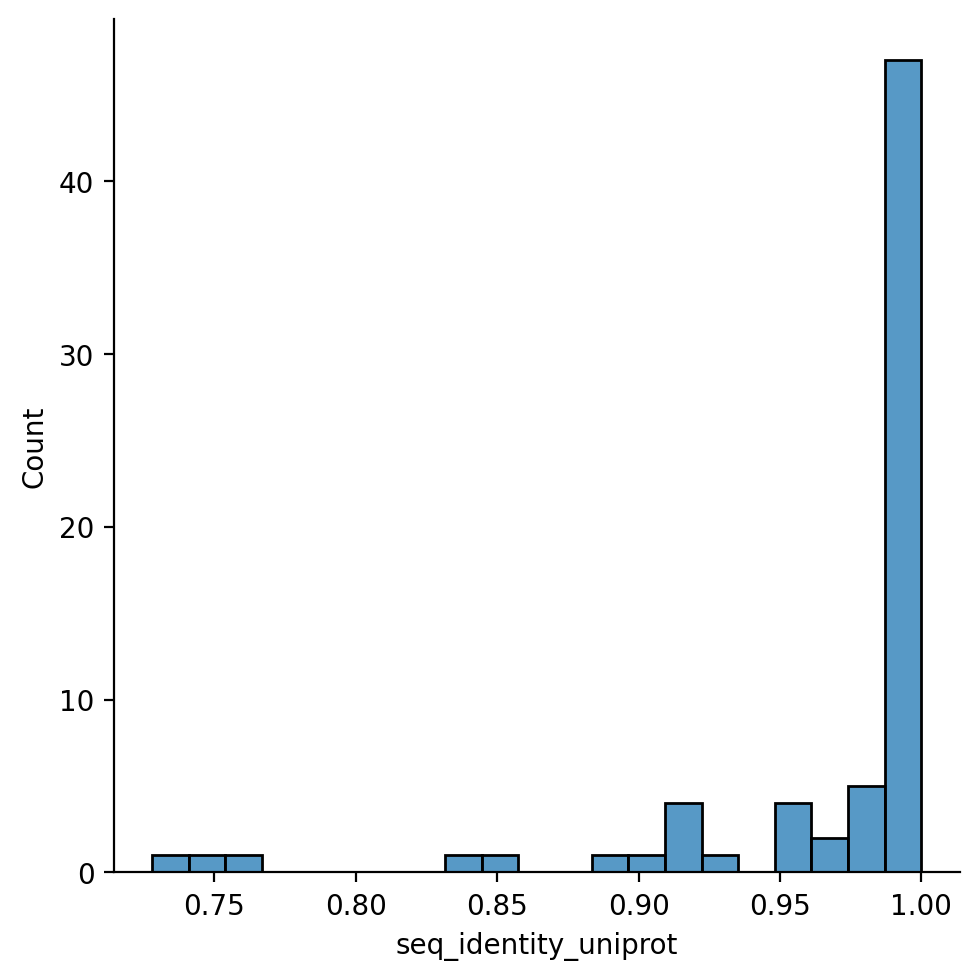

In [113]:
# OLD: Filter by sequence identity to UniProt ID
# Lood: I think this is old and could be deleted
# Arbitrary filtering choice: Drop UniProt mismatches (for now) and < 90% identity (many of these have 100% identity matches in trEMBL but we can do them later)
# df_wts_filtered_nonr_out = df_wts_filtered_nonr[(df_wts_filtered_nonr["seq_identity"] >= 0.9) & ~df_wts_filtered_nonr["seq_identity"].isna()].copy()
# print(f"WT filtered nonredundant file: {len(df_wts_filtered_nonr_out)} WTs")

# 90 unique sequences
print(df_wts_filtered_nonr["UniProt_ID"].value_counts(dropna=False))

# After dropping missed PDB SIFTS matches to UniProt: 95 remaining
# Debbie decision 14 Aug: Keep all of them even without seq_identity information
uniprot_blast_missing = (~df_wts_filtered_nonr["UniProt_ID"].isna() & df_wts_filtered_nonr["seq_identity_uniprot"].isna())
print(f"{uniprot_blast_missing.sum()} proteins with missed UniProt ID search (but SIFTS mapping)")
df_wts_filtered_nonr_out = df_wts_filtered_nonr[~df_wts_filtered_nonr["UniProt_ID"].isna()].copy()

# Note: This doesn't include the 25 missing seq_identities
sns.displot(x="seq_identity_uniprot", data=df_wts_filtered_nonr_out)
plt.show()

In [115]:
counts = df_wts_filtered_nonr_out["UniProt_ID"].value_counts(dropna=False)
print(f"UniProt counts != 1:\n{counts[counts != 1]}")

# Quickly check these are valid
display(df_wts_filtered_nonr_out[df_wts_filtered_nonr_out["UniProt_ID"].isin(counts[counts != 1].index)][["name", "UniProt_AC", "UniProt_ID", "seq_identity_pdb", "seq_identity_uniprot", "sifts_index_UniProt_start_list", "sifts_index_UniProt_stop_list", "query_coverage_uniprot"]].sort_values(by="UniProt_ID"))

# Also, perfect - most have unique UniProt IDs so the redundancy filter may be working properly
# Except for ["SPTN1_CHICK", "VILI_CHICK", "SPG2_STRSG", "PIN1_HUMAN"]:


# PIN1_HUMAN is also correct for both, 1I6C.pdb	is exact match (seq_identity and query_coverage == 1) and similar number of mutations/multiples/indels
# SPG2_STRSG: Correct for both, it seems, 5UBS.pdb says it's de novo; 1GJS.pdb says it's SPG but has less coverage. Should probably choose 1GJS.pdb if necessary
# - But 5UBS.pdb has multiples but 1GJS.pdb doesn't, let's choose 5UBS.pdb
# SPTN1_CHICK: 2KR3: Supposed to be SHA-D domain; 1TUD.pdb (cut at N47-D48) and 1TUC.pdb (cut at S19-P20) from same paper, SH3 domain. 
#  - Should probably choose 2KR3.pdb as it has the highest overlap with the SH3 domain annotation of UniProt (967-1026)
#  - BUT: 1TUD.pdb has way more multiples (2k vs 1k or 0)
# VILI_CHICK is correct for both, 1YU5.pdb is better match (seq_identity and query_coverage == 1), and has way more multiples


# Checking number of multiples/indels for each
dup_names = df_wts_filtered_nonr_out[df_wts_filtered_nonr_out["UniProt_ID"].isin(["SPTN1_CHICK", "VILI_CHICK", "SPG2_STRSG", "PIN1_HUMAN"])]["name"].unique()
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(df_natural[df_natural["WT_name"].isin(dup_names)].groupby("WT_name")["mut_class"].value_counts())


# Manually drop duplicates: (I have checked that both files have similar number of mutants etc.)
keep_list = ["1I6C.pdb", "5UBS.pdb", "1TUD.pdb", "1YU5.pdb"]
df_wts_filtered_nonr_out = df_wts_filtered_nonr_out[~df_wts_filtered_nonr_out["UniProt_ID"].isin(["SPTN1_CHICK", "VILI_CHICK", "SPG2_STRSG", "PIN1_HUMAN"]) | df_wts_filtered_nonr_out["name"].isin(keep_list)]

assert (df_wts_filtered_nonr_out["name"].isin(keep_list)).any()

assert (df_wts_filtered_nonr_out["UniProt_ID"].value_counts() == 1).all(), df_wts_filtered_nonr_out["UniProt_ID"].value_counts()


UniProt counts != 1:
Series([], Name: UniProt_ID, dtype: int64)


,name,UniProt_AC,UniProt_ID,seq_identity_pdb,seq_identity_uniprot,sifts_index_UniProt_start_list,sifts_index_UniProt_stop_list,query_coverage_uniprot


WT_name   mut_class
1I6C.pdb  single        686
          multiple      128
          insertion      76
          deletion       39
          wt              5
1TUD.pdb  multiple     2436
          single       1045
          insertion      97
          deletion       39
          wt              5
1YU5.pdb  multiple     1514
          single       1201
          insertion     113
          deletion       53
          wt              5
5UBS.pdb  single       1025
          multiple      484
          insertion     111
          deletion       51
          wt              5
Name: mut_class, dtype: int64


### Filter out indels

In [137]:
df_natural_subs_filtered[df_natural_subs_filtered["mut_class"].isin(["wt", "single"])].groupby("WT_name").get_group("1LP1.pdb")["mut_type"]

104393      wt
104394      wt
104395      wt
104396      wt
104397      wt
          ... 
105596    K55W
105597    K55Y
105598    K55F
105599    K55P
105600    K55C
Name: mut_type, Length: 1040, dtype: object

In [142]:
#tmp
tmp_group = df_natural_subs_filtered[df_natural_subs_filtered["mut_class"].isin(["wt", "single"])].groupby("WT_name").get_group("1LP1.pdb")
get_coverage(tmp_group)
# tmp_group.apply(get_coverage, axis=1)

1.0

single       264336
multiple     154131
insertion     26496
deletion      12680
wt             1288
Name: mut_class, dtype: int64


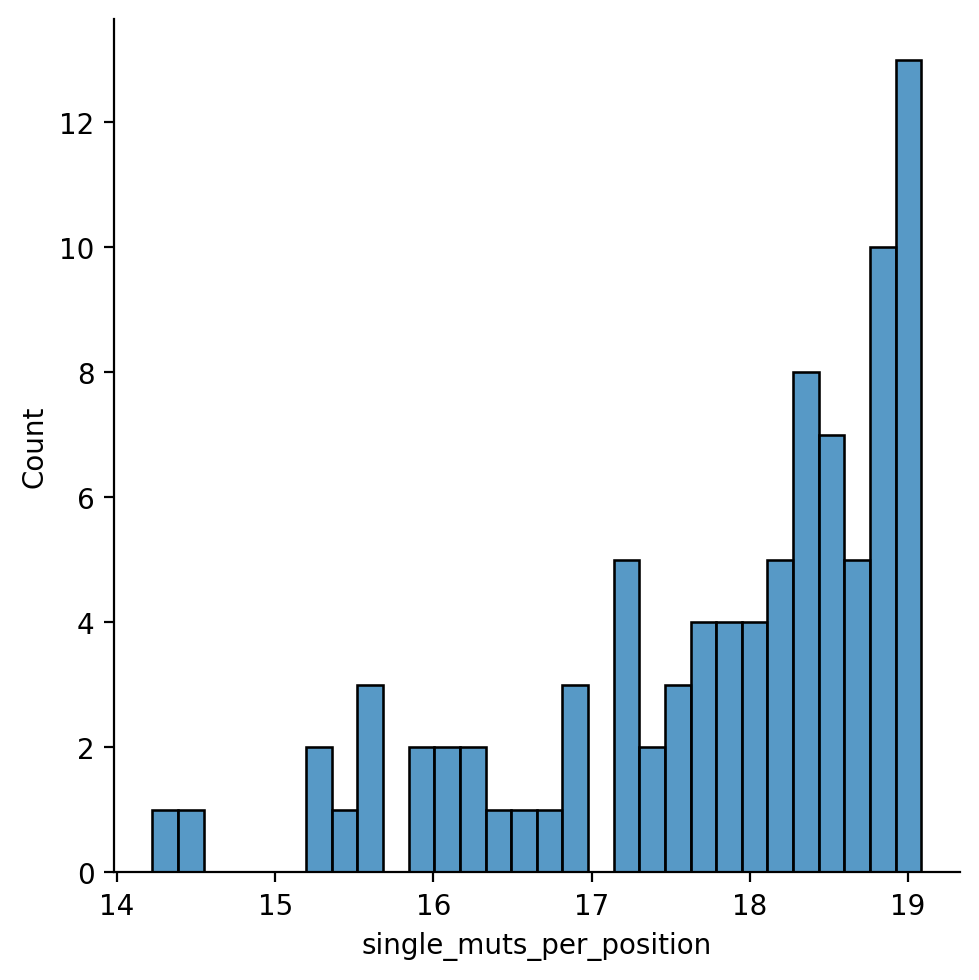

WT_name
1A32.pdb    1.000000
1AOY.pdb    1.000000
2MI6.pdb    1.000000
2MH8.pdb    1.000000
2MCK.pdb    1.000000
              ...   
2AMI.pdb    1.000000
1ZHC.pdb    1.000000
7JJK.pdb    1.000000
2YSB.pdb    0.976744
1E0L.pdb    0.945946
Name: position_muts_coverage, Length: 90, dtype: float64


WT_name
1GYZ.pdb    19.084746
1PV0.pdb    19.068182
1A32.pdb    19.047619
1ORC.pdb    19.047619
5JRT.pdb    19.033898
              ...    
6YSE.pdb    15.378378
1W4G.pdb    15.250000
2L2D.pdb    15.238095
2MH8.pdb    14.444444
2CJJ.pdb    14.222222
Name: single_muts_per_position, Length: 90, dtype: float64

In [145]:
# Check how many doubles/indels there are
print(df_natural["mut_class"].value_counts())
# print(f"Number of singles: {_wt.sum() + _single.sum():,}, number of multiples: {_mul.sum():,} out of total {len(df_natural):,}")

df_natural_subs_filtered = df_natural[df_natural["mut_class"].isin(["wt", "single", "multiple"])].copy()
df_natural_subs_filtered = df_natural_subs_filtered[df_natural_subs_filtered["WT_name"].isin(df_wts_filtered_nonr_out["name"])]

# Mutations per position: Can filter on this later if needed
muts_per_position = df_natural_subs_filtered[df_natural_subs_filtered["mut_class"].isin(["wt", "single"])].groupby("WT_name").apply(lambda group: len(group) / group["domain_length"].mean()).sort_values(ascending=False)

muts_per_position.name = "single_muts_per_position"
df_wts_filtered_nonr_subs_out = df_wts_filtered_nonr_out.merge(muts_per_position, left_on="name", right_on="WT_name", how='left').sort_values(by="WT_name")

# TODO choose only > 18 single mutations per position?
sns.displot(x="single_muts_per_position", data=df_wts_filtered_nonr_subs_out, bins=30)
plt.show()

# Get % of positions covered with at least 1 mutation
def get_coverage(group):
    assert "mut_type" in group
    pos = [int(m[1:-1]) for mult in group["mut_type"].values for m in mult.split(":") if m != "wt"]
    length = group["domain_length"].values[0]
    return len(set(pos)) / length

muts_coverage = df_natural_subs_filtered[df_natural_subs_filtered["mut_class"].isin(["wt", "single"])].groupby("WT_name").apply(get_coverage).sort_values(ascending=False)
muts_coverage.name = "position_muts_coverage"
print(muts_coverage)

muts_per_position

In [146]:
display(df_wts_filtered_nonr_out.head())
df_wts_filtered_nonr_out.to_csv(nonredundant_file_out, index=False)

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library,domain_length,PDB_sifts,CHAIN,WT_name,PDB_mmseqs,seq_identity_pdb,alnlen_pdb,mismatch_pdb,tstart_pdb,tend_pdb,evalue_pdb,query_coverage_pdb,bits_pdb,chain,UniProt_AC,sifts_index_RES_start_gapped,sifts_index_RES_stop_gapped,sifts_index_RES_start_list,sifts_index_RES_stop_list,sifts_index_PDB_start_gapped,sifts_index_PDB_stop_gapped,sifts_index_PDB_start_list,sifts_index_PDB_stop_list,sifts_index_UniProt_start_gapped,sifts_index_UniProt_stop_gapped,sifts_index_UniProt_start_list,sifts_index_UniProt_stop_list,seq_identity_uniprot,alnlen_uniprot,mismatch_uniprot,tstart_uniprot,tend_uniprot,evalue_uniprot,query_coverage_uniprot,bits_uniprot,From,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
0,1LP1.pdb,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,0.045267,0.920255,0.935076,0.898203,0.499400,1.526818,1.693994,0.059199,0.042527,1.814814,1.494028,1.814814,1.737462,0.013737,-0.778874,0.123080,0.057862,0.090909,0.000000,0.000000,71,0,G0,natural,55,1LP1,B,1LP1.pdb,1LP1,0.763,55.0,13.0,4.0,58.0,2.856000e-18,1.0,80.0,B,P38507,1.0,1.0,1.0,58.0,None,None,None,None,212.0,212.0,212.0,269.0,0.745,55.0,14.0,215.0,269.0,9.380000e-18,1.000,78.0,P38507,reviewed,SPA_STAAU,Immunoglobulin G-binding protein A (IgG-bindin...,spa,Staphylococcus aureus,508.0,NaN,"CONFLICT 273; /note=""K -> D (in Ref. 2; AA seq...",1.0,MKKKNIYSIRKLGVGIASVTLGTLLISGGVTPAANAAQHDEAQQNA...,NaN,BIOTECHNOLOGY (1); DOMAIN (1); FUNCTION (1); S...,3.0,1994-10-01,2023-05-03,1994-10-01,162.0,WP_047211818.1;,P38507;,1BDC;1BDD;1EDI;1EDJ;1EDK;1EDL;1FC2;1H0T;1LP1;1...,PF02216;PF00746;PF01476;PF03373;PF04650;
2,2HBB.pdb,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKALE,0.044298,0.949046,0.940357,0.996624,-0.099419,2.124396,2.051878,0.056337,0.041142,2.316026,2.315899,2.223875,2.316026,0.619980,-0.368166,0.116143,0.062527,0.083333,0.572085,0.337415,145,0,G0,natural,48,2HBB,A,2HBB.pdb,2HBB,1.000,48.0,0.0,1.0,48.0,1.231000e-24,1.0,98.0,A,P02417,1.0,1.0,"[1.0, 1.0]","[51.0, 51.0]",1,1,"[1, 1]","[51, 51]",1.0,1.0,"[1.0, 1.0]","[51.0, 51.0]",1.000,48.0,0.0,1.0,48.0,1.133000e-24,1.000,98.0,P02417,reviewed,RL9_GEOSE,Large ribosomal subunit protein bL9 (50S ribos...,rplI,Geobacillus stearothermophilus (Bacillus stear...,149.0,NaN,"CONFLICT 28; /note=""Missing (in Ref. 3; AA seq...",2.0,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKA...,NaN,FUNCTION (1); SIMILARITY (1),2.0,1986-07-21,2023-06-28,1991-05-01,126.0,WP_033008865.1;,P02417;,1CQU;1DIV;2HBA;2HBB;2HVF;4V4R;4V4S;4V4T;,PF03948;PF01281;
3,2D1U.pdb,QVNIAPGSLDKALNQYAAHSGFTLSVDASLTRGKQSNGLHGDYDVE...,0.043424,0.957190,0.950786,0.853303,0.439223,1.547207,1.643698,0.216043,0.145432,1.537620,1.107768,1.537620,1.385577,-0.133476,-1.307900,0.449150,0.096479,0.111111,0.015839,0.000000,102,0,G0,natural,72,2D1U,A,2D1U.pdb,2D1U,1.000,72.0,0.0,2.0,73.0,4.261000e-43,1.0,152.0,A,P13036,1.0,1.0,1.0,96.0,1,1,1,96,34.0,34.0,34.0,129.0,1.000,72.0,0.0,35.0,106.0,3.924000e-43,1.000,152.0,P13036,reviewed,FECA_ECOLI,Fe(3+) dicitrate transport protein FecA (Iron(...,fecA b4291 JW4251,Escherichia coli (strain K12),774.0,NaN,"CONFLICT 16; /note=""T -> A (in Ref. 1; AAA2376...",2.0,MTPLRVFRKTTPLVNTIRLSLLPLAGLSFSAFAAQVNIAPGSLDKA...,NaN,FUNCTION (1); INDUCTION (1); INTERACTION (1); ...,5.0,1990-01-01,2023-05-03,1995-02-01,183.0,NP_418711.1;WP_000188283.1;,P13036;,1KMO;1KMP;1PNZ;1PO0;1PO3;1ZZV;2D1U;,PF07715;PF07660;PF00593;
4,1UFM.pdb,SSGGSSILDRAVIEHNLLSASKLYNNITFEELGALLEIPAAKAEKI...,0.044053,0.947749,0.960725,1.065188

## Write out mutant score files

In [147]:
assert df_wts_filtered_nonr_out["WT_name"].str.contains(r"^[A-Z0-9]{4}.pdb$").all()  # All the PDB WT names at this point are 4-char codes
# (df_wts_filtered_nonr_out["name"] == df_wts_filtered_nonr_out["WT_name"]).all()

# Write out all the DMS ids: UniProt_ID + Rocklin_2023 + WT_name (without the .pdb extension)
df_wts_filtered_nonr_out["DMS_id"] = df_wts_filtered_nonr_out["UniProt_ID"] + "_Rocklin_2023_" + df_wts_filtered_nonr_out["WT_name"].str.replace(".pdb", "", regex=False)
df_wts_filtered_nonr_out["DMS_id"].head()

0      SPA_STAAU_Rocklin_2023_1LP1
2      RL9_GEOSE_Rocklin_2023_2HBB
3     FECA_ECOLI_Rocklin_2023_2D1U
4     CSN4_MOUSE_Rocklin_2023_1UFM
5    HECD1_HUMAN_Rocklin_2023_3DKM
Name: DMS_id, dtype: object

In [148]:
overwrite = False

if len(os.listdir(per_dms_output_folder)) != 0:
    answer = input("Mutant score files: Warning - this directory already has files - do you want to overwrite? If in doubt, make a new directory at the top of the notebook with the current date. y/n")
    overwrite = answer.upper() == "Y"

mapping_rows = []

if not overwrite:
    print("Skipping writing out...")
else:
    print("Writing out:")
    for i, row in tqdm(df_wts_filtered_nonr_out.sort_values("DMS_id").iterrows()):
        wt_name = row["WT_name"]
        dms_id = row["DMS_id"]

        subset = df_natural_subs_filtered[df_natural_subs_filtered["WT_name"] == wt_name]
        
        dms_filename = f"{dms_id}.csv"
        file_out = os.path.join(per_dms_output_folder, dms_filename)
        subset.to_csv(file_out, index=False)
        num_multiple = (subset["mut_class"] == "multiple").sum()

        mapping_rows.append({"DMS_id": dms_id, 
                             "DMS_filename": dms_filename, 
                             "UniProt_ID": row["UniProt_ID"],
                             "target_seq": row["aa_seq"], 
                             "seq_len": row["domain_length"], 
                             "region_mutated": f"1-{row['domain_length']}",
                             "includes_multiples": "TRUE" if num_multiple > 0 else "FALSE",
                             "DMS_total_number_mutants": len(subset),
                             "DMS_number_single_mutants": len(subset) - num_multiple,
                             "DMS_number_multiple_mutants": num_multiple,
                             }) # TODO any others?


Writing out:


0it [00:00, ?it/s]

In [149]:
# Write out subs mapping file
if overwrite:
    df_mapping_subs = pd.DataFrame(mapping_rows)
    df_mapping_subs["raw_DMS_phenotype_name"] = "ddG_ML_float"
    df_mapping_subs["raw_DMS_directionality"] = 1
    df_mapping_subs["raw_DMS_mutant_column"] = "mut_type"

    df_mapping_subs.sort_values("DMS_id").to_csv(subs_mapping_file, index=False)
    print("Wrote out file")
else:
    print("Skipping writing out")
    df_mapping_subs = pd.read_csv(subs_mapping_file)

Wrote out file


## Plot each DMS

In [151]:
def plot_dms(df_dms, dms_id, show=False):
    ax = sns.displot(x="ddG_ML_float", data=df_dms, hue='mut_class')
    _wt_value = df_dms[df_dms["mut_type"] == "wt"]["ddG_ML_float"]
    
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    # TODO add legend to this
    for val in _wt_value:
        plt.axvline(val, c="b", ls=':')
    plt.title(dms_id)
    plt.xlabel("ddG unfolding (higher is better)")
    # plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/{dms_id}_histogram.png", dpi=300, bbox_inches='tight')
    
    if show:
        plt.show()
    plt.close()

# Check if directory is already full
overwrite = False
if len(os.listdir(PLOT_DIR)) != 0:
    answer = input("DMS Plotting: Warning - this directory is already full - do you want to overwrite? If in doubt, make a new directory at the top of the notebook with the current date. Y/N")
    overwrite = answer.upper() == "Y"

if not overwrite:
    print("Skipping writing out...")
else:
    print("Writing out:")    
    for i, filename in enumerate(tqdm(sorted(os.listdir(per_dms_output_folder)))):
        dms_id = filename.split(".csv")[0]
        df_dms = pd.read_csv(f"{per_dms_output_folder}/{filename}", index_col=False)
        if i == 0:
            print("Showing first plot:")
            plot_dms(df_dms=df_dms, dms_id=dms_id, show=True)
        else:
            plot_dms(df_dms=df_dms, dms_id=dms_id)


Skipping writing out...


# Extra: Writing out indel files

In [154]:
df_natural_indels_filtered = df_natural[df_natural["mut_class"].isin(["wt", "insertion", "deletion"])].copy()

print(f"Number of insertions/deletions: \n{df_natural_indels_filtered['mut_class'].value_counts()}")
df_natural_indels_filtered = df_natural_indels_filtered[df_natural_indels_filtered["WT_name"].isin(df_wts_filtered_nonr_out["name"])]

# Mutations per position: Can filter on this later if needed
indel_muts_per_position = df_natural_indels_filtered.groupby("WT_name").apply(lambda group: len(group) / group["domain_length"].mean()).sort_values(ascending=False)

indel_muts_per_position.name = "indel_muts_per_position"
df_wts_filtered_nonr_indels_out = df_wts_filtered_nonr_out.merge(indel_muts_per_position, left_on="name", right_on="WT_name")

print("Number of indels per position")
indel_muts_per_position

Number of insertions/deletions: 
insertion    26496
deletion     12680
wt            1288
Name: mut_class, dtype: int64
Number of indels per position


WT_name
2RRU.pdb    3.100198
1PV0.pdb    3.091074
2N88.pdb    3.083472
1UFM.pdb    3.083396
2JVD.pdb    3.077780
              ...   
2KRU.pdb    1.810068
1ZHC.pdb    1.637812
2BTT.pdb    1.465533
1W4G.pdb    1.286223
2MH8.pdb    1.007662
Name: indel_muts_per_position, Length: 90, dtype: float64

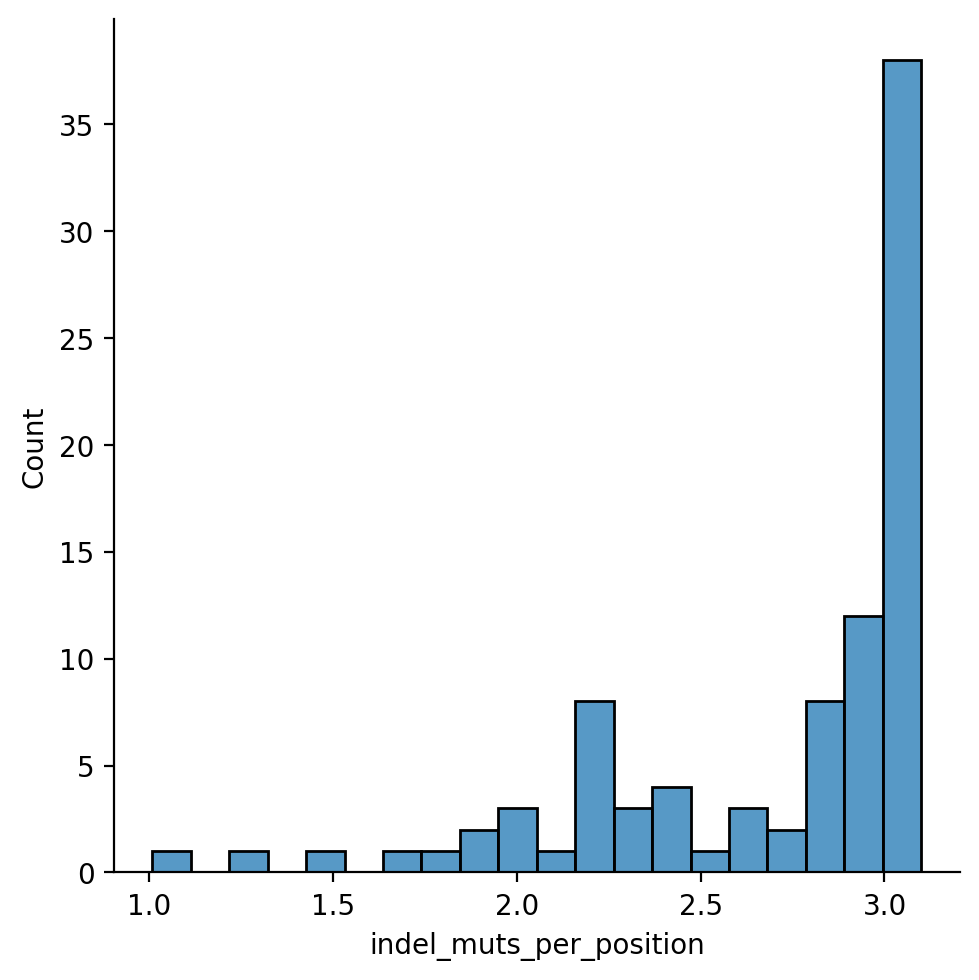

In [155]:
sns.displot(indel_muts_per_position, bins=20)

In [156]:
# Writing out indel files
# Just copied from above
overwrite = False
if len(os.listdir(per_dms_output_folder_indels)) != 0:
    answer = input("Mutant score files: Warning - this directory is already full - do you want to overwrite? If in doubt, make a new directory at the top of the notebook with the current date. Y/N").upper()
    overwrite = answer == "Y"

mapping_rows = []

if not overwrite:
    print("Skipping writing out...")
else:
    print("Writing out:")
    for i, row in tqdm(df_wts_filtered_nonr_out.sort_values("DMS_id").iterrows()):
        wt_name = row["WT_name"]
        dms_id = row["DMS_id"]

        subset = df_natural_indels_filtered[df_natural_indels_filtered["WT_name"] == wt_name]
        if len(subset) == 0:
            print(f"Skipping {dms_id} since there are no indels")
            continue
        
        dms_filename = f"{dms_id}_indels.csv"
        file_out = os.path.join(per_dms_output_folder_indels, dms_filename)
        subset.to_csv(file_out, index=False)
        # num_multiple = (subset["mut_class"] == "multiple").sum()

        mapping_rows.append({"DMS_id": dms_id, 
                             "DMS_filename": dms_filename, 
                             "UniProt_ID": row["UniProt_ID"],
                             "target_seq": row["aa_seq"], 
                             "seq_len": row["domain_length"], 
                             "region_mutated": f"1-{row['domain_length']}",
                            #  "includes_multiples": "TRUE" if num_multiple > 0 else "FALSE",
                             "DMS_total_number_mutants": len(subset),
                            #  "DMS_number_single_mutants": len(subset) - num_multiple,
                            #  "DMS_number_multiple_mutants": num_multiple,
                             }) # TODO any others?

Writing out:


0it [00:00, ?it/s]

In [157]:
# Write out indel mapping file
if overwrite:
    print("Writing out indels mapping file to ", indels_mapping_file)
    df_mapping_indels = pd.DataFrame(mapping_rows)
    df_mapping_indels["raw_DMS_phenotype_name"] = "ddG_ML_float"
    df_mapping_indels["raw_DMS_directionality"] = 1
    df_mapping_indels["raw_DMS_mutant_column"] = "aa_seq"

    df_mapping_indels.sort_values("DMS_id").to_csv(indels_mapping_file, index=False)

Writing out indels mapping file to  ../raw_data/Rocklin_2023//DMS_mapping_Rocklin_2023_indels.csv


## Per-dms indels plots

Writing out:


  0%|          | 0/90 [00:00<?, ?it/s]

Showing first plot:


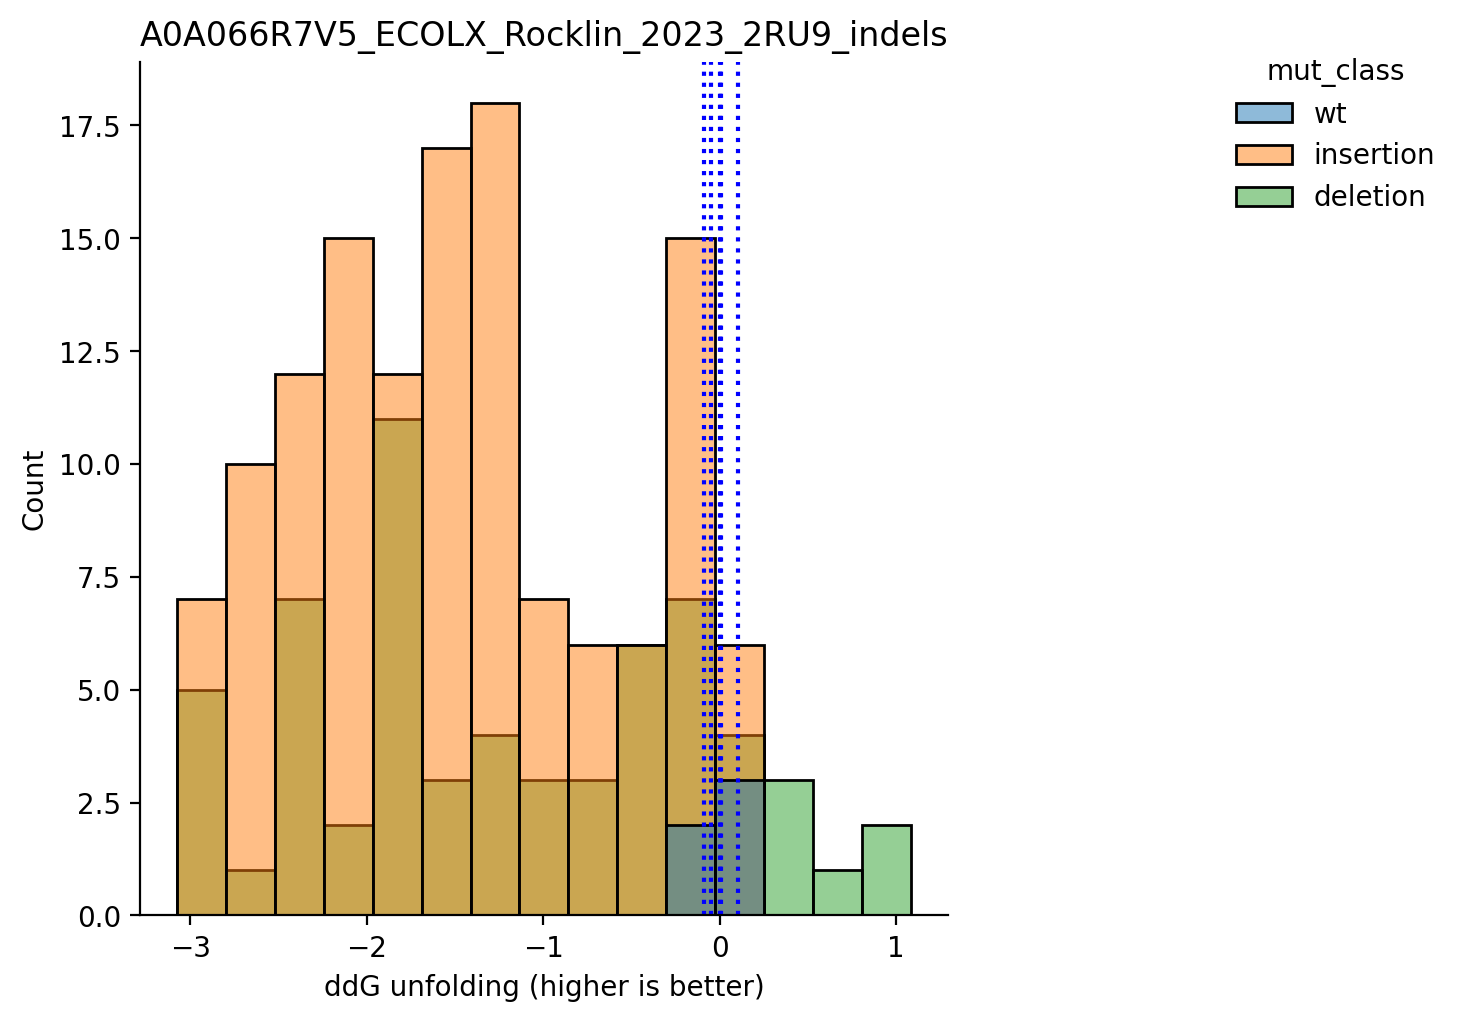

In [158]:
# Also copied from above

def plot_dms(df_dms, dms_id, show=False):
    ax = sns.displot(x="ddG_ML_float", data=df_dms, hue='mut_class', bins=15)
    _wt_value = df_dms[df_dms["mut_type"] == "wt"]["ddG_ML_float"]
    # TODO add legend to the wt values
    for val in _wt_value:
        plt.axvline(val, c="b", ls=':')
    
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.title(dms_id)
    plt.xlabel("ddG unfolding (higher is better)")
    # plt.tight_layout()
    plt.savefig(f"{PLOT_DIR_INDELS}/{dms_id}_histogram.png", dpi=300, bbox_inches='tight')
    
    if show:
        plt.show()
    plt.close()

# Check if directory is already full
overwrite = False
if len(os.listdir(PLOT_DIR_INDELS)) != 0:
    answer = input("DMS Plotting: Warning - this directory is already full - do you want to overwrite? If in doubt, make a new directory at the top of the notebook with the current date. Y/N")
    overwrite = answer.upper() == "Y"

if not overwrite:
    print("Skipping writing out...")
else:
    print("Writing out:")    
    for i, filename in enumerate(tqdm(sorted(os.listdir(per_dms_output_folder_indels)))):
        dms_id = filename.split(".csv")[0]
        df_dms = pd.read_csv(f"{per_dms_output_folder_indels}/{filename}", index_col=False)
        if i == 0:
            print("Showing first plot:")
            plot_dms(df_dms=df_dms, dms_id=dms_id, show=True)
        else:
            plot_dms(df_dms=df_dms, dms_id=dms_id)


### Compare new and old mapping files, keep track of DMS_id renaming
Important lesson for ProteinGym: Everytime you rename something stuff explodes. So keep track of renames in e.g. "DMS_id_old" dedicated column.

In [ ]:
df_new = pd.read_csv(subs_mapping_file)
df_old = pd.read_csv(RAW_DATA_ROOT+"/old_DMS_mapping_Rocklin_2023_substitutions.csv")
df_mapping_merged = df_mapping_subs[["DMS_id", "UniProt_ID", "target_seq"]].merge(df_old[["DMS_id", "UniProt_ID", "target_seq"]], on="target_seq", how="outer", suffixes=['_new', "_old"])
display(df_mapping_merged)

print(f"# Old sequences: {len(df_old)}")
print(f"# New sequences: {len(df_mapping_subs)}")
print(f"Number of exact DMS_id matches: {(df_mapping_merged['DMS_id_new'] == df_mapping_merged['DMS_id_old']).sum()}")
print(f"Number of exact UniProt_ID matches: {(df_mapping_merged['UniProt_ID_new'] == df_mapping_merged['UniProt_ID_old']).sum()}")
print(f"Number of sequences in both sets: {len(df_mapping_merged.dropna(subset=['DMS_id_new', 'DMS_id_old'], how='any'))}")
print(f"Number of sequences in new but not old: {df_mapping_merged['DMS_id_old'].isna().sum()}")
print(f"Number of sequences in old but not new: {df_mapping_merged['DMS_id_new'].isna().sum()}")
print(f"UniProt IDs in old but not new: {df_mapping_merged[df_mapping_merged['DMS_id_new'].isna()]['DMS_id_old'].values}")

# tmp check these mutation depths
print(f"New PDBs: {df_mapping_merged[df_mapping_merged['DMS_id_old'].isna()]['DMS_id_new']}")
list_new_pdbs = df_mapping_merged[df_mapping_merged['DMS_id_old'].isna()]['DMS_id_new'].str.split("_").str[-1] + ".pdb"

list_old_pdbs = df_mapping_merged[df_mapping_merged['DMS_id_new'].isna()]['DMS_id_old'].str.split("_").str[-1] + ".pdb"

# Write out this mapping file:
df_mapping_merged.to_csv(RAW_DATA_ROOT+"/2023_08_14_RENAMING_DMS_mapping_Rocklin_2023_substitutions.csv", index=False)

,DMS_id_new,UniProt_ID_new,target_seq,DMS_id_old,UniProt_ID_old
0,AMFR_HUMAN_Rocklin_2023_4G3O,AMFR_HUMAN,YFQGQLNAMAHQIQEMFPQVPYHLVLQDLQLTRSVEITTDNILEGRI,NaN,NaN
1,ARGR_ECOLI_Rocklin_2023_1AOY,ARGR_ECOLI,QEELVKAFKALLKEEKFSSQGEIVAALQEQGFDNINQSKVSRMLTK...,ARGR_ECO55_Rocklin_2023_1AOY,ARGR_ECO55
2,BBC1_YEAST_Rocklin_2023_1TG0,BBC1_YEAST,EVPFKVVAQFPYKSDYEDDLNFEKDQEIIVTSVEDAEWYFGEYQDS...,BBC1_YEAST_Rocklin_2023_1TG0,BBC1_YEAST
3,BCHB_CHLTE_Rocklin_2023_2KRU,BCHB_CHLTE,ELSWTAEAEKMLGKVPFFVRKKVRKNTDNYAREIGEPVVTADVFRK...,NaN,NaN
4,CATR_CHLRE_Rocklin_2023_2AMI,CATR_CHLRE,GLTEEQKQEIREAFDLFDTDGSGTIDAKELKVAMRALGFEPKKEEI...,CATR_SCHDU_Rocklin_2023_2AMI,CATR_SCHDU
...,...,...,...,...,...
62,YAIA_ECOLI_Rocklin_2023_2KVT,YAIA_ECOLI,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,YAIA_ECO57_Rocklin_2023_2KVT,YAIA_ECO57
63,YNZC_BACSU_Rocklin_2023_2JVD,YNZC_BACSU,MISNAKIARINELAAKAKAGVITEEEKAEQQKLRQEYLK,YNZC_BACSU_Rocklin_2023_2JVD,YNZC_BACSU
64,NaN,NaN,KDKDLLKGLDQEQANEVIAVLQMHNIEANKIDSGKLGYSITVAEPD...,PRGK_SALTY_Rocklin_2023_2MKY,PRGK_SALTY
65,NaN,NaN,NSLAEAKVLANRELDKYGVSDYYKNLINNAKTVEGVKALIDEILA,SPG2_STRSG_Rocklin_2023_1GJS,SPG2_STRSG


# Old sequences: 49
# New sequences: 64
Number of exact DMS_id matches: 23
Number of exact UniProt_ID matches: 23
Number of sequences in both sets: 46
Number of sequences in new but not old: 18
Number of sequences in old but not new: 3
UniProt IDs in old but not new: ['PRGK_SALTY_Rocklin_2023_2MKY' 'SPG2_STRSG_Rocklin_2023_1GJS'
 'YAJR_ECOLI_Rocklin_2023_2RU9']
New PDBs: 0      AMFR_HUMAN_Rocklin_2023_4G3O
3      BCHB_CHLTE_Rocklin_2023_2KRU
5     CBPA2_HUMAN_Rocklin_2023_1O6X
6      CBX4_HUMAN_Rocklin_2023_2K28
7      CSN4_MOUSE_Rocklin_2023_1UFM
                  ...              
43     SAV1_MOUSE_Rocklin_2023_2YSB
48      SPA_STAAU_Rocklin_2023_1LP1
49     SPG2_STRSG_Rocklin_2023_5UBS
50    SPTN1_CHICK_Rocklin_2023_1TUD
53    SRBS1_HUMAN_Rocklin_2023_2O2W
Name: DMS_id_new, Length: 18, dtype: object


In [ ]:
# 2MKY.pdb: This was the correct UniProt ID, prgK, not sure why PDB/SIFTS doesn't have it
# 1GJS.pdb: This was removed in favour of 5UBS only because it has multiples
# 2RU9: PDB mapped this to A0A066R7V5_ECOLX instead of YAJR_ECOLI (95% similarity)
list_old_pdbs

64    2MKY.pdb
65    1GJS.pdb
66    2RU9.pdb
Name: DMS_id_old, dtype: object

In [ ]:
# tmp:
display(muts_per_position[muts_per_position.index.isin(list_new_pdbs)])
# display(muts_per_position[muts_per_position.index.isin(list_old_pdbs)])  # We don't have these anyway

WT_name
1A32.pdb    19.047619
1LP1.pdb    18.909091
1O6X.pdb    18.902778
1UFM.pdb    18.861111
1F0M.pdb    18.833333
              ...    
2KRU.pdb    17.211538
4G3O.pdb    17.191489
2LHR.pdb    17.145455
2YSB.pdb    15.860465
1W4G.pdb    15.250000
Name: single_muts_per_position, Length: 18, dtype: float64

In [ ]:
# TODO remap DMS_ids for indels too, but should be the same files anyway

# Old ---------------------------------------------------

## Check sequence identities for BLAST matches

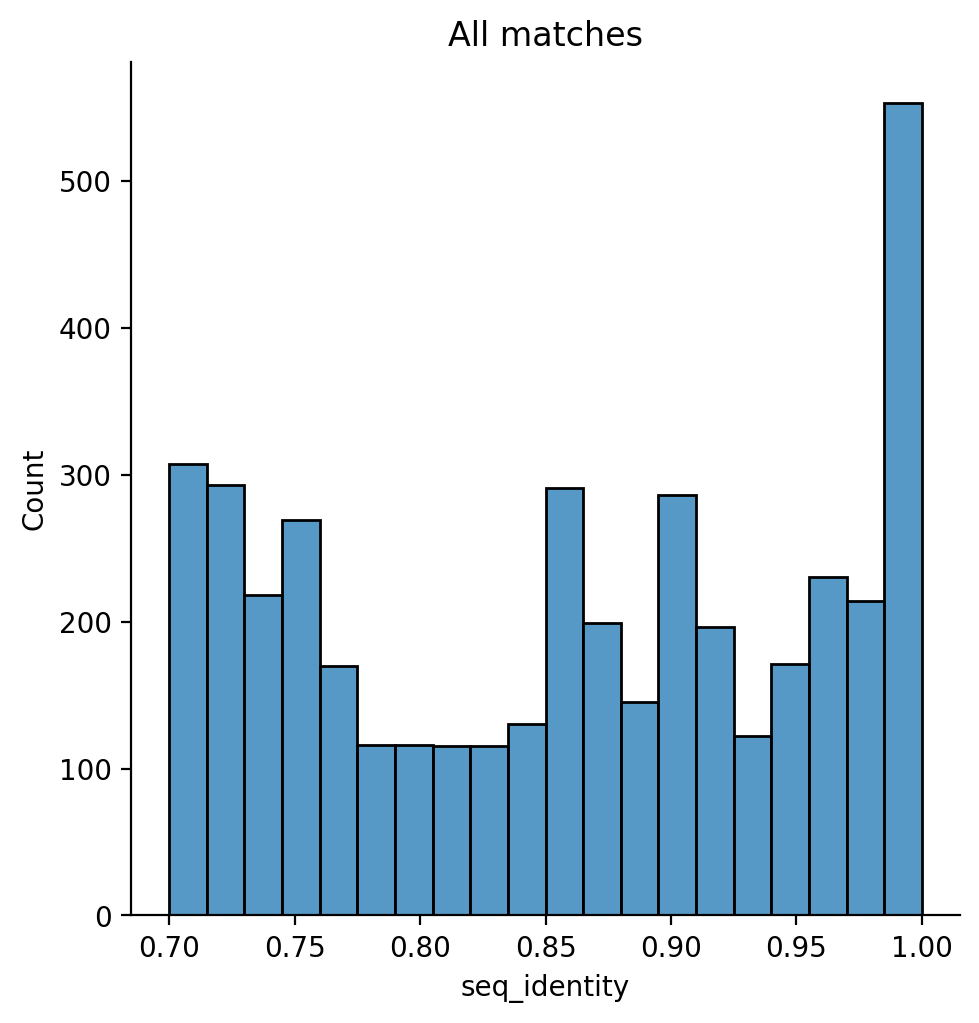

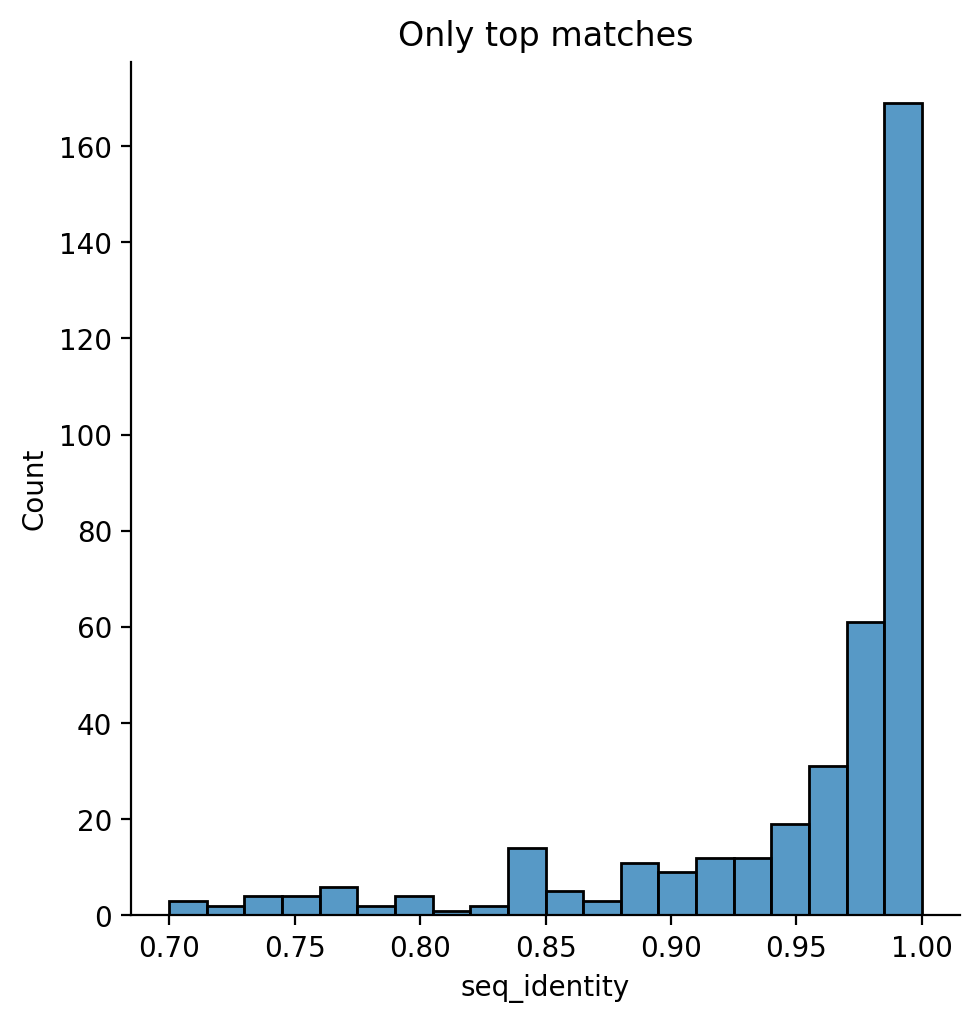

In [ ]:
# Old: All PDB matches are now exact. We can match the blast results later though to see how similar they are?
# Check the sequence similarities
sns.displot(x='seq_identity', data=df_blast_clean, bins=20)
plt.title("All matches")
plt.show()

# Filter and choose only the top sequence identity hits
# Lower evalue is better, so flip the ascending order for it
# Both seq_identity -> evalue -> query_coverage and seq_identity -> query_coverage -> evalue (swapping evalue and query_coverage) result in the same mappings
df_blast_top = df_blast_clean.sort_values(by=['seq_identity', 'evalue', 'query_coverage'], ascending=[False, True, False]).groupby("WT_name").head(1)

sns.displot(x='seq_identity', data=df_blast_top, bins=20)
plt.title("Only top matches")
plt.show()

In [ ]:
# Check number of unique uniprot IDs
# display(df_blast_top["UniProt_AC"].value_counts())
display(df_blast_top["UniProt_ID"].value_counts())

SPG2_STRSG     26
SPTN1_MOUSE    24
ANP12_ZOAAM    16
TCRG1_HUMAN    12
PIN1_HUMAN      9
               ..
RPC1_BP434      1
ZHX1_GORGO      1
RAD_ANTMA       1
Z2753_HALVD     1
PHOSP_RINDK     1
Name: UniProt_ID, Length: 200, dtype: int64

## BLAST to get UniProt IDs

In [ ]:
# Submit all blast jobs
job_ids = []

#curl --form 'email=<enter_your_email_here>' \
#      --form 'program=blastp' \
#      --form 'matrix=BLOSUM80' \
#      --form 'alignments=50' \
#      --form 'scores=50' \
#      --form 'exp=1.0' \
#      --form 'hsps=2' \
#      --form 'filter=F' \
#      --form 'gapalign=true' \
#      --form 'compstats=F' \
#      --form 'align=0' \
#      --form 'stype=protein' \
#      --form 'sequence=>seq3
# MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKALE
# ' \
#      --form 'database=uniprotkb_refprotswissprot' \
#      https://www.ebi.ac.uk/Tools/services/rest/ncbiblast/run

# Either use requests or biopython
# from Bio.Blast import NCBIWWW
# for seq in wt_seqs[:1]:
#     print(seq)
#     # Using BioPython: This blocks which isn't ideal
#     ret = NCBIWWW.qblast(program='blastp', database='uniprotkb_refprotswissprot', sequence=seq)
#     print(ret)


In [ ]:
# !source /programs/biogrids.shrc && which blastn
# Just use hhsuite or jackhmmer
# tmp = "KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAKKLNDAQAPK"
# tmp_fasta = RAW_DATA_ROOT + "/uniprot_mapping/tmp.fasta"
# with open(tmp_fasta, 'w') as fp:
#     fp.write(">1LP1.pdb\n")
#     fp.write(tmp)

# # BLAST seems tough to setup # /n/groups/marks/software/blast/ncbi-blast-2.9.0+-src/
# # phmmer:
# # Databases:  /n/groups/marks/databases/jackhmmer/uniprot/uniprot_current.fasta
# bin_file = "/n/groups/marks/software/hhsuite/hhsuite-3.3.0/bin/hhsearch"
# ! {bin_file} -v -i {tmp_fasta} -d  /n/groups/marks/databases/hhsuite/uniref90_2021_11 -o RAW_DATA_ROOT + "/tmp_matches.hhr"  


### PDB vs UniProt matches:

In [ ]:
# Diving into PDB matches but no UniProt-Swissprot matches:
display(df_fig_5[~df_fig_5["pdb_name"].isin(df_blast["WT_name"])].drop_duplicates(subset='pdb_name', keep='first'))
# Note: Can usually find out if these are synthetic from a) PDB or b) UniProt trEMBL
# 5KPH: De novo synthetic PDB
# 2MC5.pdb: Q8LTJ5 (trEMBL)
# 3ZGK: G1K3S4 (trEMBL)
# 7BPM.pdb: Synthetic
# 1ZHC: O25839 (trEMBL)
# 2KCM.pdb: Q8EG75 (trEMBL)
# 2JT1.pdb: Q04822 (trEMBL)
# 2K5N.pdb: Q6D6V0 (trEMBL)
# 2JN4.pdb: Q6N0Y6
# 2K5P.pdb: 

,pdb_name,pos,wt_aa,Q,E,N,H,D,R,K,T,S,A,G,M,L,V,I,W,Y,F,P
604,5KPH.pdb,1,E,3.636381,3.865952,3.370865,3.614193,3.515871,3.252738,3.847749,3.460648,3.558563,3.754782,3.488014,3.328253,3.058828,3.378407,2.884316,2.906326,2.922450,2.995913,3.188145
742,2MC5.pdb,1,E,1.405954,1.379854,1.354203,1.445411,1.307071,1.477620,1.525481,1.484588,1.505495,1.377985,1.536098,1.419377,1.341062,1.384108,1.690603,1.328266,1.403928,1.455745,1.304619
880,3ZGK.pdb,1,G,3.474950,3.348724,3.541119,3.454532,3.376566,3.134203,3.308954,3.653528,3.398775,3.446616,3.555487,3.225446,3.313076,3.519008,3.279970,3.188563,3.332826,3.280547,3.483268
1018,7BPM.pdb,1,G,2.357933,2.357829,2.497991,2.461552,2.234235,2.456328,2.502975,2.489125,2.373179,2.558276,2.335711,2.483386,2.626459,2.561038,2.614896,2.598928,2.415875,2.518558,2.424751
1087,1ZHC.pdb,1,H,0.786853,1.233074,0.834975,1.041635,1.276244,0.829320,0.854594,0.856115,1.035238,0.874176,0.836426,1.107819,1.120690,0.767586,0.938933,1.340237,0.729710,1.055408,0.497247
1359,2KCM.pdb,1,M,2.711026,1.572186,2.267023,2.664877,0.895586,2.850668,2.833864,2.761635,2.773735,3.086349,2.957085,4.239727,3.432671,2.851952,3.716401,1.727332,2.347312,2.836399,1.072408
1494,2JT1.pdb,1,S,3.238132,3.361654,3.200096,3.303809,3.372444,3.308453,3.162358,3.116175,3.259122,3.390489,3.255323,3.182714,3.220001,3.088256,3.141837,3.436153,3.175845,3.197204,2.733401
1561,2K5N.pdb,1,M,3.918012,3.558733,4.116215,4.191748,3.492752,4.259546,4.405076,5.000000,4.711700,4.042281,4.312124,4.021465,4.072420,4.100556,4.112530,3.608522,3.931826,3.762662,3.977371
1628,2JN4.pdb,1,M,0.456525,0.977693,0.210313,0.599863,-0.041681,-0.920167,-1.000000,1.440540,0.148549,0.304138,-0.496403,2.647551,2.790682,2.653871,3.090602,2.927820,2.405485,2.936253,-0.549836
2152,2K5P.pdb,1,M,0.387307,0.064799,0.257966,0.820455,0.289502,0.553797,0.659943,1.008293,0.303949,0.555216,0.505477,2.524322,2.441729,1.790541,2.499150,1.130759,1.225643,2.725831,0.378278


In [ ]:
# Sanity check: See how many PDB IDs do match
def check_pdb_id_match(row):
    if any(row[["PDB_other_ids"]].isna()):
        return False
    else:
        return row["name"].split(".pdb")[0] in row["PDB_other_ids"]

tmp = df_wts_filtered_nonr.apply(check_pdb_id_match, axis=1)
tmp.value_counts()
df_wts_filtered_nonr["PDB_other_ids"].isna().sum()  # Very few mappings have corresponding UniProt -> PDB ids actually.. weird

66

## PDB -> UniProt (old)
Decided not to use the PDB ids as the WT_names aren't guaranteed to correspond to real PDB ids..

Update: 90% of them do correspond correctly to PDB ids :)

In [ ]:
# Note: The PDB - aa_seq is not 1-to-1. And only works for natural sequences
df_natural["PDB"] = df_natural["WT_name"].str.split(".pdb").str[0] # e.g. get rid of the suffix like 1YEZ.pdb_V46S
# Remove the v2s too maybe?

pdb_ids = df_natural["PDB"].drop_duplicates()
display(pdb_ids.tail())

display(pdb_ids)
# Write out PDB ids
with open(RAW_DATA_ROOT + "/PDB_ids.txt", mode='w') as fp:
    fp.writelines("\n".join(pdb_ids.values.tolist()))
# Some of them start with v2, just manually check these first
pdb_ids[pdb_ids.str.len() != 4]

459363    2MH8
460554    2LHC
461571    1YEZ
463910    6OBK
473781    2M9E
Name: PDB, dtype: object

104393    1LP1
105608    2B88
106800    2HBB
107856    2D1U
109444    1UFM
          ... 
459363    2MH8
460554    2LHC
461571    1YEZ
463910    6OBK
473781    2M9E
Name: PDB, Length: 224, dtype: object

367767             v2_2HDZ
368849         v2K43S_2KVV
370196    v2R14S|R16S_2L3X
371653             v2_2LC2
372889             v2_2LXE
374058             v2_2M5A
375290    v2R31S|R32S_2N5D
376825             v2_4UZX
378106             v2_2LDM
379233             v2_6IVS
Name: PDB, dtype: object

In [ ]:
# Let's rather merge these PDBs with df_wts
df_wts["PDB"] = df_wts["name"].str.split(".pdb").str[0] # e.g. get rid of the suffix like 1YEZ.pdb_V46S
df_wts["PDB"].value_counts()  # Some duplicates

1UBQ              9
1LP1              8
2KZI              6
2B88              6
2HBB              6
                 ..
EEHEE_rd3_0809    1
EEHEE_rd3_1615    1
EEHEE_rd3_1702    1
EEHEE_rd3_1818    1
2MFI              1
Name: PDB, Length: 864, dtype: int64

In [ ]:
# From the UniProt ID mapping tool, manually
# unmapped_ids: 
# 2KZI
# 2MKY
# v2_2LDM
# 2M8E
# v2_4UZX
# 2LCL
# 6M3N
# v2R31S
# 5UP5
# 2MLB
# v2_2LC2
# v2_2LXE
# v2_2M5A
# 7BPM
# v2K43S_2KVV
# v2_6IVS
# 2KZJ
# R16S_2L3X
# 2LHC
# 3V1A
# 2JWS
# R32S_2N5D
# 5KPH
# v2R14S
# 5UYO
# v2_2HDZ

uniprot_natural_match_file = RAW_DATA_ROOT + "/uniprot_mapping/2023_07_20_uniprot_pdb_search.txt"
uniprot_matches = pd.read_csv(uniprot_natural_match_file, sep="\t")
uniprot_matches_clean = uniprot_matches.copy()
uniprot_matches_clean = uniprot_matches_clean.rename(columns={"From": "PDB", "Sequence": "UniProt_sequence", "Entry Name": "UniProt_ID", "Entry": "UniProt_AC", "PDB": "PDB_other_ids"})

uniprot_matches_clean.head()

,PDB,UniProt_AC,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
0,1LP1,P38507,reviewed,SPA_STAAU,Immunoglobulin G-binding protein A (IgG-bindin...,spa,Staphylococcus aureus,508,NaN,"CONFLICT 273; /note=""K -> D (in Ref. 2; AA seq...",1,MKKKNIYSIRKLGVGIASVTLGTLLISGGVTPAANAAQHDEAQQNA...,NaN,BIOTECHNOLOGY (1); DOMAIN (1); FUNCTION (1); S...,3.0,1994-10-01,2023-05-03,1994-10-01,162,WP_047211818.1;,P38507;,1BDC;1BDD;1EDI;1EDJ;1EDK;1EDL;1FC2;1H0T;1LP1;1...,PF02216;PF00746;PF01476;PF03373;PF04650;
1,2B88,Q70AB8,unreviewed,Q70AB8_STAAU,Protein A,spa,Staphylococcus aureus,252,NaN,NaN,1,AAQHDEAQQNAFYQVLNMPNLNADQRNGFIQSLKDDPSQSANVLGE...,NaN,NaN,1.0,2004-07-05,2023-05-03,2004-07-05,67,NaN,Q70AB8;,2B87;2B88;2B89;,PF02216;
2,2HBB,P02417,reviewed,RL9_GEOSE,Large ribosomal subunit protein bL9 (50S ribos...,rplI,Geobacillus stearothermophilus (Bacillus stear...,149,NaN,"CONFLICT 28; /note=""Missing (in Ref. 3; AA seq...",2,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKA...,NaN,FUNCTION (1); SIMILARITY (1),2.0,1986-07-21,2023-06-28,1991-05-01,126,WP_033008865.1;,P02417;,1CQU;1DIV;2HBA;2HBB;2HVF;4V4R;4V4S;4V4T;,PF03948;PF01281;
3,2D1U,P13036,reviewed,FECA_ECOLI,Fe(3+) dicitrate transport protein FecA (Iron(...,fecA b4291 JW4251,Escherichia coli (strain K12),774,NaN,"CONFLICT 16; /note=""T -> A (in Ref. 1; AAA2376...",2,MTPLRVFRKTTPLVNTIRLSLLPLAGLSFSAFAAQVNIAPGSLDKA...,NaN,FUNCTION (1); INDUCTION (1); INTERACTION (1); ...,5.0,1990-01-01,2023-05-03,1995-02-01,183,NP_418711.1;WP_000188283.1;,P13036;,1KMO;1KMP;1PNZ;1PO0;1PO3;1ZZV;2D1U;,PF07715;PF07660;PF00593;
4,1UFM,O88544,reviewed,CSN4_MOUSE,COP9 signalosome complex subunit 4 (SGN4) (Sig...,Cops4 Csn4,Mus musculus (Mouse),406,NaN,NaN,1,MAAAVRQDLAQLMNSSGSHKDLAGKYRQILEKAIQLSGTEQLEALK...,NaN,FUNCTION (1); INTERACTION (1); SIMILARITY (1);...,4.0,2004-11-23,2023-06-28,1998-11-01,160,NP_036131.1;,O88544;,1UFM;,PF18420;PF01399;


### Resolve duplicate mappings

In [ ]:
display(uniprot_matches_clean[uniprot_matches_clean["PDB"].duplicated(keep=False)])
# 2 duplicates, the first one has a unique entry name (all good)
# First one: Entry Name is the same (DN7A_SACS2) so either is good?
print(df_wts[(df_wts["PDB"] == "1JIC")]["aa_seq"].unique())
# Using BLAST: P61991 is better

# 1A0N: FYN vs P85A: Should probably just check which one matches the WT sequence more closely
print(df_wts[(df_wts["PDB"] == "1A0N")]["aa_seq"].unique())
# Using BLAST: FYN_HUMAN is the right match

# Drop the duplicates
uniprot_matches_clean = uniprot_matches_clean[~uniprot_matches_clean["UniProt_AC"].isin(["P39476", "P27986"])]


,PDB,UniProt_AC,Reviewed,UniProt_ID,Protein names,Gene Names,Organism,Length,Alternative sequence,Sequence conflict,Sequence version,UniProt_sequence,Sequence caution,Comments,Annotation,Date of creation,Date of last modification,Date of last sequence modification,Entry version,RefSeq,AlphaFoldDB,PDB_other_ids,Pfam
92,1JIC,P39476,reviewed,DN7D_SACS2,DNA-binding protein 7d (7 kDa DNA-binding prot...,sso7d sso7d-1 SSO10610,Saccharolobus solfataricus (strain ATCC 35092 ...,64,NaN,NaN,2,MATVKFKYKGEEKEVDISKIKKVWRVGKMISFTYDEGGGKTGRGAV...,SEQUENCE CAUTION: Sequence=AAK42679.1; Type=E...,BIOPHYSICOCHEMICAL PROPERTIES (1); FUNCTION (1...,4.0,1995-02-01,2023-06-28,2007-01-23,139,WP_009990119.1;,P39476;,1BBX;1BNZ;1C8C;1JIC;5B02;5B03;5B0I;5B0J;5B0K;5...,PF02294;
93,1JIC,P61991,reviewed,DN7A_SACS2,DNA-binding protein 7a (7 kDa DNA-binding prot...,sso7a1 sso7d-2 SSO9180; sso7a2 sso7d-3 SSO9535,Saccharolobus solfataricus (strain ATCC 35092 ...,64,NaN,NaN,2,MATVKFKYKGEEKQVDISKIKKVWRVGKMISFTYDEGGGKTGRGAV...,NaN,FUNCTION (1); PTM (1); SIMILARITY (1); SUBUNIT...,4.0,2004-06-07,2023-06-28,2007-01-23,104,WP_009992021.1;,P61991;,1B4O;1JIC;1SSO;2CVR;6QBA;,PF02294;
125,1A0N,P06241,reviewed,FYN_HUMAN,Tyrosine-protein kinase Fyn (EC 2.7.10.2) (Pro...,FYN,Homo sapiens (Human),537,"VAR_SEQ 233..287; /note=""Missing (in isoform 3...","CONFLICT 184; /note=""A -> S (in Ref. 1; AAA366...",3,MGCVQCKDKEATKLTEERDGSLNQSSGYRYGTDPTPQHYPSFGVTS...,NaN,ACTIVITY REGULATION (1); ALTERNATIVE PRODUCTS ...,5.0,1988-01-01,2023-06-28,2007-01-23,268,NP_002028.1 [P06241-1];NP_694592.1 [P06241-2];...,P06241;,1A0N;1AOT;1AOU;1AVZ;1AZG;1EFN;1FYN;1G83;1M27;1...,PF07714;PF00017;PF00018;
126,1A0N,P27986,reviewed,P85A_HUMAN,Phosphatidylinositol 3-kinase regulatory subun...,PIK3R1 GRB1,Homo sapiens (Human),724,"VAR_SEQ 1..363; /note=""Missing (in isoform 5)""...","CONFLICT 330; /note=""D -> N (in Ref. 1; M61906...",2,MSAEGYQYRALYDYKKEREEDIDLHLGDILTVNKGSLVALGFSDGQ...,NaN,ALTERNATIVE PRODUCTS (5); DISEASE (3); DOMAIN ...,5.0,1992-08-01,2023-06-28,2006-11-28,257,NP_001229395.1 [P27986-5];NP_852556.2 [P27986-...,P27986;,1A0N;1AZG;1H9O;1PBW;1PHT;1PIC;1PKS;1PKT;2IUG;2...,PF16454;PF00620;PF00017;


['TVKFKYKGEEKQVDISKIKKVWRVGKMISFTYDEGGGKTGRGAVSEKDAPKELLQ']
['VTLFVALYDYEARTEDDLSFHKGSKFQILNSSEGDWWEARSLTTGETGYIPSNYVAPV'
 'VTLFVALYDYEARTEDDLSAHKGEKFQILNSSEGDWWEARSLTTGETGYIPSNYVAPV'
 'VTLFVASYDYEARTEDDLSFHKGEKFQILNSSEGDWWEARSLTTGETGYIPSNYVAPV'
 'VTLFVALYDYEARTEDDLSFHKGEKFQILNSSEGDWWEARSLTTGETGYIPSNYAAPV'
 'VTLFVALYDYEARTEDDLSFHKGEKFQILNSSEGDWWEARSLTTGETGYIPSNYVAPV']


In [ ]:
# Check sequence matches
# df_natural_mapped = df_natural.merge(uniprot_matches_clean[["PDB", "UniProt_ID", "UniProt_AC", "UniProt_sequence"]], on="PDB", how='left')
# df_natural_mapped.head()
df_wts_uniprot = df_wts[df_wts["library"] == "natural"].merge(uniprot_matches_clean[["PDB", "UniProt_ID", "UniProt_AC", "UniProt_sequence"]], on="PDB", how='left')

In [ ]:
# Check number of uniprot matches
nans = df_wts_uniprot.drop_duplicates(subset="PDB")["UniProt_ID"].isna()
print(f"UniProt ID mappings: {(~nans).sum()} / {len(nans)} mapped")  # But 201 / 225 of the df_natural WTs

UniProt ID mappings: 201 / 445 mapped


In [ ]:
df_wts_uniprot

,name,aa_seq,frac_NA,raw_corr,dg_corr,slope,y_intercept,width_KT,width_KC,wt_dg_std_max,wt_k50_std_max,wt_dg_max,wt_dgt_med,wt_dgc_med,wt_dg_med,wt_kt,wt_kc,wt_k50_diff_max,wt_d_from_line,frac_pos_with_hydrophobic_stabilzing_muts,cut_potential_k50_max,cut_potential_dg_max,WT_cluster,num_Cys,DMS_group,library,domain_length,PDB,UniProt_ID,UniProt_AC,UniProt_sequence
0,1LP1.pdb,KFNKELSVAGREIVTLPNLNDPQKKAFIFSLWDDPSQSANLLAEAK...,0.045267,0.920255,0.935076,0.898203,0.499400,1.526818,1.693994,0.059199,0.042527,1.814814,1.494028,1.814814,1.737462,0.013737,-0.778874,0.123080,0.057862,0.090909,0.000000,0.000000,71,0,G0,natural,55,1LP1,SPA_STAAU,P38507,MKKKNIYSIRKLGVGIASVTLGTLLISGGVTPAANAAQHDEAQQNA...
1,2B88.pdb,NKFNKELGWATWEIFNLPNLNGVQVKAFIDSLRDDPSQSANLLAEA...,0.046102,0.928350,0.908064,0.862576,0.476478,1.847488,1.780387,0.126796,0.091082,2.349060,2.245557,2.349060,2.313166,0.800030,-0.591679,0.228005,0.098414,0.037037,0.000000,0.000000,71,0,G0,natural,54,2B88,Q70AB8_STAAU,Q70AB8,AAQHDEAQQNAFYQVLNMPNLNADQRNGFIQSLKDDPSQSANVLGE...
2,2HBB.pdb,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKALE,0.044298,0.949046,0.940357,0.996624,-0.099419,2.124396,2.051878,0.056337,0.041142,2.316026,2.315899,2.223875,2.316026,0.619980,-0.368166,0.116143,0.062527,0.083333,0.572085,0.337415,145,0,G0,natural,48,2HBB,RL9_GEOSE,P02417,MKVIFLKDVKGKGKKGEIKNVADGYANNFLFKQGLAIEATPANLKA...
3,2D1U.pdb,QVNIAPGSLDKALNQYAAHSGFTLSVDASLTRGKQSNGLHGDYDVE...,0.043424,0.957190,0.950786,0.853303,0.439223,1.547207,1.643698,0.216043,0.145432,1.537620,1.107768,1.537620,1.385577,-0.133476,-1.307900,0.449150,0.096479,0.111111,0.015839,0.000000,102,0,G0,natural,72,2D1U,FECA_ECOLI,P13036,MTPLRVFRKTTPLVNTIRLSLLPLAGLSFSAFAAQVNIAPGSLDKA...
4,1UFM.pdb,SSGGSSILDRAVIEHNLLSASKLYNNITFEELGALLEIPAAKAEKI...,0.044053,0.947749,0.960725,1.065188,0.355234,2.293318,2.498443,0.056782,0.041076,3.487131,2.861426,3.487131,3.288869,0.981717,0.477453,0.102288,0.083643,0.027778,0.000000,0.000000,174,0,G0,natural,72,1UFM,CSN4_MOUSE,O88544,MAAAVRQDLAQLMNSSGSHKDLAGKYRQILEKAIQLSGTEQLEALK...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
528,2L8D.pdb,MGMPNRKYADGEVVMGRWPGSVLYYEVQVTSYDDASHLYTVKYKDG...,0.042264,0.967222,0.971916,0.910576,0.344562,2.582474,2.520623,0.064264,0.048680,3.519447,3.239111,3.492813,3.519447,1.452031,0.287152,0.130328,0.154842,0.000000,1.160559,1.250328,48,0,G11,natural,60,2L8D,NaN,NaN,NaN
529,2JY8.pdb,EADPRLIESLSQMLSMGFSDEGGWLTRLLQTKNYDIGAALDTIQY,0.047236,0.941807,0.950057,0.896147,0.451930,2.155442,2.061478,0.148454,0.107633,2.875072,2.517018,2.875072,2.771597,0.635488,-0.078895,0.308490,0.126634,0.000000,1.105625,1.079876,209,0,G11,natural,45,2JY8,NaN,NaN,NaN
530,2EXD.pdb_V23S,TFELKGKVGKVVKIAEDHYLVESEGDKWIAYSDEKLSLGDRVMVVD...,0.042935,0.949968,0.948640,1.012054,-0.029772,2.423008,2.658538,0.039294,0.029068,3.166047,3.035174,3.049761,3.166047,1.182586,-0.160617,0.085109,0.029281,0.034483,1.219061,1.188317,32,0,G11,natural,58,2EXD,O58204_PYRHO,O58204,MSMGIAFPLSLLILGLLIILLDMMISAFITPIGIAFSVLGLLLLFN...
531,2EXD.pdb_V54A,TFELKGKVGKVVKIAEDHYLVEVEGDKWIAYSDEKLSLGDRVMVVD...,0.042935,0.948184,0.944526,0.949996,0.095373,2.581617,2.775011,0.055006,0.040620,3.533604,3.499648,3.282477,3.533604,1.447798,-0.003662,0.120860,0.089639,0.051724,1.248551,1.260697,32,0,G11,natural,58,2EXD,O58204_PYRHO,O58204,MSMGIAFPLSLLILGLLIILLDMMISAFITPIGIAFSVLGLLLLFN...


In [ ]:
# Check that the uniprot sequence similarity is decent?
# Actually we can blast using ebi API

# Let's do a very basic search with 100% similarity
df_wts_uniprot.apply(lambda row: str(row["aa_seq"]) in str(row["UniProt_sequence"]), axis=1).sum()  # Only 116 exact matches out of 225 wts

# Calculate sequence identity using biopython
from Bio import pairwise2
def get_alignment_score(row):
    if any(row[["aa_seq","UniProt_sequence"]].isna()):
        return None
    ali = pairwise2.align.localxx(row["aa_seq"], row["UniProt_sequence"], score_only=True)
    return ali


df_wts_uniprot[["aa_seq", "UniProt_sequence"]].progress_apply(get_alignment_score, axis=1)

  0%|          | 0/533 [00:00<?, ?it/s]

0      50.0
1      44.0
2      48.0
3      72.0
4      72.0
       ... 
528     NaN
529     NaN
530    57.0
531    57.0
532     NaN
Length: 533, dtype: float64

In [ ]:
# # PDB counts
# display(df_natural_mapped.dropna(subset='UniProt_ID')["PDB"].value_counts())
# # UniProt counts
# display(df_natural_mapped.dropna(subset='UniProt_ID')["UniProt_ID"].value_counts())

In [ ]:
# Let's first check this huge SPTN1_CHICK one
# display(df_natural_mapped[df_natural_mapped["UniProt_ID"] == "SPTN1_CHICK"]["WT_name"].value_counts())  # Are these just different domains (or variants of domains) in the same protein?
# display(df_natural_mapped[df_natural_mapped["UniProt_ID"] == "SPTN1_CHICK"]["WT_cluster"].value_counts())
# display(df_natural_mapped[df_natural_mapped["UniProt_ID"] == "SPTN1_CHICK"].drop_duplicates(subset="WT_name")["aa_seq"].value_counts())
# # Look at the sequences
# df_natural_mapped[df_natural_mapped["UniProt_ID"] == "SPTN1_CHICK"].drop_duplicates(subset="WT_name")

# Random

In [ ]:
# Number of WTs per cluster (can also check this in the singles CSV)
df_natural.drop_duplicates("WT_name")["WT_cluster"].value_counts()

15     35
4      17
164     9
105     9
155     7
       ..
181     1
132     1
202     1
194     1
219     1
Name: WT_cluster, Length: 124, dtype: int64

### Histogram of lengths

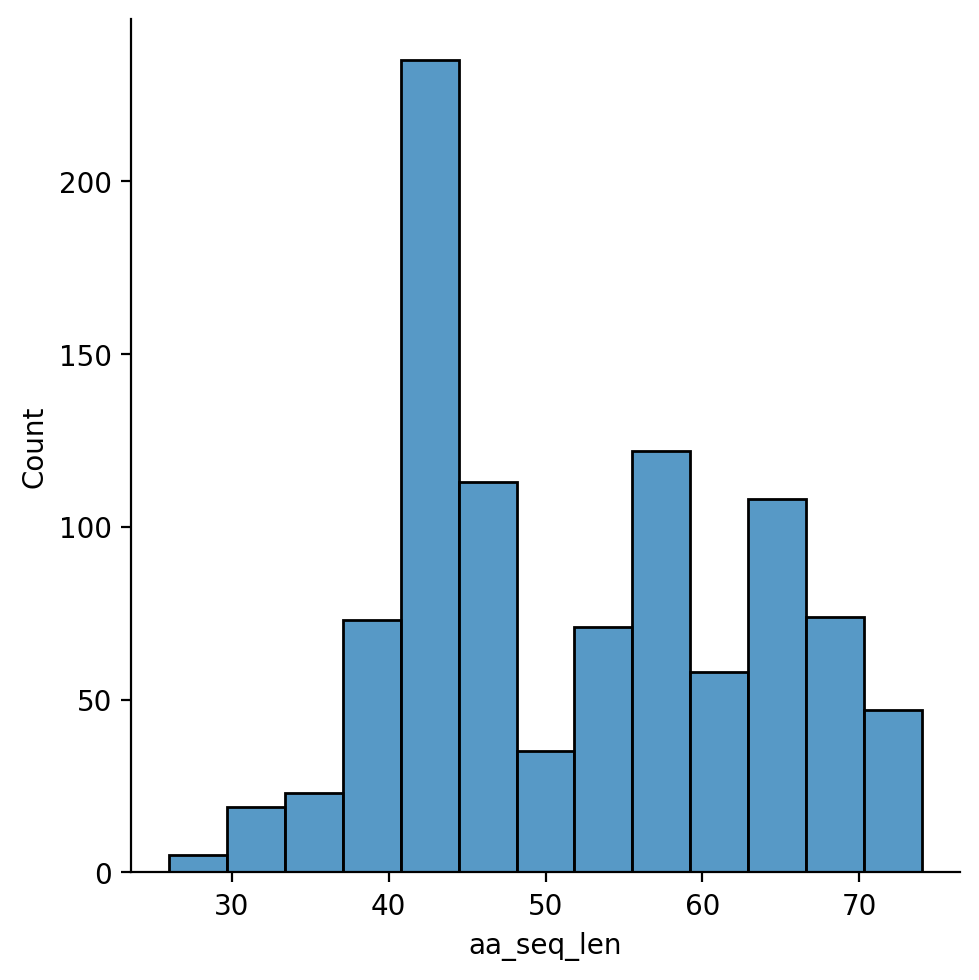

In [ ]:
df_wts["aa_seq_len"] = df_wts["aa_seq"].str.len()
sns.displot(x='aa_seq_len', data=df_wts)
plt.show()

**Random: Check one of the histograms for manual review (note: we can maybe just exclude all unimodal distributions also)**

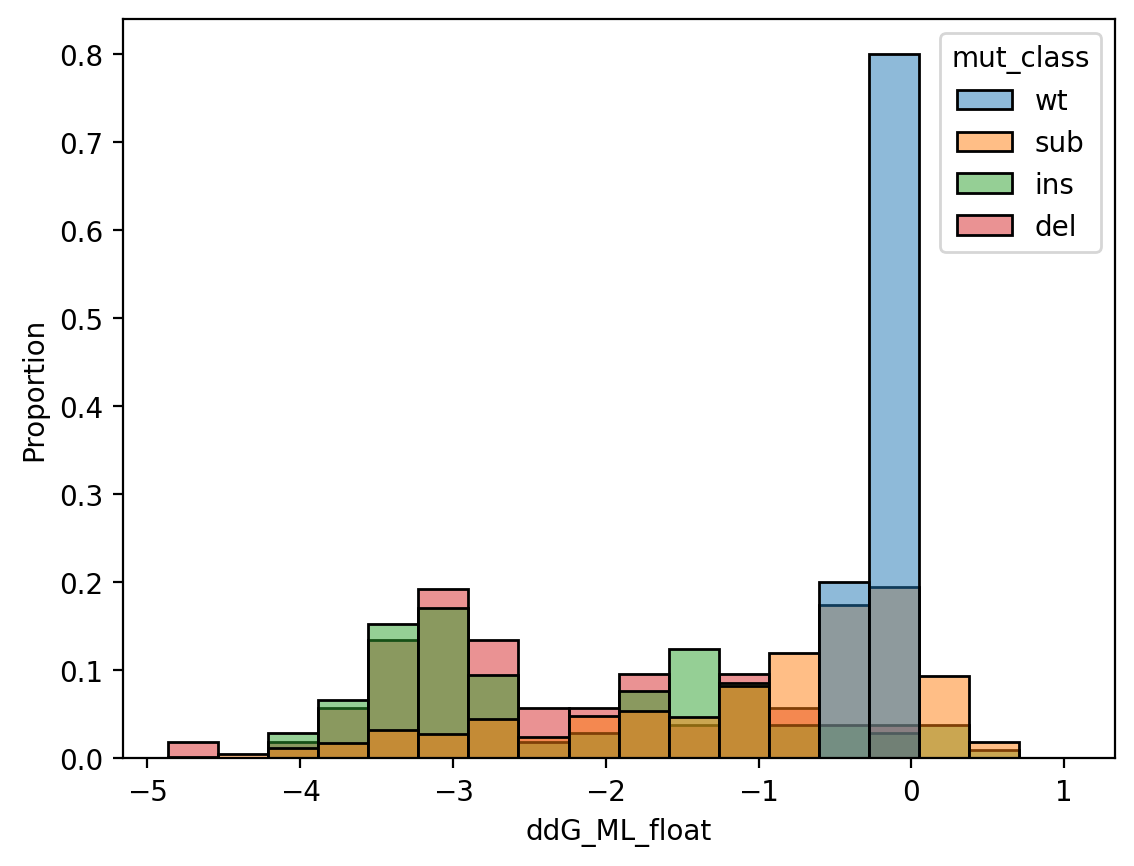

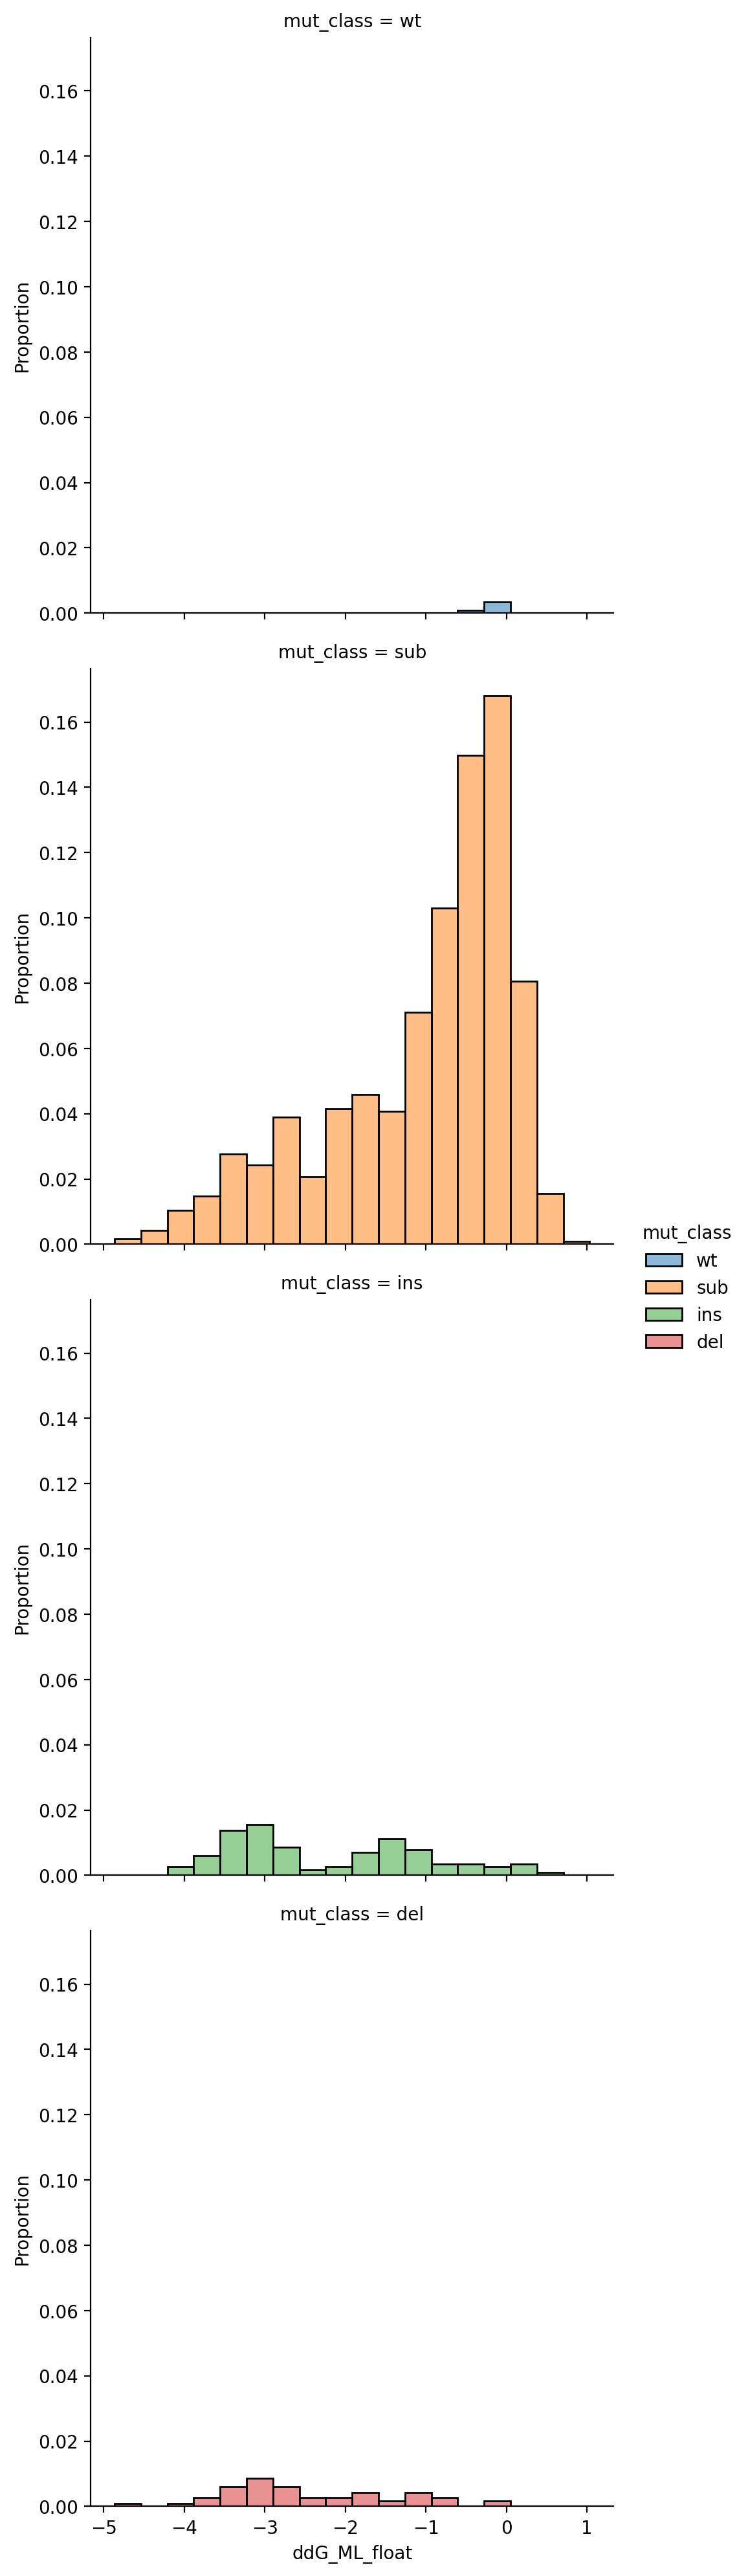

In [ ]:
# df_natural[(df_natural["WT_name"] == "2MXD.pdb") & (~df_natural["mut_type"].str.contains(":"))]["dG_ML"]
tmp = df_natural[(df_natural["WT_name"] == "2MXD.pdb") & (~df_natural["mut_type"].str.contains(":"))].copy()
tmp["mut_class"] = tmp["mut_type"].apply(lambda m: "ins" if "ins" in m else "del" if "del" in m else "wt" if m == "wt" else "sub")
sns.histplot(x="ddG_ML_float", data=tmp, hue='mut_class', stat='proportion', common_norm=False)
plt.show()

sns.displot(x="ddG_ML_float", data=tmp, hue='mut_class', stat='proportion', row='mut_class')

## Old: Looking at the full Dataset3 (named Dataset1 here)

In [ ]:
df_subset = pd.read_csv("Tsuboyama2023_Dataset1_20230416_1000.csv")
display(df_subset.head())
df_subset.columns

FileNotFoundError: [Errno 2] No such file or directory: 'Tsuboyama2023_Dataset1_20230416_1000.csv'

In [ ]:
df_subset["log10_K50_trypsin_ML_float"] = df_subset["log10_K50_trypsin_ML"].replace("-", "NaN").astype(float)

In [ ]:
sns.scatterplot(x="log10_K50_t", y="log10_K50_trypsin_ML_float", data=df_subset)